# Sensitivity Analysis and Duality — Interactive Teaching Notebook

**Course lecture:** *Sensitivity Analysis and Duality* (Dr. Islam Ali)

This notebook explains and implements **every concept in the lecture**, with visualizations, interactive demos you can use in class, and PDF reports you can export.

| # | Section | Lecture slides |
|---|---------|----------------|
| 0 | Setup, data files and the LP toolkit | – |
| 1 | What is sensitivity analysis? Graphical solution of the Tables & Chairs LP | 3 – 6 |
| 2 | Objective Function Coefficient (OFC) changes: slope, range of optimality | 7 – 12 |
| 3 | Right-Hand-Side (RHS) changes: shadow prices and their range of validity | 13 – 19 |
| 4 | Duality theory: building the dual, primal ↔ dual rules | 20 – 23 |
| 5 | Economic interpretation: the dual of a **max** problem (Dakota Furniture) | 24 – 38 |
| 6 | Economic interpretation: the dual of a **min** problem (Diet problem) | 39 – 48 |
| 7 | Properties of duality: dual of the dual, weak and strong duality, the status table | 49 – 56 |
| 8 | Economic interpretation of $y^*$: perturbing $b_i + t_i$ | 57 – 59 |
| 9 | Primal simplex vs. dual simplex (adding a new constraint) | 60 – 62 |
| 10 | PDF report export | – |
| 11 | Practice problems for students | – |

**How to use it**
* **Instructors:** run all cells once (*Run → Run All*), then scroll to any 🎛️ **Interactive demo** cell and drag the sliders during the lecture.
* **Students:** read the notes, run the cells, change the data in the `data/` folder (or copy `99_template.json`), and try the ✏️ **Your turn** cells.
* **Reports:** section 10 exports a full PDF report for any problem file.

> Interactive demos need `ipywidgets` (included in Jupyter/JupyterLab, VS Code and Google Colab). Without it, the static figures still work.

## 0. Setup

The next cell installs any missing packages (the first run only), imports the libraries and sets the plotting style.

**Folder layout** (keep the notebook next to these folders):
```
Sensitivity_Analysis_and_Duality.ipynb
data/      ← input LP files (.json, or .csv for simple models)
reports/   ← PDF reports are written here
```

In [1]:
import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f"Installing {pip_name or pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])

for _p, _pip in [("numpy", None), ("scipy", None), ("pandas", None), ("matplotlib", None),
                 ("reportlab", None), ("ipywidgets", None)]:
    _ensure(_p, _pip)

import io, json, math, os, glob, itertools, warnings, copy, datetime
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrowPatch, Rectangle
from matplotlib.lines import Line2D
from scipy.optimize import linprog
from IPython.display import display, Markdown, Math, HTML

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

%matplotlib inline
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.precision", 4)

# ---- paths -----------------------------------------------------------------
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
REPORT_DIR = BASE_DIR / "reports"
REPORT_DIR.mkdir(exist_ok=True)

# ---- report identity (edit these) -------------------------------------------
COURSE_TITLE = "Sensitivity Analysis and Duality"
INSTRUCTOR = "Dr. Islam Ali"
STUDENT_NAME = ""          # students: put your name here so it appears on your PDF reports

# ---- colour palette (colour-blind-checked categorical order) ----------------
PAL = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
    "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#8a8983", "grid": "#e4e3df",
    "surface": "#fcfcfb", "region": "#cfe2f7", "region2": "#cdeedd", "bad": "#f6d3d2",
}
SERIES = [PAL[k] for k in ["blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red"]]

plt.rcParams.update({
    "figure.facecolor": PAL["surface"], "axes.facecolor": PAL["surface"],
    "axes.edgecolor": PAL["muted"], "axes.labelcolor": PAL["ink"], "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.labelsize": 10, "axes.grid": True, "grid.color": PAL["grid"],
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": PAL["ink2"], "ytick.color": PAL["ink2"], "legend.frameon": False,
    "legend.fontsize": 9, "font.size": 10, "lines.linewidth": 2, "figure.dpi": 100,
    "savefig.dpi": 200, "savefig.bbox": "tight", "axes.prop_cycle": matplotlib.cycler(color=SERIES),
})
print("Widgets available:", HAS_WIDGETS)
print("Data folder:", DATA_DIR, "| files:", len(list(DATA_DIR.glob('*.json'))))

Widgets available: True
Data folder: c:\Users\islam\Documents\GitHub\IME312_OR1_FALL2026\Lecture04\data | files: 11


## 0.1 The LP toolkit

The cells below build a small toolkit that the rest of the notebook uses. Read it if you want to see how things work, or skip ahead.

| Part | What it does |
|------|--------------|
| `LP` data class + `load_lp()` | Reads a model from `data/*.json` (or a simple `.csv`) |
| `solve()` | Solves the LP with SciPy's HiGHS solver (status, $x^*$, $z^*$, dual values) |
| `simplex()` / `dual_simplex()` | Our own tableau simplex (two-phase) that records every iteration, so we can *see* the algorithm |
| `sensitivity()` | Shadow prices, reduced costs, and allowable ranges for the objective coefficients and RHS values |
| `dualize()` | Builds the dual of any LP (≤, ≥, = constraints; ≥0, ≤0, free variables) |

### Input file format (JSON)
```json
{
  "name": "Tables and Chairs",
  "sense": "max",                        // "max" or "min"
  "objective_name": "Profit ($)",
  "objective": [7, 5],                   // c_j
  "variables":   [{"name": "T", "description": "...", "sign": ">=0"}, ...],   // ">=0", "<=0" or "free"
  "constraints": [{"name": "Carpentry", "coefficients": [3, 4], "sense": "<=", "rhs": 2400}, ...],
  "scenarios":   {"ofc": [...], "rhs": [...], "new_constraints": [...]}      // optional what-if cases
}
```
A simple **CSV** format also works (open `data/01_tables_chairs.csv` in Excel to see it).

In [2]:
TOL = 1e-9

@dataclass
class LP:
    """A linear program:  max/min c·x  s.t.  A x (<=,>=,=) b,  x_j (>=0, <=0, free)."""
    name: str
    sense: str
    c: np.ndarray
    A: np.ndarray
    b: np.ndarray
    con_sense: list
    var_names: list
    con_names: list
    var_signs: list = None
    description: str = ""
    source: str = ""
    objective_name: str = "z"
    var_desc: list = None
    con_desc: list = None
    scenarios: dict = field(default_factory=dict)

    def __post_init__(self):
        self.c = np.asarray(self.c, float)
        self.A = np.atleast_2d(np.asarray(self.A, float))
        self.b = np.asarray(self.b, float)
        self.sense = self.sense.lower()
        self.con_sense = [s.replace("≤", "<=").replace("≥", ">=").replace("==", "=") for s in self.con_sense]
        self.var_signs = self.var_signs or [">=0"] * len(self.c)
        self.var_desc = self.var_desc or [""] * len(self.c)
        self.con_desc = self.con_desc or [""] * len(self.b)
        assert self.A.shape == (len(self.b), len(self.c)), "A must be m x n"

    @property
    def n(self): return len(self.c)
    @property
    def m(self): return len(self.b)

    def copy(self, **changes):
        new = copy.deepcopy(self)
        for k, v in changes.items():
            setattr(new, k, v)
        new.__post_init__()
        return new

    def with_c(self, j, value):
        j = self.var_index(j); c = self.c.copy(); c[j] = value
        return self.copy(c=c)

    def with_b(self, i, value):
        i = self.con_index(i); b = self.b.copy(); b[i] = value
        return self.copy(b=b)

    def add_constraint(self, name, coefs, sense, rhs):
        return self.copy(A=np.vstack([self.A, np.asarray(coefs, float)]), b=np.append(self.b, rhs),
                         con_sense=self.con_sense + [sense], con_names=self.con_names + [name],
                         con_desc=self.con_desc + ["added constraint"])

    def var_index(self, j): return self.var_names.index(j) if isinstance(j, str) else int(j)
    def con_index(self, i): return self.con_names.index(i) if isinstance(i, str) else int(i)

    # ----- pretty printing ----------------------------------------------------
    def _term_list(self, coefs, names):
        s = ""
        for k, (a, nm) in enumerate(zip(coefs, names)):
            if abs(a) < TOL: continue
            sign = " - " if a < 0 else (" + " if s else "")
            if a < 0 and not s: sign = "-"
            mag = abs(a)
            s += sign + ("" if abs(mag - 1) < TOL else f"{mag:g}\\,") + _tex_name(nm)
        return s or "0"

    def latex(self, title=None):
        rel = {"<=": "\\le", ">=": "\\ge", "=": "="}
        rows = [f"\\text{{{self.sense}}}\\;\\; z = {self._term_list(self.c, self.var_names)} \\\\"]
        for i in range(self.m):
            rows.append(f"& {self._term_list(self.A[i], self.var_names)} \\;{rel[self.con_sense[i]]}\\; {self.b[i]:g}"
                        f"\\quad \\text{{({self.con_names[i]})}} \\\\")
        signs = {}
        for nm, sg in zip(self.var_names, self.var_signs):
            signs.setdefault(sg, []).append(_tex_name(nm))
        txt = {">=0": "\\ge 0", "<=0": "\\le 0", "free": "\\text{ free}"}
        rows.append("& " + ",\\;\\; ".join(", ".join(v) + " " + txt[k] for k, v in signs.items()))
        body = "\\begin{aligned}" + rows[0].replace("z =", "&z =", 1) + "".join(rows[1:]) + "\\end{aligned}"
        return body

    def show(self, title=None):
        display(Markdown(f"**{title or self.name}**"))
        display(Math(self.latex()))

    def plain_terms(self, coefs):
        out = ""
        for a, nm in zip(coefs, self.var_names):
            if abs(a) < TOL: continue
            sgn = " - " if a < 0 else (" + " if out else "")
            if a < 0 and not out: sgn = "-"
            out += sgn + ("" if abs(abs(a) - 1) < TOL else f"{abs(a):g} ") + nm
        return out or "0"

    def text(self):
        """Plain-text formulation (used in PDF reports)."""
        terms = self.plain_terms
        lines = [f"{self.sense.upper()}  z = {terms(self.c)}", "subject to"]
        for i in range(self.m):
            lines.append(f"   {terms(self.A[i])}  {self.con_sense[i]}  {self.b[i]:g}     ({self.con_names[i]})")
        lines.append("   " + ", ".join(f"{nm} {sg if sg != 'free' else 'free'}" for nm, sg in zip(self.var_names, self.var_signs)))
        return "\n".join(lines)


def _tex_name(nm):
    """x1 -> x_{1}, y_Lumber -> y_{\\text{Lumber}}, IceCream -> \\text{IceCream}."""
    import re
    m = re.fullmatch(r"([a-zA-Z])_?(\d+)", nm)
    if m: return f"{m.group(1)}_{{{m.group(2)}}}"
    m = re.fullmatch(r"([a-zA-Z])_(.+)", nm)
    if m: return f"{m.group(1)}_{{\\text{{{m.group(2)}}}}}"
    return nm if len(nm) == 1 else f"\\text{{{nm}}}"


def load_lp(path):
    """Load an LP from a .json or .csv file (see the format above)."""
    path = Path(path)
    if not path.exists() and (DATA_DIR / path).exists():
        path = DATA_DIR / path
    if path.suffix.lower() == ".csv":
        return _load_lp_csv(path)
    d = json.loads(path.read_text())
    V, C = d["variables"], d["constraints"]
    return LP(name=d.get("name", path.stem), sense=d["sense"], c=d["objective"],
              A=[c_["coefficients"] for c_ in C], b=[c_["rhs"] for c_ in C],
              con_sense=[c_["sense"] for c_ in C], var_names=[v["name"] for v in V],
              con_names=[c_["name"] for c_ in C], var_signs=[v.get("sign", ">=0") for v in V],
              description=d.get("description", ""), source=d.get("source", ""),
              objective_name=d.get("objective_name", "z"), var_desc=[v.get("description", "") for v in V],
              con_desc=[c_.get("description", "") for c_ in C], scenarios=d.get("scenarios", {}))


def _load_lp_csv(path):
    df = pd.read_csv(path, dtype=str).fillna("")
    var_cols = [c for c in df.columns if c not in ("row", "type", "sense", "rhs")]
    obj = df[df["row"].str.lower() == "objective"].iloc[0]
    cons = df[df["type"].str.lower() == "constraint"]
    sign_rows = df[df["row"].str.lower() == "sign"]
    signs = [sign_rows.iloc[0][v] or ">=0" for v in var_cols] if len(sign_rows) else None
    return LP(name=path.stem, sense=obj["type"], c=[float(obj[v]) for v in var_cols],
              A=[[float(r[v] or 0) for v in var_cols] for _, r in cons.iterrows()],
              b=[float(r["rhs"]) for _, r in cons.iterrows()], con_sense=list(cons["sense"]),
              var_names=var_cols, con_names=list(cons["row"]), var_signs=signs)


def list_data_files():
    return sorted(p.name for p in DATA_DIR.glob("*.json"))

### Solving with SciPy (HiGHS)
`solve(lp)` returns a dictionary with the status, $x^*$, $z^*$, the slack of each constraint and the **dual values** (shadow prices).

Sign convention used everywhere in this notebook: the **shadow price** of constraint $i$ is
$$y_i = \frac{\partial z^*}{\partial b_i},$$
the change in the optimal objective per one-unit *increase* of the right-hand side (the same convention as Excel Solver).

In [3]:
def solve(lp):
    """Solve an LP with scipy.optimize.linprog (HiGHS). Returns a dict."""
    sig = -1.0 if lp.sense == "max" else 1.0            # linprog minimises
    A_ub, b_ub, A_eq, b_eq, rows_ub, rows_eq = [], [], [], [], [], []
    for i in range(lp.m):
        if lp.con_sense[i] == "<=":   A_ub.append(lp.A[i]);  b_ub.append(lp.b[i]);  rows_ub.append((i, 1))
        elif lp.con_sense[i] == ">=": A_ub.append(-lp.A[i]); b_ub.append(-lp.b[i]); rows_ub.append((i, -1))
        else:                          A_eq.append(lp.A[i]);  b_eq.append(lp.b[i]);  rows_eq.append(i)
    bounds = [(0, None) if s == ">=0" else (None, 0) if s == "<=0" else (None, None) for s in lp.var_signs]
    res = linprog(sig * lp.c, A_ub=np.array(A_ub) if A_ub else None, b_ub=b_ub or None,
                  A_eq=np.array(A_eq) if A_eq else None, b_eq=b_eq or None, bounds=bounds, method="highs")
    status = {0: "optimal", 2: "infeasible", 3: "unbounded"}.get(res.status, f"error ({res.message})")
    out = {"status": status, "x": None, "z": None, "y": None, "slack": None, "lhs": None, "message": res.message}
    if res.status == 0:
        y = np.zeros(lp.m)
        if A_ub:
            for (i, s), mg in zip(rows_ub, res.ineqlin.marginals): y[i] = sig * s * mg
        if A_eq:
            for i, mg in zip(rows_eq, res.eqlin.marginals): y[i] = sig * mg
        x = np.where(np.abs(res.x) < 1e-10, 0.0, res.x)
        lhs = lp.A @ x
        out.update(x=x, z=float(lp.c @ x), y=np.where(np.abs(y) < 1e-10, 0.0, y), lhs=lhs,
                   slack=np.where(np.array(lp.con_sense) == ">=", lhs - lp.b, lp.b - lhs))
    return out


def z_star(lp):
    """Optimal objective value (nan if not optimal) – handy for sweeps."""
    r = solve(lp)
    return r["z"] if r["status"] == "optimal" else np.nan

### Our own tableau simplex (two-phase) with a full iteration history
SciPy gives the answer; the tableau simplex below shows **how** the answer is reached. Every iteration is recorded (tableau, basis, entering column, leaving row, ratio test), which lets us draw the path of the algorithm and the tableaus (section 9).

Internally every problem is converted to **max** form with equality constraints:
* `<=` rows get a slack $s_i$; `>=` rows get a surplus $e_i$ and an artificial $a_i$; `=` rows get an artificial;
* rows with a negative RHS are multiplied by −1 first; a `<=0` variable is replaced by $x' = -x$ and a free variable by $x^+ - x^-$.

Tableau row 0 holds $z_j - c_j$ (the reduced costs): the tableau is **optimal** when all of them are ≥ 0 and **primal feasible** when all RHS values are ≥ 0.

In [4]:
class StdForm:
    """Equality ('standard') form used by the tableau simplex."""
    def __init__(self, lp):
        self.lp = lp
        self.sigma = 1.0 if lp.sense == "max" else -1.0          # internal problem is always max
        cols, cost, labels = [], [], []
        self.var_map = []                                       # (orig j, internal col, factor)
        for j in range(lp.n):
            sg = lp.var_signs[j]
            parts = [(1.0, "")] if sg == ">=0" else [(-1.0, "'")] if sg == "<=0" else [(1.0, "+"), (-1.0, "-")]
            for f, suf in parts:
                self.var_map.append((j, len(cols), f))
                cols.append(f * lp.A[:, j]); cost.append(self.sigma * f * lp.c[j]); labels.append(lp.var_names[j] + suf)
        self.n_struct = len(cols)
        self.flip = np.where(lp.b < 0, -1.0, 1.0)
        rel = []
        for i in range(lp.m):
            s = lp.con_sense[i]
            if self.flip[i] < 0: s = {"<=": ">=", ">=": "<=", "=": "="}[s]
            rel.append(s)
        self.rel = rel
        A = np.column_stack(cols) * self.flip[:, None] if cols else np.zeros((lp.m, 0))
        self.kind = ["x"] * self.n_struct
        self.row_slack_col = [None] * lp.m
        extra, art_rows = [], []
        for i in range(lp.m):
            if rel[i] == "<=":
                self.row_slack_col[i] = len(labels); e = np.zeros(lp.m); e[i] = 1
                extra.append(e); labels.append(f"s{i+1}"); self.kind.append("s"); cost.append(0.0)
            elif rel[i] == ">=":
                self.row_slack_col[i] = len(labels); e = np.zeros(lp.m); e[i] = -1
                extra.append(e); labels.append(f"e{i+1}"); self.kind.append("e"); cost.append(0.0)
        self.n_noart = len(labels)
        for i in range(lp.m):
            if rel[i] in (">=", "="):
                e = np.zeros(lp.m); e[i] = 1; extra.append(e); labels.append(f"a{i+1}")
                self.kind.append("a"); cost.append(0.0); art_rows.append(i)
        self.A = np.column_stack([A] + extra) if extra else A
        self.b = lp.b * self.flip
        self.c = np.array(cost)
        self.labels = labels
        self.art_rows = art_rows

    def orig_x(self, xint):
        x = np.zeros(self.lp.n)
        for j, k, f in self.var_map: x[j] += f * xint[k]
        return x


def _snapshot(T, basis, sf, phase, it, enter=None, leave=None, ratios=None, note="", method="primal"):
    m = T.shape[0] - 1
    xint = np.zeros(T.shape[1] - 1)
    for r, k in enumerate(basis): xint[k] = T[r + 1, -1]
    ncols = T.shape[1] - 1
    rc = T[0, :-1]
    active = [k for k in range(ncols) if sf.kind[k] != "a"] if phase == 2 else list(range(ncols))
    return dict(T=T.copy(), basis=list(basis), phase=phase, iter=it, enter=enter, leave=leave,
                ratios=None if ratios is None else ratios.copy(), note=note, method=method,
                labels=list(sf.labels[:ncols]), x=sf.orig_x(xint), xint=xint,
                z=(sf.sigma * T[0, -1]) if phase == 2 else -T[0, -1],
                primal_feasible=bool(np.all(T[1:, -1] >= -1e-9)),
                dual_feasible=bool(np.all(rc[active] >= -1e-9)))


def _pivot(T, r, k):
    T[r] = T[r] / T[r, k]
    for i in range(T.shape[0]):
        if i != r and abs(T[i, k]) > 0:
            T[i] -= T[i, k] * T[r]
    T[np.abs(T) < 1e-12] = 0.0


def _primal_iterations(T, basis, sf, phase, history, allowed, max_iter=200):
    """Run primal simplex pivots on tableau T (row 0 = z_j - c_j). Returns status."""
    it = 0
    while it < max_iter:
        rc = T[0, :-1]
        cand = [k for k in allowed if rc[k] < -1e-9]
        if not cand:
            return "optimal"
        use_bland = it > 50                                   # anti-cycling fallback
        k = min(cand) if use_bland else min(cand, key=lambda j: (rc[j], j))
        col = T[1:, k]
        ratios = np.full(len(col), np.inf)
        pos = col > 1e-9
        ratios[pos] = T[1:, -1][pos] / col[pos]
        if not np.any(pos):
            history.append(_snapshot(T, basis, sf, phase, len(history), enter=k, ratios=ratios,
                                     note=f"{sf.labels[k]} can increase forever → unbounded"))
            return "unbounded"
        best = np.min(ratios)
        rows = [r for r in range(len(col)) if pos[r] and abs(ratios[r] - best) < 1e-9]
        r = min(rows, key=lambda rr: basis[rr])
        history.append(_snapshot(T, basis, sf, phase, len(history), enter=k, leave=r, ratios=ratios,
                                 note=f"enter {sf.labels[k]}, leave {sf.labels[basis[r]]} (min ratio {best:.4g})"))
        _pivot(T, r + 1, k)
        basis[r] = k
        it += 1
    return "iteration limit"


def simplex(lp, verbose=False):
    """Two-phase tableau simplex. Returns dict(status, x, z, history, tableau, basis, sf)."""
    sf = StdForm(lp)
    m, N = sf.A.shape
    T = np.zeros((m + 1, N + 1))
    T[1:, :N] = sf.A; T[1:, -1] = sf.b
    basis = [None] * m
    for i in range(m):
        if sf.rel[i] == "<=": basis[i] = sf.row_slack_col[i]
    art_cols = [k for k in range(N) if sf.kind[k] == "a"]
    for k in art_cols:
        i = int(np.argmax(sf.A[:, k])); basis[i] = k
    history = []
    # ---------------- phase 1 ----------------
    if art_cols:
        T[0, :] = 0; T[0, art_cols] = 1.0                    # max -sum(a)  ->  row0 = +1 on artificials
        for i in range(m):
            if sf.kind[basis[i]] == "a": T[0] -= T[i + 1]
        st = _primal_iterations(T, basis, sf, 1, history, list(range(N)))
        history.append(_snapshot(T, basis, sf, 1, len(history), note="end of phase 1"))
        if T[0, -1] < -1e-7:
            return dict(status="infeasible", x=None, z=None, history=history, tableau=T, basis=basis, sf=sf)
        # drive zero-level artificials out of the basis
        for r in range(m):
            if sf.kind[basis[r]] == "a":
                nz = [k for k in range(N) if sf.kind[k] != "a" and abs(T[r + 1, k]) > 1e-9]
                if nz:
                    _pivot(T, r + 1, nz[0]); basis[r] = nz[0]
    # ---------------- phase 2 ----------------
    keep = [k for k in range(N) if sf.kind[k] != "a"]
    redundant = [r for r in range(m) if sf.kind[basis[r]] == "a"]
    rows = [0] + [r + 1 for r in range(m) if r not in redundant]
    T = T[np.ix_(rows, keep + [N])]
    basis = [keep.index(basis[r]) for r in range(m) if r not in redundant]
    sf.redundant_rows = redundant
    sf.labels = [sf.labels[k] for k in keep]
    sf.kind = [sf.kind[k] for k in keep]
    T[0, :] = 0; T[0, :-1] = -sf.c[keep]
    for r, k in enumerate(basis):
        if abs(T[0, k]) > 0: T[0] -= T[0, k] * T[r + 1]
    sf.c2, sf.A2, sf.b2, sf.keep_cols = sf.c[keep], sf.A[:, keep], sf.b, keep
    st = _primal_iterations(T, basis, sf, 2, history, list(range(len(keep))))
    history.append(_snapshot(T, basis, sf, 2, len(history), note="optimal tableau" if st == "optimal" else st))
    res = dict(status=st, x=None, z=None, history=history, tableau=T, basis=basis, sf=sf)
    if st == "optimal":
        snap = history[-1]
        res.update(x=snap["x"], z=snap["z"])
    if verbose:
        print(f"status={st}, iterations={len(history)-1}")
    return res


def dual_simplex(T, basis, sf, history=None, max_iter=100, method_note=""):
    """Dual simplex on a dual-feasible tableau (row0 >= 0). Keeps dual feasibility, restores primal feasibility."""
    T = T.copy(); basis = list(basis); history = [] if history is None else history
    for it in range(max_iter):
        rhs = T[1:, -1]
        if np.all(rhs >= -1e-9):
            history.append(_snapshot(T, basis, sf, 2, len(history), note="optimal (primal feasible again)", method="dual"))
            return dict(status="optimal", T=T, basis=basis, history=history, x=history[-1]["x"], z=history[-1]["z"])
        r = int(np.argmin(rhs))                               # leaving row: most negative RHS
        row = T[r + 1, :-1]
        neg = row < -1e-9
        if not np.any(neg):
            history.append(_snapshot(T, basis, sf, 2, len(history), leave=r, note="no negative entry in pivot row → primal infeasible", method="dual"))
            return dict(status="infeasible", T=T, basis=basis, history=history, x=None, z=None)
        ratios = np.full(len(row), np.inf)
        ratios[neg] = np.abs(T[0, :-1][neg] / row[neg])
        k = int(np.argmin(ratios))
        history.append(_snapshot(T, basis, sf, 2, len(history), enter=k, leave=r, ratios=ratios, method="dual",
                                 note=f"leave {sf.labels[basis[r]]} (RHS {rhs[r]:.4g} < 0), enter {sf.labels[k]} (min |ratio| {ratios[k]:.4g})"))
        _pivot(T, r + 1, k); basis[r] = k
    return dict(status="iteration limit", T=T, basis=basis, history=history, x=None, z=None)


def add_cut_and_reoptimize(lp, name, coefs, sense, rhs):
    """Take the optimal tableau of `lp`, append a new constraint, and re-optimize with the DUAL simplex."""
    base = simplex(lp)
    assert base["status"] == "optimal", "the original LP must be optimal"
    sf = base["sf"]; T = base["tableau"]; basis = base["basis"]
    a = np.zeros(T.shape[1] - 1)
    for j, k_orig, f in sf.var_map:
        a[sf.keep_cols.index(k_orig)] += f * coefs[j]
    s = 1.0 if sense == "<=" else -1.0                       # write as  s*(a x) + slack = s*rhs
    newrow = np.concatenate([s * a, [1.0], [s * rhs]])
    T2 = np.hstack([T[:, :-1], np.zeros((T.shape[0], 1)), T[:, -1:]])
    T2 = np.vstack([T2, newrow])
    for r, k in enumerate(basis):                            # express the new row in the current basis
        if abs(T2[-1, k]) > 1e-12: T2[-1] -= T2[-1, k] * T2[r + 1]
    sf2 = copy.copy(sf)
    sf2.labels = sf.labels + [f"s_{name}"]; sf2.kind = sf.kind + ["s"]
    basis2 = basis + [T2.shape[1] - 2]
    hist = [dict(h, method="primal") for h in base["history"]]
    start = len(hist)
    out = dual_simplex(T2, basis2, sf2, history=[])
    out["primal_history"] = hist
    out["lp_new"] = lp.add_constraint(name, coefs, sense, rhs)
    out["start_x"] = base["x"]; out["start_z"] = base["z"]
    return out

### Sensitivity analysis from the optimal basis
With the optimal basis $B$ (internal max form, $\hat c$ = internal costs):

* basic values $x_B = B^{-1}b$, simplex multipliers $\pi = \hat c_B B^{-1}$, reduced costs $\bar r_j = \pi A_j - \hat c_j \ge 0$;
* **shadow price** of constraint $i$ (original units): $y_i = \sigma\,\pi_i\,f_i$, where $\sigma = +1$ (max) or $-1$ (min) and $f_i=-1$ if row $i$ was multiplied by −1;
* **RHS range:** $b_i + \Delta$ keeps the same basis while $x_B + \Delta\, B^{-1}e_i f_i \ge 0$;
* **OFC range:** $c_j + \delta$ keeps the same basis while every reduced cost stays $\ge 0$: $\bar r_l + \delta\, q_l \ge 0$, with $q = \Delta\hat c_B B^{-1}A - \Delta\hat c$.

Within these ranges the optimal **solution** does not move (OFC) and the **shadow price** does not change (RHS), exactly as slides 12 and 19 say.

In [5]:
def _interval(base, direction):
    """Largest [lo, hi] for t with base + t*direction >= 0 (componentwise)."""
    lo, hi = -np.inf, np.inf
    for v, d in zip(base, direction):
        if d > 1e-12:  lo = max(lo, -v / d)
        elif d < -1e-12: hi = min(hi, -v / d)
    return lo, hi


def sensitivity(lp):
    """Sensitivity report (like Excel Solver). Returns dict with two DataFrames + extras."""
    sres = simplex(lp)
    if sres["status"] != "optimal":
        return dict(status=sres["status"], simplex=sres)
    sf, basis = sres["sf"], sres["basis"]
    A2, c2 = sf.A2, sf.c2
    live_rows = [i for i in range(lp.m) if i not in sf.redundant_rows]
    A2r, b2r = A2[live_rows], sf.b2[live_rows]
    B = A2r[:, basis]; Binv = np.linalg.inv(B)
    xB = Binv @ b2r
    pi = c2[basis] @ Binv
    rbar = pi @ A2r - c2
    nonbasic = [k for k in range(A2r.shape[1]) if k not in basis]
    x = sres["x"]
    y = np.zeros(lp.m)
    for r_, i in enumerate(live_rows): y[i] = sf.sigma * pi[r_] * sf.flip[i]
    y[np.abs(y) < 1e-10] = 0.0
    degenerate = bool(np.any(np.abs(xB) < 1e-9))
    # ---- variables: OFC ranging ------------------------------------------------
    vrows = []
    for j in range(lp.n):
        dc = np.zeros(A2r.shape[1])
        for jj, k_orig, f in sf.var_map:
            if jj == j: dc[sf.keep_cols.index(k_orig)] = sf.sigma * f
        q = dc[basis] @ Binv @ A2r - dc
        lo, hi = _interval(rbar[nonbasic], q[nonbasic])
        red = lp.c[j] - y @ lp.A[:, j]
        vrows.append(dict(Variable=lp.var_names[j], Value=x[j], ReducedCost=0.0 if abs(red) < 1e-10 else red,
                          ObjCoef=lp.c[j], AllowIncrease=hi, AllowDecrease=-lo,
                          RangeLow=lp.c[j] + lo, RangeHigh=lp.c[j] + hi,
                          Basic=any(sf.keep_cols.index(k) in basis for jj, k, f in sf.var_map if jj == j)))
    # ---- constraints: RHS ranging ---------------------------------------------
    crows = []
    lhs = lp.A @ x
    for i in range(lp.m):
        if i in live_rows:
            r_ = live_rows.index(i)
            lo, hi = _interval(xB, Binv[:, r_] * sf.flip[i])
        else:
            lo, hi = np.nan, np.nan
        slack = lp.b[i] - lhs[i] if lp.con_sense[i] == "<=" else lhs[i] - lp.b[i] if lp.con_sense[i] == ">=" else 0.0
        crows.append(dict(Constraint=lp.con_names[i], LHS=lhs[i], Sense=lp.con_sense[i], RHS=lp.b[i],
                          Slack=0.0 if abs(slack) < 1e-9 else slack, Binding=abs(slack) < 1e-7,
                          ShadowPrice=y[i], AllowIncrease=hi, AllowDecrease=-lo,
                          RangeLow=lp.b[i] + lo, RangeHigh=lp.b[i] + hi))
    return dict(status="optimal", x=x, z=sres["z"], y=y, var=pd.DataFrame(vrows), con=pd.DataFrame(crows),
                degenerate=degenerate, simplex=sres, Binv=Binv, basis_labels=[sf.labels[k] for k in basis])


def fmt_range(v):
    if np.isnan(v): return "–"
    return ("∞" if v > 0 else "-∞") if np.isinf(v) else f"{v:,.4g}"


def show_sensitivity(lp, sens=None):
    """Display the sensitivity report nicely (two styled tables)."""
    sens = sens or sensitivity(lp)
    if sens["status"] != "optimal":
        display(Markdown(f"**{lp.name}: {sens['status']}** – no sensitivity report.")); return sens
    display(Markdown(f"**{lp.name}** — optimal {lp.objective_name}: **{sens['z']:,.4g}**"
                     + ("  ⚠️ *degenerate solution: ranges are valid but other optimal bases exist*" if sens["degenerate"] else "")))
    v = sens["var"][["Variable", "Value", "ReducedCost", "ObjCoef", "AllowIncrease", "AllowDecrease", "RangeLow", "RangeHigh"]].copy()
    c = sens["con"][["Constraint", "LHS", "Sense", "RHS", "Slack", "ShadowPrice", "AllowIncrease", "AllowDecrease", "RangeLow", "RangeHigh"]].copy()
    for df in (v, c):
        for col in ["AllowIncrease", "AllowDecrease", "RangeLow", "RangeHigh"]:
            df[col] = df[col].map(fmt_range)
    display(Markdown("*Variable cells (objective-coefficient ranging)*"))
    display(v.style.format(precision=4, thousands=","))
    display(Markdown("*Constraints (right-hand-side ranging)*"))
    display(c.style.format(precision=4, thousands=",").apply(
        lambda r: ["background-color: #fdeee0" if r["Slack"] == 0 else "" for _ in r], axis=1))
    return sens

### Building the dual
The rules (often remembered as the **SOB** table: *Sensible – Odd – Bizarre*):

| Primal **max** | Dual **min** | | Primal **min** | Dual **max** |
|---|---|---|---|---|
| constraint $\le$ | $y_i \ge 0$ (sensible) | | constraint $\ge$ | $y_i \ge 0$ (sensible) |
| constraint $=$ | $y_i$ free (odd) | | constraint $=$ | $y_i$ free (odd) |
| constraint $\ge$ | $y_i \le 0$ (bizarre) | | constraint $\le$ | $y_i \le 0$ (bizarre) |
| variable $x_j \ge 0$ | dual constraint $\ge c_j$ | | variable $x_j \ge 0$ | dual constraint $\le c_j$ |
| variable $x_j$ free | dual constraint $= c_j$ | | variable $x_j$ free | dual constraint $= c_j$ |
| variable $x_j \le 0$ | dual constraint $\le c_j$ | | variable $x_j \le 0$ | dual constraint $\ge c_j$ |

Dual objective coefficients = primal RHS $b$; dual RHS = primal objective $c$; dual matrix = $A^T$.

In [6]:
def dualize(lp, prefix="y_"):
    """Return the dual LP of `lp` (uses the table above)."""
    mx = lp.sense == "max"
    dual_sign = {("<=", True): ">=0", ("=", True): "free", (">=", True): "<=0",
                 (">=", False): ">=0", ("=", False): "free", ("<=", False): "<=0"}
    dual_rel = {(">=0", True): ">=", ("free", True): "=", ("<=0", True): "<=",
                (">=0", False): "<=", ("free", False): "=", ("<=0", False): ">="}
    back = lp.name.startswith("Dual of ")                    # dual of a dual -> recover original names
    var_names = list(lp.con_names) if back else [prefix + nm for nm in lp.con_names]
    con_names = [nm[len(prefix):] if nm.startswith(prefix) else nm for nm in lp.var_names] if back else list(lp.var_names)
    return LP(name=f"Dual of {lp.name}" if not back else lp.name[8:],
              sense="min" if mx else "max", c=lp.b.copy(), A=lp.A.T.copy(), b=lp.c.copy(),
              con_sense=[dual_rel[(s, mx)] for s in lp.var_signs],
              var_names=var_names, con_names=con_names,
              var_signs=[dual_sign[(s, mx)] for s in lp.con_sense],
              objective_name=("Dual objective w" if not lp.name.startswith("Dual of ") else lp.objective_name),
              description=f"Dual problem of '{lp.name}'.", var_desc=[f"price of {nm}" for nm in lp.con_names],
              con_desc=[f"constraint for {nm}" for nm in lp.var_names])


def same_lp(p, q):
    """True when two LPs have identical data (used to check dual(dual(P)) == P)."""
    return (p.sense == q.sense and np.allclose(p.c, q.c) and np.allclose(p.A, q.A) and np.allclose(p.b, q.b)
            and list(p.con_sense) == list(q.con_sense) and list(p.var_signs) == list(q.var_signs))


def complementary_slackness(lp, sol=None, dsol=None):
    """Table of the complementary-slackness products (all should be 0 at optimality)."""
    sol = sol or solve(lp); d = dualize(lp); dsol = dsol or solve(d)
    rows = []
    for i in range(lp.m):
        rows.append(dict(Pair=f"{lp.con_names[i]} slack × y_{lp.con_names[i]}", Slack=sol["slack"][i],
                         DualValue=dsol["x"][i], Product=sol["slack"][i] * dsol["x"][i]))
    for j in range(lp.n):
        rows.append(dict(Pair=f"{lp.var_names[j]} × surplus of dual constraint {lp.var_names[j]}",
                         Slack=dsol["slack"][j], DualValue=sol["x"][j], Product=sol["x"][j] * dsol["slack"][j]))
    df = pd.DataFrame(rows)
    df.loc[df["Product"].abs() < 1e-9, "Product"] = 0.0
    return df

### Plotting helpers
Graphical LP pictures (feasible region, constraint lines, iso-objective lines, corner points), parametric curves, range charts and tableau drawings. All figures in the notebook **and** in the PDF reports are produced by these functions.

In [7]:
def _halfplanes(lp, box=None):
    """Constraints of a 2-variable LP as rows (a1, a2, b) meaning a1*x + a2*y <= b."""
    H = []
    for i in range(lp.m):
        a, b_, s = lp.A[i], lp.b[i], lp.con_sense[i]
        if s in ("<=", "="): H.append((a[0], a[1], b_))
        if s in (">=", "="): H.append((-a[0], -a[1], -b_))
    for j, sg in enumerate(lp.var_signs):
        e = np.eye(2)[j]
        if sg == ">=0": H.append((-e[0], -e[1], 0.0))
        if sg == "<=0": H.append((e[0], e[1], 0.0))
    if box is not None:
        (x0, x1), (y0, y1) = box
        H += [(1, 0, x1), (-1, 0, -x0), (0, 1, y1), (0, -1, -y0)]
    return np.array(H, float)


def _vertices(H, tol=1e-7):
    pts = []
    for (a1, a2, b1), (c1, c2, b2) in itertools.combinations(H, 2):
        det = a1 * c2 - a2 * c1
        if abs(det) < 1e-12: continue
        p = np.array([(b1 * c2 - a2 * b2) / det, (a1 * b2 - b1 * c1) / det])
        if np.all(H[:, :2] @ p <= H[:, 2] + tol * (1 + np.abs(H[:, 2]))):
            pts.append(p)
    if not pts: return np.zeros((0, 2))
    pts = np.unique(np.round(np.array(pts), 9), axis=0) + 0.0
    cen = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - cen[1], pts[:, 0] - cen[0])
    return pts[np.argsort(ang)]


def corner_points(lp):
    """All corner points (extreme points) of a 2-variable LP with their objective values."""
    V = _vertices(_halfplanes(lp))
    df = pd.DataFrame({lp.var_names[0]: V[:, 0], lp.var_names[1]: V[:, 1]}) if len(V) else pd.DataFrame(columns=lp.var_names)
    if len(V):
        df[lp.objective_name] = V @ lp.c
        best = df[lp.objective_name].max() if lp.sense == "max" else df[lp.objective_name].min()
        df["Optimal?"] = np.where(np.isclose(df[lp.objective_name], best), "✔", "")
    return df


def auto_limits(lp, extra_points=(), pad=0.15):
    """Sensible plotting window for a 2-variable LP."""
    pts = list(_vertices(_halfplanes(lp)))
    for i in range(lp.m):                                # axis intercepts of every constraint line
        a, b_ = lp.A[i], lp.b[i]
        if abs(a[0]) > TOL: pts.append(np.array([b_ / a[0], 0]))
        if abs(a[1]) > TOL: pts.append(np.array([0, b_ / a[1]]))
    pts += [np.asarray(p, float) for p in extra_points]
    P = np.array(pts) if pts else np.array([[0, 0], [1, 1]])
    P = P[np.all(np.isfinite(P), axis=1)]
    lo = np.minimum(P.min(axis=0), 0); hi = np.maximum(P.max(axis=0), 1e-9)
    # keep the window focused: at most ~2.2x the feasible region size
    V = _vertices(_halfplanes(lp))
    if len(V):
        vhi = V.max(axis=0); hi = np.minimum(hi, np.maximum(vhi * 2.2, vhi + 1))
    span = hi - lo
    span[span == 0] = 1
    return (lo[0] - pad * span[0] * (lo[0] < 0), hi[0] + pad * span[0]), (lo[1] - pad * span[1] * (lo[1] < 0), hi[1] + pad * span[1])


def plot_lp_2d(lp, ax=None, xlim=None, ylim=None, iso=True, n_iso=3, show_opt=True, label_lines=True,
               region_color=None, show_vertices=True, title=None, gradient=True, opt_label=True, alpha=0.55,
               line_colors=None, draw_lines=True, region_label="Feasible\nregion"):
    """Draw a 2-variable LP: constraint lines, feasible region, corner points, iso-objective lines, optimum."""
    assert lp.n == 2, "graphical method needs exactly 2 variables"
    if ax is None: fig, ax = plt.subplots(figsize=(7, 5.6))
    if xlim is None or ylim is None:
        xl, yl = auto_limits(lp); xlim = xlim or xl; ylim = ylim or yl
    box = (xlim, ylim)
    poly = _vertices(_halfplanes(lp, box))
    if len(poly) >= 3:
        ax.add_patch(Polygon(poly, closed=True, facecolor=region_color or PAL["region"], edgecolor=PAL["blue"],
                             lw=1.2, alpha=alpha, zorder=1))
        if region_label:
            cen = poly.mean(axis=0)
            ax.text(*cen, region_label, ha="center", va="center", color=PAL["ink2"], fontsize=9, zorder=2)
    xs = np.linspace(*xlim, 400)
    colors = line_colors or [SERIES[(k + 1) % len(SERIES)] for k in range(lp.m)]
    if draw_lines:
        for i in range(lp.m):
            a, b_ = lp.A[i], lp.b[i]; col = colors[i]
            lab = f"{lp.con_names[i]}: {lp.plain_terms(a)} {lp.con_sense[i]} {b_:g}"
            if abs(a[1]) > TOL:
                ys = (b_ - a[0] * xs) / a[1]
                ax.plot(xs, ys, color=col, lw=1.8, label=lab, zorder=3)
            else:
                ax.axvline(b_ / a[0], color=col, lw=1.8, label=lab, zorder=3)
    sol = solve(lp)
    if show_vertices:
        V = _vertices(_halfplanes(lp))
        ax.scatter(V[:, 0], V[:, 1], s=28, color=PAL["surface"], edgecolor=PAL["ink2"], zorder=5, lw=1.2) if len(V) else None
    if iso and sol["status"] == "optimal" and np.any(np.abs(lp.c) > TOL):
        zs = sol["z"] * np.linspace(0.35, 1.0, n_iso) if (abs(sol["z"]) > TOL and n_iso > 1) else [sol["z"]]
        for k, zv in enumerate(zs):
            last = k == len(zs) - 1
            if abs(lp.c[1]) > TOL:
                ax.plot(xs, (zv - lp.c[0] * xs) / lp.c[1], ls="--", lw=1.6 if last else 1.0,
                        color=PAL["red"] if last else PAL["muted"], zorder=4,
                        label=f"iso-{lp.objective_name.split(' ')[0].lower()}: z = {zv:,.4g}" if last else None)
            else:
                ax.axvline(zv / lp.c[0], ls="--", lw=1.6 if last else 1.0, color=PAL["red"] if last else PAL["muted"])
    if show_opt and sol["status"] == "optimal":
        x = sol["x"]
        ax.scatter([x[0]], [x[1]], s=110, color=PAL["red"], edgecolor="white", lw=2, zorder=7)
        if opt_label:
            ax.annotate(f"optimal ({x[0]:,.4g}, {x[1]:,.4g})\nz* = {sol['z']:,.4g}", x, xytext=(16, -42),
                        textcoords="offset points", fontsize=9, fontweight="bold", color=PAL["ink"], zorder=9,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PAL["grid"], alpha=0.9))
        if gradient:
            g = lp.c / (np.linalg.norm(lp.c) + 1e-12)
            L = 0.12 * min(xlim[1] - xlim[0], ylim[1] - ylim[0])
            if lp.sense == "min": g = -g
            ax.annotate("", xy=x + g * L, xytext=x, arrowprops=dict(arrowstyle="-|>", color=PAL["violet"], lw=2), zorder=8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel(lp.var_names[0]); ax.set_ylabel(lp.var_names[1])
    ax.axhline(0, color=PAL["ink2"], lw=0.8); ax.axvline(0, color=PAL["ink2"], lw=0.8)
    ax.set_title(title or lp.name)
    ax.legend(loc="upper right", fontsize=8)
    return ax


# ------------------------------------------------------------------ parametric (re-solve) analysis
def parametric_ofc(lp, var, values):
    j = lp.var_index(var); rows = []
    for v in values:
        r = solve(lp.with_c(j, v))
        rows.append({"param": v, "z": r["z"] if r["status"] == "optimal" else np.nan,
                     **{nm: (r["x"][k] if r["x"] is not None else np.nan) for k, nm in enumerate(lp.var_names)}})
    return pd.DataFrame(rows)


def parametric_rhs(lp, con, values):
    i = lp.con_index(con); rows = []
    for v in values:
        r = solve(lp.with_b(i, v))
        ok = r["status"] == "optimal"
        rows.append({"param": v, "z": r["z"] if ok else np.nan, "shadow": r["y"][i] if ok else np.nan,
                     **{nm: (r["x"][k] if ok else np.nan) for k, nm in enumerate(lp.var_names)}})
    return pd.DataFrame(rows)


def _sweep_window(center, lo, hi, width=None):
    """Window of parameter values around `center` that shows the allowable range plus some margin."""
    fin = [v for v in (lo, hi) if np.isfinite(v)]
    w = width or max([abs(center)] + [abs(v - center) for v in fin] + [1.0])
    a = lo - 0.6 * (hi - lo if np.isfinite(hi - lo) else w) if np.isfinite(lo) else center - 1.5 * w
    b = hi + 0.6 * (hi - lo if np.isfinite(hi - lo) else w) if np.isfinite(hi) else center + 1.5 * w
    return a, b


def plot_parametric_ofc(lp, var, axes=None, sens=None, n=161):
    """z*(c_j) and x*(c_j) as the objective coefficient of `var` changes; allowable range shaded."""
    sens = sens or sensitivity(lp); j = lp.var_index(var)
    row = sens["var"].iloc[j]; c0 = lp.c[j]
    a, b = _sweep_window(c0, row.RangeLow, row.RangeHigh)
    df = parametric_ofc(lp, j, np.linspace(a, b, n))
    if axes is None: fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    lo, hi = max(row.RangeLow, a), min(row.RangeHigh, b)
    for ax in axes: ax.axvspan(lo, hi, color=PAL["region2"], alpha=0.6, lw=0, label="range of optimality")
    axes[0].plot(df.param, df.z, color=PAL["blue"], label="optimal objective z*")
    axes[0].scatter([c0], [sens["z"]], color=PAL["red"], zorder=5, s=50, label=f"current c = {c0:g}")
    axes[0].set_xlabel(f"objective coefficient of {lp.var_names[j]}"); axes[0].set_ylabel("z*")
    axes[0].set_title(f"z* vs c({lp.var_names[j]}): range [{fmt_range(row.RangeLow)}, {fmt_range(row.RangeHigh)}]")
    for k, nm in enumerate(lp.var_names):
        axes[1].plot(df.param, df[nm], color=SERIES[k % 8], label=f"{nm}*", drawstyle="steps-mid")
    axes[1].axvline(c0, color=PAL["red"], lw=1, ls=":")
    axes[1].set_xlabel(f"objective coefficient of {lp.var_names[j]}"); axes[1].set_ylabel("optimal value")
    axes[1].set_title("Optimal solution x* is constant inside the range")
    for ax in axes: ax.legend(loc="best", fontsize=8)
    return axes, df


def plot_parametric_rhs(lp, con, axes=None, sens=None, n=161):
    """z*(b_i) (piecewise linear) and the shadow price y_i(b_i) (step function); validity range shaded."""
    sens = sens or sensitivity(lp); i = lp.con_index(con)
    row = sens["con"].iloc[i]; b0 = lp.b[i]
    a, b = _sweep_window(b0, row.RangeLow, row.RangeHigh)
    df = parametric_rhs(lp, i, np.linspace(a, b, n))
    if axes is None: fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    lo, hi = max(row.RangeLow, a), min(row.RangeHigh, b)
    for ax in axes: ax.axvspan(lo, hi, color=PAL["region2"], alpha=0.6, lw=0, label="range of validity")
    axes[0].plot(df.param, df.z, color=PAL["blue"], label="z*(b)")
    axes[0].scatter([b0], [sens["z"]], color=PAL["red"], zorder=5, s=50, label=f"current b = {b0:g}")
    xs = np.array([lo, hi]); axes[0].plot(xs, sens["z"] + row.ShadowPrice * (xs - b0), ls="--", color=PAL["orange"],
                                         lw=1.4, label=f"slope = shadow price {row.ShadowPrice:,.4g}")
    axes[0].set_xlabel(f"RHS of {lp.con_names[i]}"); axes[0].set_ylabel("z*"); axes[0].set_title(f"Optimal value vs RHS of {lp.con_names[i]}")
    axes[1].step(df.param, df.shadow, where="mid", color=PAL["violet"], label="shadow price")
    axes[1].scatter([b0], [row.ShadowPrice], color=PAL["red"], zorder=5, s=50)
    axes[1].set_xlabel(f"RHS of {lp.con_names[i]}"); axes[1].set_ylabel("shadow price y")
    axes[1].set_title(f"Shadow price is constant on [{fmt_range(row.RangeLow)}, {fmt_range(row.RangeHigh)}]")
    for ax in axes: ax.legend(fontsize=8, loc="best")
    return axes, df


def plot_ofc_ranges(lp, sens=None, ax=None):
    """Horizontal range bars: allowable interval for every objective coefficient."""
    sens = sens or sensitivity(lp); df = sens["var"]
    if ax is None: fig, ax = plt.subplots(figsize=(7, 0.55 * lp.n + 1.4))
    _range_bars(ax, df["Variable"], df["ObjCoef"], df["RangeLow"], df["RangeHigh"], PAL["blue"])
    ax.set_title("Range of optimality of each objective coefficient"); ax.set_xlabel("objective coefficient c_j")
    return ax


def plot_rhs_ranges(lp, sens=None, ax=None):
    sens = sens or sensitivity(lp); df = sens["con"]
    if ax is None: fig, ax = plt.subplots(figsize=(7, 0.55 * lp.m + 1.4))
    _range_bars(ax, df["Constraint"], df["RHS"], df["RangeLow"], df["RangeHigh"], PAL["aqua"], normalise=True)
    ax.set_title("RHS range of validity (shown relative to the current RHS)"); ax.set_xlabel("RHS as % of current value")
    return ax


def _range_bars(ax, names, cur, lo, hi, color, normalise=False):
    names, cur, lo, hi = list(names), np.array(cur, float), np.array(lo, float), np.array(hi, float)
    if normalise:
        scale = np.where(np.abs(cur) > TOL, np.abs(cur), 1.0)
        lo_, hi_, cur_ = 100 + 100 * (lo - cur) / scale, 100 + 100 * (hi - cur) / scale, np.full(len(cur), 100.0)
    else:
        lo_, hi_, cur_ = lo, hi, cur
    fin = np.concatenate([lo_[np.isfinite(lo_)], hi_[np.isfinite(hi_)], cur_])
    span = (fin.max() - fin.min()) or 1
    L, R = fin.min() - 0.35 * span, fin.max() + 0.35 * span
    for k, nm in enumerate(names):
        a = lo_[k] if np.isfinite(lo_[k]) else L
        b = hi_[k] if np.isfinite(hi_[k]) else R
        ax.barh(k, b - a, left=a, height=0.45, color=color, alpha=0.35, edgecolor=color)
        if not np.isfinite(lo_[k]): ax.annotate("", xy=(L, k), xytext=(L + 0.08 * span, k), arrowprops=dict(arrowstyle="-|>", color=color))
        if not np.isfinite(hi_[k]): ax.annotate("", xy=(R, k), xytext=(R - 0.08 * span, k), arrowprops=dict(arrowstyle="-|>", color=color))
        ax.plot([cur_[k]], [k], "o", color=PAL["red"], ms=7, zorder=4)
        txt = f"[{fmt_range(lo[k])}, {fmt_range(hi[k])}]  now {cur[k]:,.4g}"
        ax.text(cur_[k], k + 0.33, txt, ha="center", fontsize=8, color=PAL["ink2"])
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names); ax.set_xlim(L, R); ax.invert_yaxis()
    ax.set_ylim(len(names) - 0.4, -0.7)
    ax.grid(axis="y", visible=False)


def plot_shadow_prices(lp, sens=None, ax=None):
    sens = sens or sensitivity(lp); df = sens["con"]
    if ax is None: fig, ax = plt.subplots(figsize=(7, 0.5 * lp.m + 1.4))
    cols = [PAL["orange"] if b else PAL["muted"] for b in df["Binding"]]
    ax.barh(df["Constraint"], df["ShadowPrice"], color=cols, height=0.5)
    for k, v in enumerate(df["ShadowPrice"]):
        ax.text(v, k, f"  {v:,.4g}", va="center", ha="left" if v >= 0 else "right", fontsize=9, color=PAL["ink"])
    ax.axvline(0, color=PAL["ink2"], lw=0.8); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.set_title("Shadow prices (orange = binding constraint)"); ax.set_xlabel("Δz* per +1 unit of RHS")
    return ax


def plot_resource_usage(lp, sol=None, ax=None):
    sol = sol or solve(lp)
    if ax is None: fig, ax = plt.subplots(figsize=(7, 0.5 * lp.m + 1.4))
    y = np.arange(lp.m)
    ax.barh(y - 0.18, lp.b, height=0.34, color=PAL["grid"], edgecolor=PAL["muted"], label="RHS (available / required)")
    ax.barh(y + 0.18, sol["lhs"], height=0.34, color=PAL["blue"], label="LHS at optimum (used / supplied)")
    for k in range(lp.m):
        tag = "binding" if abs(sol["slack"][k]) < 1e-7 else f"slack {sol['slack'][k]:,.4g}"
        ax.text(max(lp.b[k], sol["lhs"][k]), k, f"  {lp.con_sense[k]} · {tag}", va="center", fontsize=8, color=PAL["ink2"])
    ax.set_yticks(y); ax.set_yticklabels(lp.con_names); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.set_title("Constraint usage at the optimum"); ax.legend(fontsize=8, loc="lower right")
    xmax = max(np.max(lp.b), np.max(sol["lhs"])); ax.set_xlim(min(0, np.min(sol["lhs"]), np.min(lp.b)) * 1.1, xmax * 1.45)
    return ax


def plot_solution_bars(lp, sol=None, ax=None):
    sol = sol or solve(lp)
    if ax is None: fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(lp.var_names, sol["x"], color=SERIES[:lp.n] if lp.n <= 8 else PAL["blue"], width=0.55)
    for k, v in enumerate(sol["x"]): ax.text(k, v, f"{v:,.4g}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Optimal decision  (z* = {sol['z']:,.4g})"); ax.grid(axis="x", visible=False)
    return ax


# ------------------------------------------------------------------ tableau drawing
def draw_tableau(snap, ax=None, title=None, basis_labels=True):
    """Draw a simplex tableau; the entering column and leaving row are highlighted (like slide 62)."""
    T = snap["T"]; labels = snap["labels"]; basis = snap["basis"]
    m1, N1 = T.shape
    if ax is None: fig, ax = plt.subplots(figsize=(min(1.0 * N1 + 1.6, 16), 0.5 * m1 + 1.2))
    ax.set_xlim(-1.6, N1); ax.set_ylim(m1 + 0.2, -1.1); ax.axis("off")
    heads = labels + ["RHS"]
    for k, h in enumerate(heads):
        ax.text(k + 0.5, -0.5, h, ha="center", va="center", fontweight="bold", fontsize=9)
    rowlab = ["z" if snap["phase"] == 2 else "w"] + [labels[k] for k in basis]
    enter, leave = snap.get("enter"), snap.get("leave")
    for r in range(m1):
        ax.text(-0.8, r + 0.5, rowlab[r], ha="center", va="center", fontweight="bold", fontsize=9, color=PAL["ink2"])
        for k in range(N1):
            v = T[r, k]
            fc = "white"
            if r == 0: fc = "#f1f0ec"
            if k == N1 - 1: fc = "#eef4fb"
            if r == 0 and k < N1 - 1 and v < -1e-9: fc = "#fbe3e3"          # not yet optimal
            if r > 0 and k == N1 - 1 and v < -1e-9: fc = "#fbe3e3"          # not yet primal feasible
            if enter is not None and k == enter: fc = "#fde2cf"
            if leave is not None and r == leave + 1: fc = "#d3ecf9" if fc == "white" or fc == "#eef4fb" else fc
            if enter is not None and leave is not None and k == enter and r == leave + 1: fc = "#f8b98f"
            ax.add_patch(Rectangle((k, r), 1, 1, facecolor=fc, edgecolor=PAL["grid"], lw=1))
            txt = f"{v:.3g}" if abs(v - round(v)) > 1e-9 else f"{int(round(v))}"
            ax.text(k + 0.5, r + 0.5, txt, ha="center", va="center", fontsize=8.5)
    ax.plot([N1 - 1, N1 - 1], [-0.1, m1], color=PAL["ink2"], lw=1.2)
    ax.plot([-1.5, N1], [1, 1], color=PAL["ink2"], lw=1.2)
    ttl = title or f"{'Dual' if snap.get('method') == 'dual' else 'Primal'} simplex – phase {snap['phase']}, tableau {snap['iter']}"
    ax.set_title(ttl + ("\n" + snap["note"] if snap.get("note") else ""), fontsize=10)
    return ax


def iteration_table(history):
    rows = []
    for h in history:
        rows.append(dict(Tableau=h["iter"], Method=h.get("method", "primal"), Phase=h["phase"],
                         Entering=h["labels"][h["enter"]] if h["enter"] is not None else "",
                         Leaving=h["labels"][h["basis"][h["leave"]]] if h["leave"] is not None else "",
                         Objective=h["z"], PrimalFeasible=h["primal_feasible"], DualFeasible=h["dual_feasible"],
                         Point="(" + ", ".join(f"{v:.4g}" for v in h["x"]) + ")"))
    return pd.DataFrame(rows)

---
## 1. What is sensitivity analysis? *(slides 3 – 6)*

The data in an LP model (profits, costs, resource limits) are almost never known exactly. **Sensitivity analysis** asks how *sensitive* the optimal solution is to changes in these data values. In this lecture we look at changes in:

1. an **objective function coefficient (OFC)** $c_j$, and
2. a **right-hand side (RHS)** value $b_i$ of a constraint.

For a 2-variable model we can *see* both effects on the graph.

### The running example: producing tables and chairs (slide 6)
$T$ = tables, $C$ = chairs, profit $7 per table and $5 per chair.

In [8]:
tc = load_lp("01_tables_chairs.json")
tc.show()
tc_sol = solve(tc)
print(f"Status: {tc_sol['status']}   T* = {tc_sol['x'][0]:g}, C* = {tc_sol['x'][1]:g},   profit z* = ${tc_sol['z']:,.0f}")

**Tables and Chairs**

<IPython.core.display.Math object>

Status: optimal   T* = 320, C* = 360,   profit z* = $4,040


### Graphical solution
The shaded polygon is the **feasible region**. The dashed lines are **iso-profit lines** $7T + 5C = k$; pushing them in the direction of the purple gradient arrow, the last corner they touch is optimal. The table lists every **corner point** with its profit (the corner-point method).

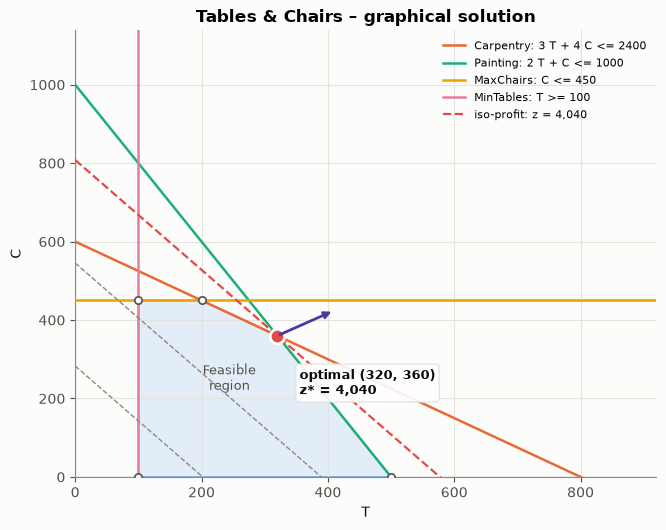

T,C,Profit ($),Optimal?
100.00,0.00,700.00,
500.00,0.00,3500.00,
320.00,360.00,4040.00,✔
200.00,450.00,3650.00,
100.00,450.00,2950.00,


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5.8))
plot_lp_2d(tc, ax=ax, n_iso=3, title="Tables & Chairs – graphical solution")
plt.show()
display(corner_points(tc).style.format(precision=2).hide(axis="index"))

---
## 2. Objective Function Coefficient (OFC) changes *(slides 7 – 12)*

**What if the profit contribution of a table changes from \$7 to \$8?** Profit clearly goes up, but would we make more tables and fewer chairs? In other words, *does the optimal solution change?*

**Characteristics of OFC changes (slide 9)**
* There is **no effect on the feasible region**.
* The **slope of the iso-profit line** changes: slope $= -c_T / c_C$.
* If the slope changes enough, a **different corner point** becomes optimal.

The figure reproduces slides 10 – 11: $c_T = 8$ keeps the same corner, but $c_T = 11$ and $c_T = 3$ each move the optimum to a new corner.

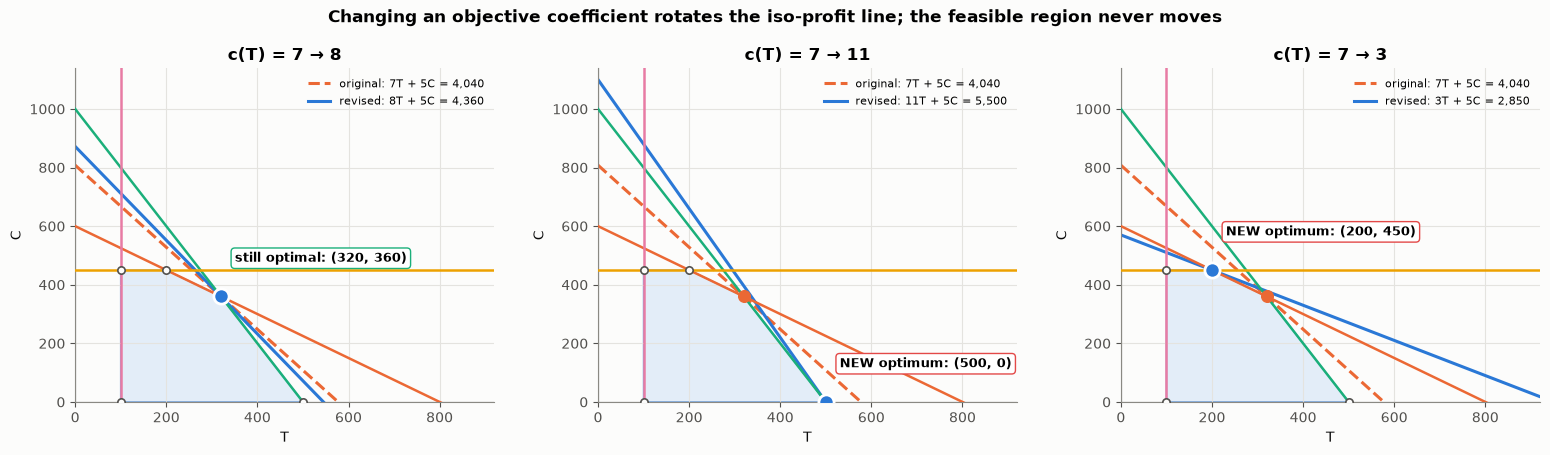

In [10]:
def compare_ofc(lp, var, new_values, figsize=None):
    """Small multiples: the original iso-objective line vs the revised one for several new OFC values."""
    j = lp.var_index(var); base = solve(lp)
    fig, axes = plt.subplots(1, len(new_values), figsize=figsize or (5.2 * len(new_values), 4.6))
    axes = np.atleast_1d(axes)
    for ax, v in zip(axes, new_values):
        new = lp.with_c(j, v); r = solve(new)
        plot_lp_2d(new, ax=ax, iso=False, show_opt=False, label_lines=False, show_vertices=True,
                   title=f"c({lp.var_names[j]}) = {lp.c[j]:g} → {v:g}", gradient=False, region_label=None)
        xl = np.array(ax.get_xlim())
        for L, z, col, lab in [(lp, base["z"], PAL["orange"], "original"), (new, r["z"], PAL["blue"], "revised")]:
            ax.plot(xl, (z - L.c[0] * xl) / L.c[1], color=col, lw=2.2, ls="--" if lab == "original" else "-",
                    label=f"{lab}: {L.c[0]:g}{lp.var_names[0]} + {L.c[1]:g}{lp.var_names[1]} = {z:,.0f}")
        same = np.allclose(r["x"], base["x"])
        ax.scatter(*base["x"], s=70, color=PAL["orange"], zorder=6)
        ax.scatter(*r["x"], s=120, color=PAL["blue"], edgecolor="white", lw=2, zorder=7)
        ax.annotate(("still optimal: " if same else "NEW optimum: ") + f"({r['x'][0]:g}, {r['x'][1]:g})",
                    r["x"], xytext=(10, 25), textcoords="offset points", fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round", fc="white", ec=PAL["aqua"] if same else PAL["red"]))
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[-2:], labels[-2:], loc="upper right", fontsize=8)
    fig.suptitle("Changing an objective coefficient rotates the iso-profit line; the feasible region never moves", fontweight="bold")
    fig.tight_layout()
    return fig

compare_ofc(tc, "T", [8, 11, 3]); plt.show()

### The range of optimality (slide 12)
There is a **range** for each OFC in which the current corner stays optimal.

**Graphical reasoning.** At the optimum $(320, 360)$ the binding constraints are carpentry ($3T + 4C \le 2400$, slope $-3/4$) and painting ($2T + C \le 1000$, slope $-2$). The corner stays optimal while the iso-profit slope $-c_T/c_C$ stays between them:
$$ -2 \;\le\; -\frac{c_T}{5} \;\le\; -\frac{3}{4} \quad\Longrightarrow\quad 3.75 \le c_T \le 10, \qquad\quad -2 \le -\frac{7}{c_C} \le -\frac34 \;\Longrightarrow\; 3.5 \le c_C \le 9.33 $$

Inside the range: the optimal solution does **not** change and the new profit is simply $z_{new} = c_{new}\cdot x^*$. Outside it, a new corner becomes optimal. The code below computes the same numbers two ways: with the slope rule and from the optimal simplex basis.

In [11]:
def ofc_range_by_slopes(lp):
    """2-variable LPs: range for each OFC from the slopes of the two binding constraints."""
    sol = solve(lp); x = sol["x"]
    binding = [i for i in range(lp.m) if abs(sol["slack"][i]) < 1e-7]
    rows = []
    # binding lines, including sign constraints x_j = 0 when active
    lines = [(lp.A[i], lp.con_names[i]) for i in binding] + [(np.eye(2)[j], f"{lp.var_names[j]} = 0") for j in range(2) if abs(x[j]) < 1e-9]
    if len(lines) != 2:
        print("Needs exactly two binding lines (non-degenerate vertex)."); return None
    (a, na), (b_, nb) = lines
    for j in range(2):
        k = 1 - j
        # ratio c_j / c_k must lie between a_j/a_k and b_j/b_k  (when c_k fixed)
        bounds = sorted([a[j] / a[k] * lp.c[k] if abs(a[k]) > TOL else np.inf * np.sign(a[j] or 1),
                         b_[j] / b_[k] * lp.c[k] if abs(b_[k]) > TOL else np.inf * np.sign(b_[j] or 1)])
        rows.append(dict(Variable=lp.var_names[j], Current=lp.c[j], Low=bounds[0], High=bounds[1],
                         Rule=f"between slopes of '{na}' and '{nb}'"))
    return pd.DataFrame(rows)

display(Markdown("**Slope rule (graphical):**"))
display(ofc_range_by_slopes(tc))
display(Markdown("**From the optimal simplex basis (works for any number of variables):**"))
tc_sens = show_sensitivity(tc)

**Slope rule (graphical):**

,Variable,Current,Low,High,Rule
0,T,7.0,3.75,10.0000,between slopes of 'Carpentry' and 'Painting'
1,C,5.0,3.50,9.3333,between slopes of 'Carpentry' and 'Painting'


**From the optimal simplex basis (works for any number of variables):**

**Tables and Chairs** — optimal Profit ($): **4,040**

*Variable cells (objective-coefficient ranging)*

,Variable,Value,ReducedCost,ObjCoef,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,T,320.0000,0.0000,7.0000,3,3.25,3.75,10
1,C,360.0000,0.0000,5.0000,4.333,1.5,3.5,9.333


*Constraints (right-hand-side ranging)*

,Constraint,LHS,Sense,RHS,Slack,ShadowPrice,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,Carpentry,"2,400.0000",<=,"2,400.0000",0.0000,0.6000,225,900,"1,500","2,625"
1,Painting,"1,000.0000",<=,"1,000.0000",0.0000,2.6000,600,150,850,"1,600"
2,MaxChairs,360.0000,<=,450.0000,90.0000,0.0000,∞,90,360,∞
3,MinTables,320.0000,>=,100.0000,220.0000,0.0000,220,∞,-∞,320


**Checking a change inside the range (slide 10):** $c_T = 8$ is inside $[3.75, 10]$, so $(T, C) = (320, 360)$ is still optimal and the new profit is $8(320) + 5(360) = \$4{,}360$.

In [12]:
for v in [8, 11, 3]:
    inside = tc_sens["var"].loc[0, "RangeLow"] <= v <= tc_sens["var"].loc[0, "RangeHigh"]
    r = solve(tc.with_c("T", v))
    print(f"c_T = {v:>2}: inside range? {str(inside):5s} -> optimum (T, C) = ({r['x'][0]:g}, {r['x'][1]:g}), profit = ${r['z']:,.0f}")

c_T =  8: inside range? True  -> optimum (T, C) = (320, 360), profit = $4,360
c_T = 11: inside range? False -> optimum (T, C) = (500, 0), profit = $5,500
c_T =  3: inside range? False -> optimum (T, C) = (200, 450), profit = $2,850


### Parametric view: sweeping one coefficient
Re-solving the LP for many values of $c_T$ shows the whole story: **inside the green range $x^*$ is flat** and $z^*$ grows linearly with slope $T^*$; at each end of the range a new corner takes over and the slope of $z^*$ changes.

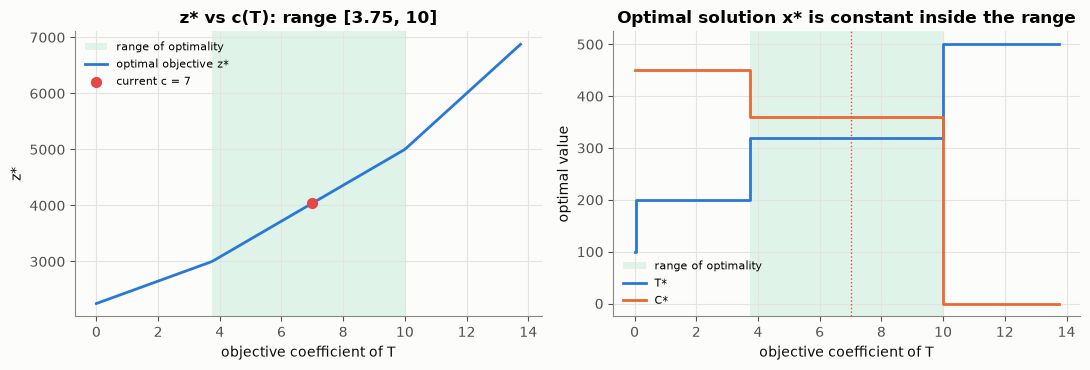

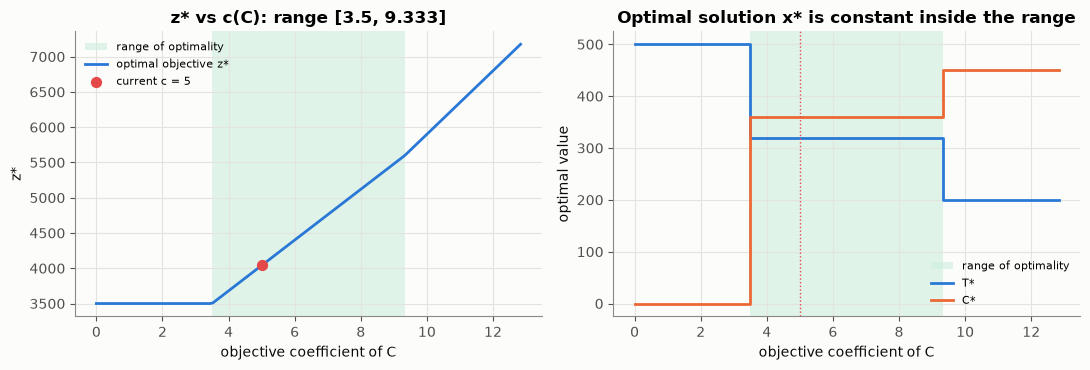

In [13]:
for var in tc.var_names:
    plot_parametric_ofc(tc, var, sens=tc_sens); plt.tight_layout(); plt.show()

### Which corner is optimal for *every* pair $(c_T, c_C)$?
Each corner of the feasible region "owns" a cone of objective directions. The map below colours every $(c_T, c_C)$ pair by the corner that is optimal. The red dot is today's $(7, 5)$; the dashed lines through the origin are the boundaries given by the constraint slopes. Moving **one** coefficient at a time along the dotted guides reproduces the two ranges above.

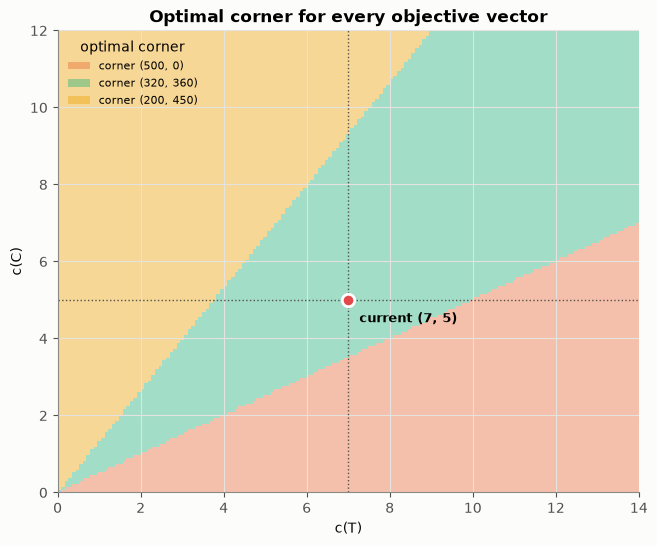

In [14]:
def optimal_corner_map(lp, c1_range, c2_range, n=161, ax=None):
    V = _vertices(_halfplanes(lp))
    g1, g2 = np.linspace(*c1_range, n), np.linspace(*c2_range, n)
    C1, C2 = np.meshgrid(g1, g2)
    vals = np.stack([C1, C2], -1) @ V.T                       # objective of every corner
    idx = np.argmax(vals, -1) if lp.sense == "max" else np.argmin(vals, -1)
    if ax is None: fig, ax = plt.subplots(figsize=(7.5, 6))
    from matplotlib.colors import ListedColormap
    cols = [SERIES[k % 8] for k in range(len(V))]
    ax.imshow(idx, origin="lower", extent=[*c1_range, *c2_range], aspect="auto", cmap=ListedColormap(cols),
              alpha=0.4, vmin=-0.5, vmax=len(V) - 0.5, interpolation="nearest")
    present = [k for k in np.unique(idx) if np.mean(idx == k) > 0.003]
    handles = [Rectangle((0, 0), 1, 1, fc=cols[k], alpha=0.4) for k in present]
    ax.legend(handles, [f"corner ({V[k,0]:g}, {V[k,1]:g})" for k in present], loc="upper left", fontsize=8, title="optimal corner")
    ax.scatter(*lp.c, color=PAL["red"], s=80, zorder=5, edgecolor="white", lw=2)
    ax.annotate(f"current ({lp.c[0]:g}, {lp.c[1]:g})", lp.c, xytext=(8, -16), textcoords="offset points", fontsize=9, fontweight="bold")
    ax.axhline(lp.c[1], color=PAL["ink2"], ls=":", lw=1); ax.axvline(lp.c[0], color=PAL["ink2"], ls=":", lw=1)
    ax.set_xlabel(f"c({lp.var_names[0]})"); ax.set_ylabel(f"c({lp.var_names[1]})")
    ax.set_title("Optimal corner for every objective vector")
    return ax

optimal_corner_map(tc, (0, 14), (0, 12)); plt.show()

### 🎛️ Interactive demo 1 — OFC explorer
Drag the objective coefficients and watch the iso-profit line rotate. The right panel shows each coefficient on its range of optimality (computed for the **original** model; the ranges are valid when **one** coefficient changes at a time).

*Class questions:* At what value of $c_T$ does the optimum jump to $(500, 0)$? What happens exactly at $c_T = 10$ (alternative optima)? Try the other 2-variable problems in the drop-down.

In [15]:
TWO_VAR_FILES = [f for f in list_data_files() if load_lp(f).n == 2 and solve(load_lp(f))["status"] == "optimal"]

def _unobserve(w, f):
    try: w.unobserve(f, "value")
    except ValueError: pass

def _set_slider(s, lo, hi, step, value):
    s.max = max(hi, s.min); s.min = lo; s.max = hi; s.step = step; s.value = value

def _ofc_figure(lp0, c1, c2):
    lp = lp0.copy(c=np.array([c1, c2], float)); base = solve(lp0); r = solve(lp); sens0 = sensitivity(lp0)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[1.35, 1]))
    xl, yl = auto_limits(lp0)
    plot_lp_2d(lp, ax=ax, xlim=xl, ylim=yl, n_iso=1, title=f"{lp0.name}:  {lp0.sense} {c1:g}·{lp0.var_names[0]} + {c2:g}·{lp0.var_names[1]}")
    xs = np.array(xl)
    if abs(lp0.c[1]) > TOL:
        ax.plot(xs, (base["z"] - lp0.c[0] * xs) / lp0.c[1], color=PAL["muted"], lw=1.2, ls=":", label="original iso-line")
    ax.scatter(*base["x"], s=60, facecolor="none", edgecolor=PAL["ink"], lw=1.5, zorder=8)
    same = r["status"] == "optimal" and np.allclose(r["x"], base["x"], atol=1e-6)
    ax.text(0.02, 0.02, "SAME optimal corner" if same else "NEW optimal corner", transform=ax.transAxes, fontsize=11,
            fontweight="bold", color=PAL["green"] if same else PAL["red"], bbox=dict(fc="white", ec=PAL["grid"]))
    plot_ofc_ranges(lp0, sens=sens0, ax=ax2)
    for k, v in enumerate([c1, c2]):
        row = sens0["var"].iloc[k]; ok = row.RangeLow - 1e-9 <= v <= row.RangeHigh + 1e-9
        ax2.plot([v], [k], marker="D", ms=10, color=PAL["green"] if ok else PAL["red"], zorder=6)
    ax2.set_title("Ranges of optimality (◆ = your value, ● = original)")
    fig.tight_layout(); plt.show()
    if r["status"] == "optimal":
        display(Markdown(f"**Optimum:** {lp0.var_names[0]} = {r['x'][0]:,.4g}, {lp0.var_names[1]} = {r['x'][1]:,.4g}; "
                         f"**z\\* = {r['z']:,.4g}** (original z\\* = {base['z']:,.4g})"))


def demo_ofc_explorer(default="01_tables_chairs.json"):
    if not HAS_WIDGETS:
        print("ipywidgets not available – showing a static example."); _ofc_figure(load_lp(default), 8, 5); return
    dd = widgets.Dropdown(options=TWO_VAR_FILES, value=default, description="Problem", layout=widgets.Layout(width="420px"))
    s1 = widgets.FloatSlider(description="c1", continuous_update=False, step=0.05, readout_format=".2f")
    s2 = widgets.FloatSlider(description="c2", continuous_update=False, step=0.05, readout_format=".2f")
    reset = widgets.Button(description="Reset", icon="refresh")
    out = widgets.Output()
    state = {}
    def redraw(*_):
        with out:
            out.clear_output(wait=True); _ofc_figure(state["lp"], s1.value, s2.value)
    def load(*_):
        lp = load_lp(dd.value); state["lp"] = lp
        for s, j in [(s1, 0), (s2, 1)]:
            _unobserve(s, redraw)
            span = max(abs(lp.c[j]) * 2.5, 1.0)
            _set_slider(s, -span if lp.c[j] < 0 else 0.0, span, round(span / 200, 4) or 0.01, lp.c[j]); s.description = f"c({lp.var_names[j]})"
            s.observe(redraw, "value")
        redraw()
    reset.on_click(load); dd.observe(load, "value")
    display(widgets.VBox([widgets.HBox([dd, reset]), widgets.HBox([s1, s2]), out])); load()

demo_ofc_explorer()

---
## 3. Right-Hand-Side (RHS) changes *(slides 13 – 19)*

**What if the painting hours available change from 1000 to 1300?** More of a resource could let us produce more and earn more profit.

**Characteristics of RHS changes (slide 15)**
* The constraint line **shifts** parallel to itself, which can change the feasible region.
* The **slope** of the constraint line does **not** change.
* **Corner-point locations** can change, and so can the **optimal solution**.

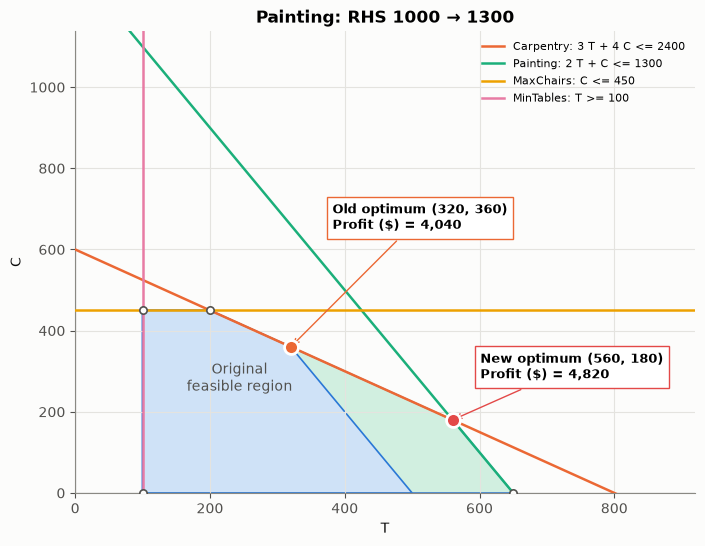

**Effect on the objective function value (slide 17)**

| | |
|---|---|
| New profit | $4,820 |
| Old profit | $4,040 |
| Profit increase | **$780** from 300 additional painting hours |
| Per hour | **$2.60** in profit per hour of painting |

In [16]:
def compare_rhs(lp, con, new_value, ax=None):
    """Reproduces slide 16: original vs enlarged/shrunk feasible region after an RHS change."""
    i = lp.con_index(con); new = lp.with_b(i, new_value); r0, r1 = solve(lp), solve(new)
    xl, yl = auto_limits(new, extra_points=[r0["x"]])
    if ax is None: fig, ax = plt.subplots(figsize=(8, 6))
    plot_lp_2d(new, ax=ax, xlim=xl, ylim=yl, iso=False, show_opt=False, region_color=PAL["region2"], alpha=0.9,
               region_label=None, gradient=False, title=f"{lp.con_names[i]}: RHS {lp.b[i]:g} → {new_value:g}")
    poly0 = _vertices(_halfplanes(lp, (xl, yl)))
    ax.add_patch(Polygon(poly0, closed=True, fc=PAL["region"], ec=PAL["blue"], lw=1.2, alpha=1, zorder=1.5))
    ax.text(*poly0.mean(0), "Original\nfeasible region", ha="center", color=PAL["ink2"], zorder=3)
    for (x, z, lab, col, off) in [(r0["x"], r0["z"], "Old optimum", PAL["orange"], (30, 85)), (r1["x"], r1["z"], "New optimum", PAL["red"], (20, 30))]:
        ax.scatter(*x, s=100, color=col, edgecolor="white", lw=2, zorder=8)
        ax.annotate(f"{lab} ({x[0]:,.4g}, {x[1]:,.4g})\n{lp.objective_name} = {z:,.4g}", x, xytext=off, textcoords="offset points",
                    fontsize=9, fontweight="bold", arrowprops=dict(arrowstyle="->", color=col), bbox=dict(fc="white", ec=col))
    return ax, r0, r1

ax, r0, r1 = compare_rhs(tc, "Painting", 1300); plt.show()
dz, db = r1["z"] - r0["z"], 1300 - 1000
display(Markdown(f"""**Effect on the objective function value (slide 17)**

| | |
|---|---|
| New profit | ${r1['z']:,.0f} |
| Old profit | ${r0['z']:,.0f} |
| Profit increase | **${dz:,.0f}** from {db} additional painting hours |
| Per hour | **${dz/db:.2f}** in profit per hour of painting |"""))

### Shadow price (slide 18)
The **shadow price** of a constraint is the change in the optimal objective value per **one-unit increase** in its RHS. Each additional painting hour increases profit by \$2.60, and each hour lost decreases it by \$2.60.

*Is a painting hour worth \$2.60 no matter how many hours are available?* **No.** The shadow price is valid only within a **range**.

### Range of shadow-price validity (slide 19)
* While the RHS stays within the range, the shadow price does not change, and **Δz\* = (shadow price) × (RHS change)**.
* Beyond the range, the shadow price changes (the set of binding constraints changes).

The table below is the full constraint sensitivity report. Non-binding constraints (with slack) always have shadow price 0: extra units of a resource we are not using are worth nothing.

In [17]:
display(tc_sens["con"][["Constraint", "Sense", "RHS", "Slack", "Binding", "ShadowPrice", "RangeLow", "RangeHigh"]]
        .assign(RangeLow=lambda d: d.RangeLow.map(fmt_range), RangeHigh=lambda d: d.RangeHigh.map(fmt_range))
        .style.hide(axis="index").format(precision=3))
row = tc_sens["con"].set_index("Constraint").loc["Painting"]
print(f"Painting: 1000 -> 1300 is inside [{row.RangeLow:g}, {row.RangeHigh:g}], so Δz* = {row.ShadowPrice} × 300 = {row.ShadowPrice*300:g} ✔")

Constraint,Sense,RHS,Slack,Binding,ShadowPrice,RangeLow,RangeHigh
Carpentry,<=,2400.000,0.000,True,0.600,"1,500","2,625"
Painting,<=,1000.000,0.000,True,2.600,850,"1,600"
MaxChairs,<=,450.000,90.000,False,0.000,360,∞
MinTables,>=,100.000,220.000,False,0.000,-∞,320


Painting: 1000 -> 1300 is inside [850, 1600], so Δz* = 2.6 × 300 = 780 ✔


### Watching the optimum move as painting hours grow
Small multiples for painting hours from 600 to 1800. **Inside the validity range [850, 1600]** the optimum slides along the carpentry line and every hour is worth \$2.60. Below 850 the chair limit becomes binding; above 1600 painting is no longer binding (slack appears) and its shadow price drops to 0.

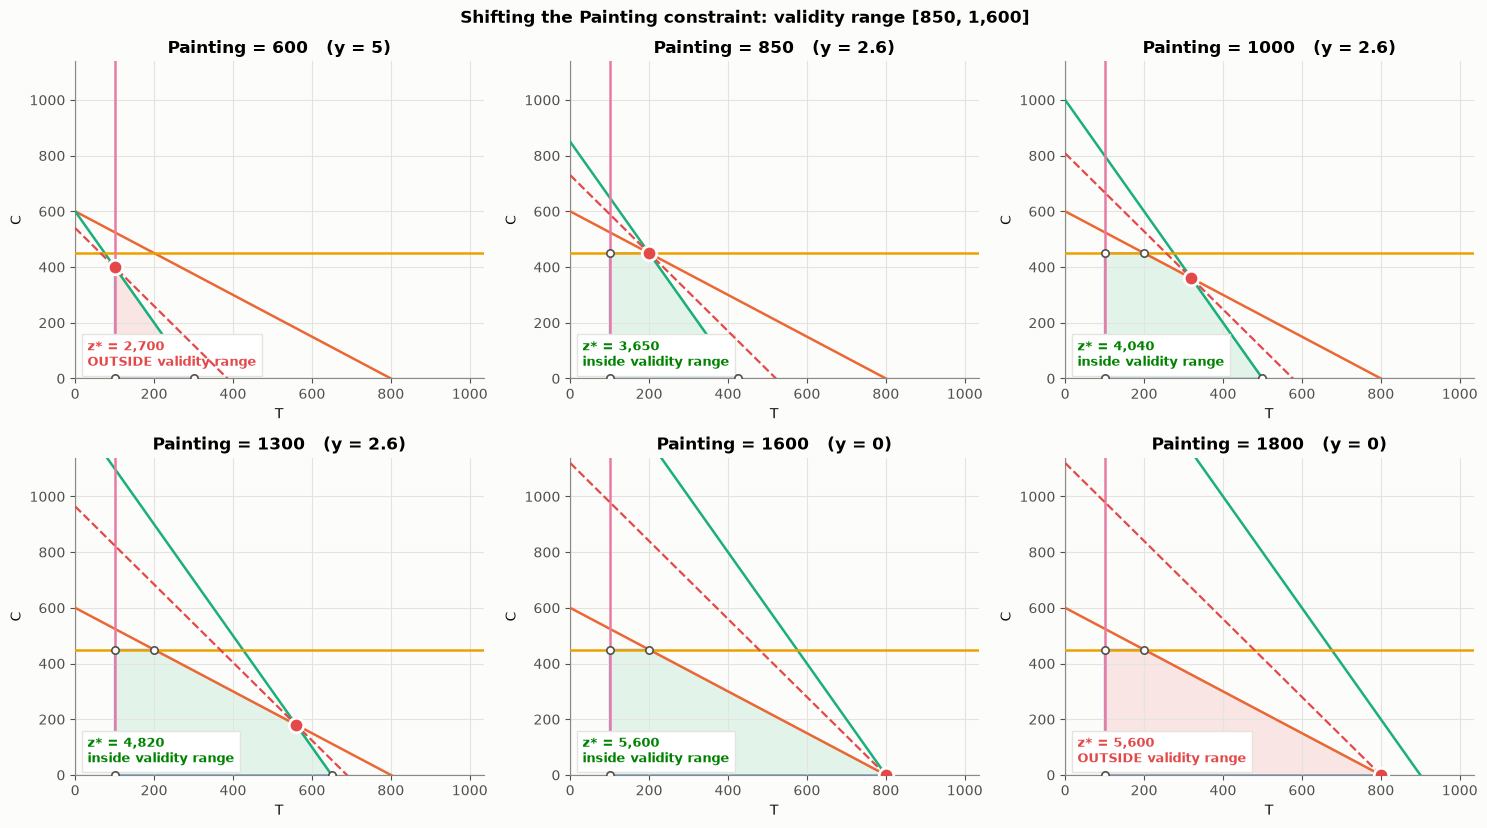

In [18]:
def rhs_small_multiples(lp, con, values, ncols=3):
    i = lp.con_index(con); sens = sensitivity(lp); row = sens["con"].iloc[i]
    xl, yl = auto_limits(lp.with_b(i, max(values)))
    nrows = math.ceil(len(values) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows)); axes = np.ravel(axes)
    for ax, v in zip(axes, values):
        new = lp.with_b(i, v); r = solve(new)
        inside = row.RangeLow - 1e-9 <= v <= row.RangeHigh + 1e-9
        plot_lp_2d(new, ax=ax, xlim=xl, ylim=yl, n_iso=1, opt_label=False, gradient=False, region_label=None,
                   region_color=PAL["region2"] if inside else PAL["bad"],
                   title=f"{lp.con_names[i]} = {v:g}   (y = {r['y'][i]:.3g})")
        ax.get_legend().remove()
        ax.text(0.03, 0.04, f"z* = {r['z']:,.0f}\n{'inside' if inside else 'OUTSIDE'} validity range", transform=ax.transAxes,
                fontsize=9, fontweight="bold", color=PAL["green"] if inside else PAL["red"], bbox=dict(fc="white", ec=PAL["grid"]))
    for ax in axes[len(values):]: ax.axis("off")
    fig.suptitle(f"Shifting the {lp.con_names[i]} constraint: validity range [{fmt_range(row.RangeLow)}, {fmt_range(row.RangeHigh)}]", fontweight="bold")
    fig.tight_layout(); return fig

rhs_small_multiples(tc, "Painting", [600, 850, 1000, 1300, 1600, 1800]); plt.show()

### Parametric view of every RHS
$z^*(b_i)$ is **piecewise linear and concave** (for a max problem); its slope on each piece is the shadow price. The dashed orange line is the prediction $z^* + y_i\,\Delta b_i$; it matches exactly inside the green range.

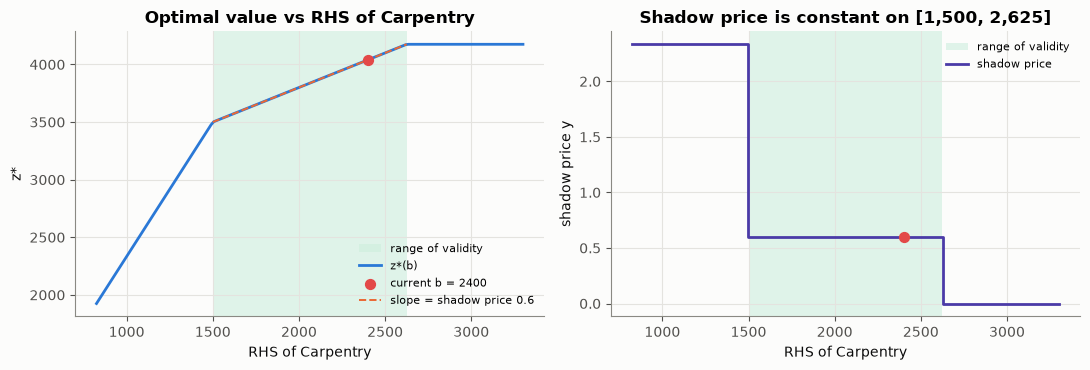

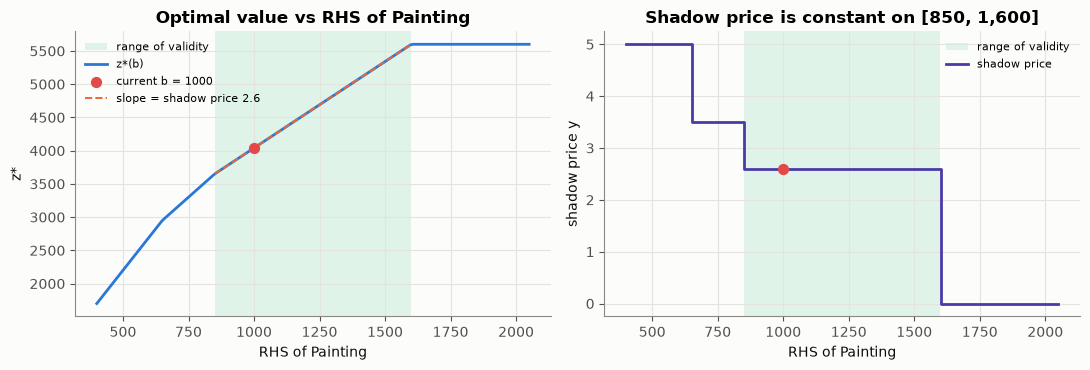

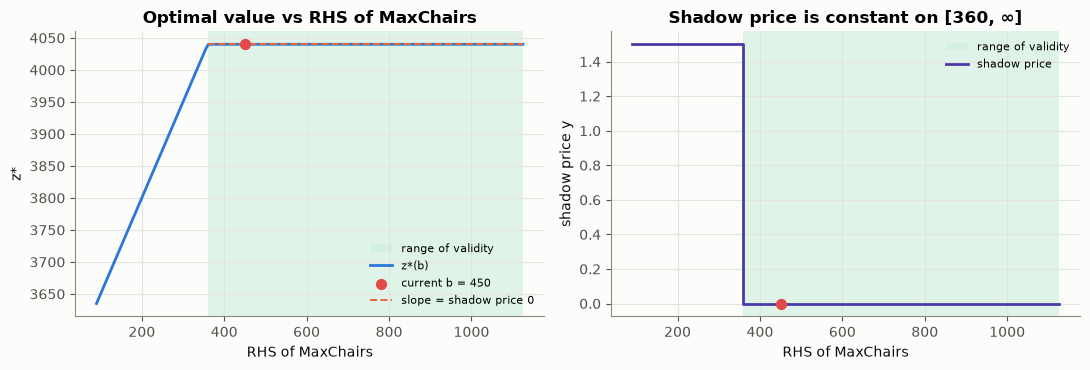

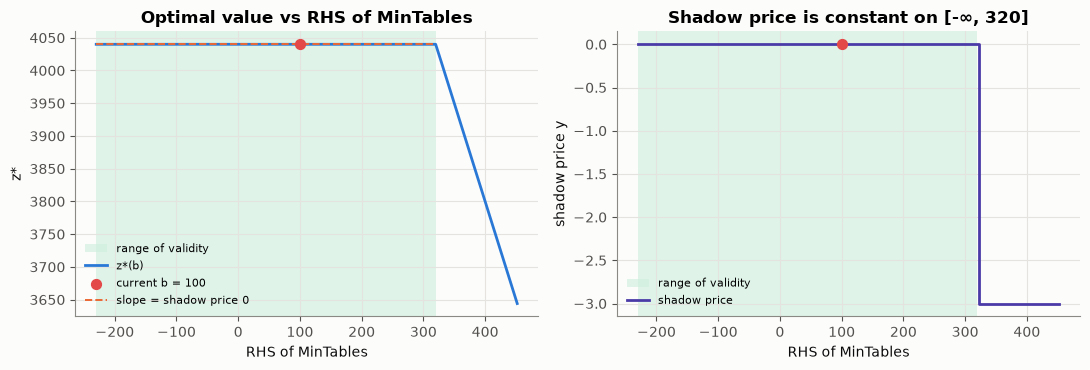

In [19]:
for con in tc.con_names:
    plot_parametric_rhs(tc, con, sens=tc_sens); plt.tight_layout(); plt.show()

### Sensitivity dashboard
One figure that summarises the whole sensitivity report: ranges of optimality, validity ranges, shadow prices and resource usage.

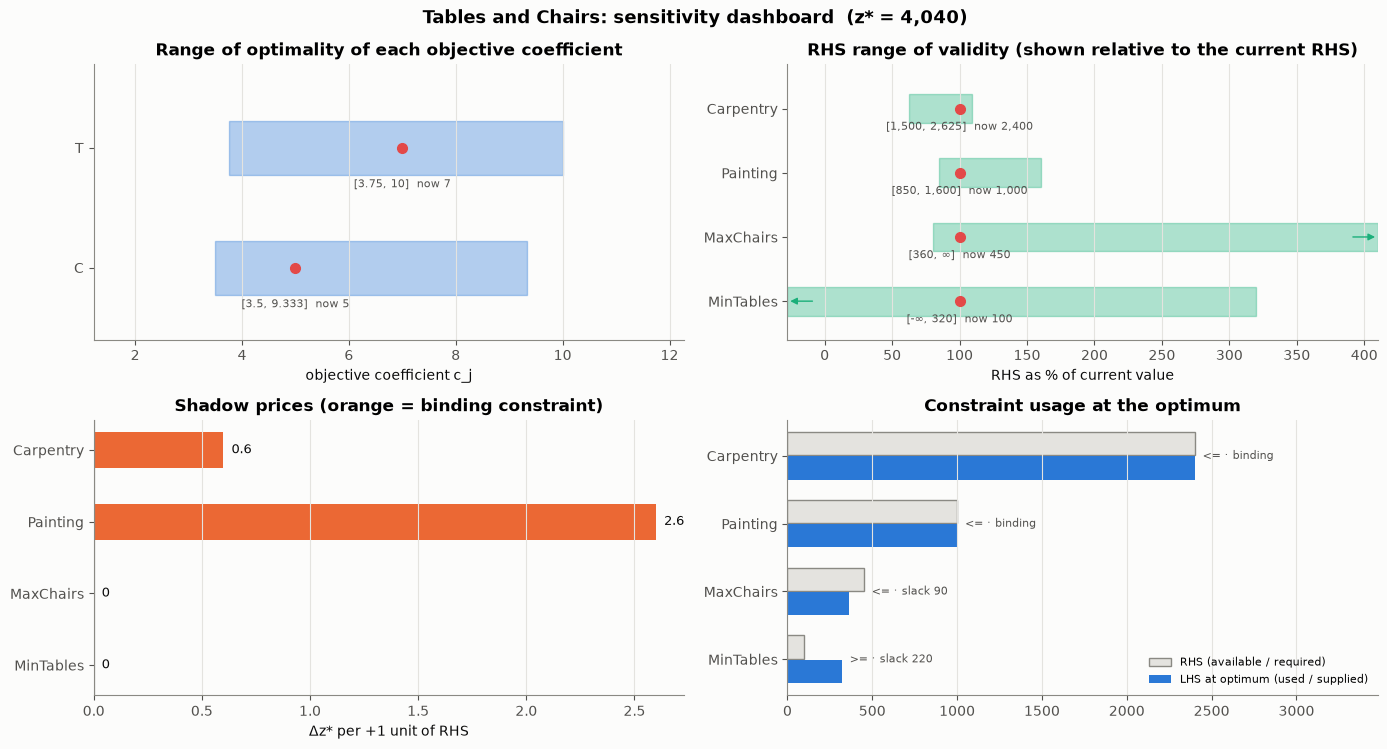

In [20]:
def sensitivity_dashboard(lp, sens=None):
    sens = sens or sensitivity(lp); sol = solve(lp)
    fig, axes = plt.subplots(2, 2, figsize=(14, 3.2 + 0.55 * max(lp.m, lp.n) * 2))
    plot_ofc_ranges(lp, sens, ax=axes[0, 0]); plot_rhs_ranges(lp, sens, ax=axes[0, 1])
    plot_shadow_prices(lp, sens, ax=axes[1, 0]); plot_resource_usage(lp, sol, ax=axes[1, 1])
    fig.suptitle(f"{lp.name}: sensitivity dashboard  (z* = {sens['z']:,.4g})", fontweight="bold", fontsize=13)
    fig.tight_layout(); return fig

sensitivity_dashboard(tc, tc_sens); plt.show()

### 🎛️ Interactive demo 2 — RHS explorer
Pick a problem and a constraint, then move its RHS. Left: the original region (outline) and the new one. Right: $z^*$ as a function of the RHS, with the validity range shaded. The text compares the **shadow-price prediction** with the **true** re-solved value: they agree only inside the range.

In [21]:
def _rhs_figure(lp0, con, value):
    i = lp0.con_index(con); lp = lp0.with_b(i, value); sens0 = sensitivity(lp0); r0 = solve(lp0); r = solve(lp)
    row = sens0["con"].iloc[i]
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[1.2, 1]))
    xl, yl = auto_limits(lp0)
    if r["status"] == "optimal":
        xl2, yl2 = auto_limits(lp); xl = (min(xl[0], xl2[0]), max(xl[1], xl2[1])); yl = (min(yl[0], yl2[0]), max(yl[1], yl2[1]))
        plot_lp_2d(lp, ax=ax, xlim=xl, ylim=yl, n_iso=1, region_color=PAL["region2"], title=f"{lp0.con_names[i]}: RHS {lp0.b[i]:g} → {value:g}")
    else:
        plot_lp_2d(lp, ax=ax, xlim=xl, ylim=yl, iso=False, show_opt=False, title=f"{lp0.con_names[i]} = {value:g}: {r['status'].upper()}")
    P0 = _vertices(_halfplanes(lp0, (xl, yl)))
    if len(P0) >= 3: ax.add_patch(Polygon(P0, closed=True, fill=False, ec=PAL["ink2"], lw=1.5, ls="--", zorder=2))
    ax.scatter(*r0["x"], s=60, facecolor="none", edgecolor=PAL["ink"], lw=1.5, zorder=8)
    a, b = _sweep_window(lp0.b[i], row.RangeLow, row.RangeHigh)
    a, b = min(a, value), max(b, value)
    df = parametric_rhs(lp0, i, np.linspace(a, b, 121))
    ax2.axvspan(max(row.RangeLow, a), min(row.RangeHigh, b), color=PAL["region2"], alpha=0.7, lw=0, label="validity range")
    ax2.plot(df.param, df.z, color=PAL["blue"], label="true z*(b)")
    ax2.plot(df.param, r0["z"] + row.ShadowPrice * (df.param - lp0.b[i]), color=PAL["orange"], ls="--", lw=1.3, label="shadow-price prediction")
    if r["status"] == "optimal": ax2.scatter([value], [r["z"]], color=PAL["red"], s=70, zorder=5, label="your RHS")
    ax2.set_xlabel(f"RHS of {lp0.con_names[i]}"); ax2.set_ylabel("z*"); ax2.legend(fontsize=8); ax2.set_title("Optimal value vs RHS")
    fig.tight_layout(); plt.show()
    inside = row.RangeLow - 1e-9 <= value <= row.RangeHigh + 1e-9
    pred = r0["z"] + row.ShadowPrice * (value - lp0.b[i])
    if r["status"] == "optimal":
        display(Markdown(f"Shadow price **{row.ShadowPrice:,.4g}**, validity range **[{fmt_range(row.RangeLow)}, {fmt_range(row.RangeHigh)}]** → your value is "
                         f"**{'inside' if inside else 'OUTSIDE'}**.  Predicted z\\* = {r0['z']:,.4g} + {row.ShadowPrice:,.4g}×({value:g} − {lp0.b[i]:g}) = **{pred:,.4g}**;  true z\\* = **{r['z']:,.4g}** "
                         f"{'✔' if abs(pred - r['z']) < 1e-6 else '✘ (prediction no longer valid)'}. New shadow price: {r['y'][i]:,.4g}."))
    else:
        display(Markdown(f"The model becomes **{r['status']}** at this RHS."))


def demo_rhs_explorer(default="01_tables_chairs.json", con="Painting"):
    if not HAS_WIDGETS:
        print("ipywidgets not available – static example."); _rhs_figure(load_lp(default), con, 1300); return
    dd = widgets.Dropdown(options=TWO_VAR_FILES, value=default, description="Problem", layout=widgets.Layout(width="420px"))
    cd = widgets.Dropdown(description="Constraint")
    sl = widgets.FloatSlider(description="RHS", continuous_update=False, layout=widgets.Layout(width="520px"))
    out = widgets.Output(); state = {}
    def redraw(*_):
        with out:
            out.clear_output(wait=True); _rhs_figure(state["lp"], cd.value, sl.value)
    def set_con(*_):
        lp = state["lp"]; i = lp.con_index(cd.value); b0 = lp.b[i]
        _unobserve(sl, redraw)
        span = max(abs(b0), 1.0)
        lo, hi = (b0 - 1.5 * span, b0 + 1.5 * span) if b0 <= 0 else (0.0, 2.5 * b0)
        _set_slider(sl, lo, hi, span / 100, b0)
        sl.observe(redraw, "value"); redraw()
    def load(*_):
        state["lp"] = load_lp(dd.value)
        _unobserve(cd, set_con); cd.options = state["lp"].con_names
        cd.value = con if con in state["lp"].con_names else state["lp"].con_names[0]
        cd.observe(set_con, "value"); set_con()
    dd.observe(load, "value")
    display(widgets.VBox([widgets.HBox([dd, cd]), sl, out])); load()

demo_rhs_explorer()

✏️ **Your turn (sections 2 – 3)**
1. Using the sensitivity report, what is the profit if the chair profit rises to \$9? To \$10? (Check with `solve(tc.with_c("C", 9))`.)
2. Carpentry hours drop from 2400 to 2000. Is this inside the validity range? Predict the new profit with the shadow price and verify.
3. Why is the shadow price of `MaxChairs` zero? How many chairs could the limit drop to before it matters?

In [22]:
# Your work here, e.g.
# solve(tc.with_c("C", 9))
# tc_sens["con"]

---
## 4. Duality theory *(slides 20 – 23)*

Like the famous picture that shows *either* a young woman *or* an old woman depending on how you look at it (slide 21), every LP has **two views**: the **primal** problem and its **dual** problem. They use the same data, arranged differently, and they have the same optimal value.

**Canonical pair (slide 22)**
$$\text{(Primal)}\quad \min\; c\,x \quad \text{s.t.}\quad Ax \ge b,\; x \ge 0 \qquad\qquad \text{(Dual)}\quad \max\; y\,b \quad \text{s.t.}\quad yA \le c,\; y \ge 0$$

* one **dual variable $y_i$ per primal constraint**, and one **dual constraint per primal variable $x_j$**;
* the primal RHS $b$ becomes the dual objective, the primal objective $c$ becomes the dual RHS, and $A$ is **transposed**.

### Example (slide 23)

In [23]:
ex = load_lp("03_duality_example.json")
ex_dual = dualize(ex)
ex.show("Primal"); ex_dual.show("Dual")
p, d = solve(ex), solve(ex_dual)
print(f"Primal optimum: x* = {p['x']},  z* = {p['z']:g}")
print(f"Dual optimum:   y* = {d['x']},  w* = {d['z']:g}")
print(f"Dual values reported by the primal solver (shadow prices): {p['y']}  ← the same numbers!")

**Primal**

<IPython.core.display.Math object>

**Dual**

<IPython.core.display.Math object>

Primal optimum: x* = [2.5 0.  0. ],  z* = 7.5
Dual optimum:   y* = [0.  1.5],  w* = 7.5
Dual values reported by the primal solver (shadow prices): [0.  1.5]  ← the same numbers!


### Seeing the transpose (slide 61)
The primal data block $\begin{bmatrix} A & b \\ c & \end{bmatrix}$ turns on its side to give the dual block. Rows become columns: **constraint $i$ ↔ dual variable $y_i$** and **variable $x_j$ ↔ dual constraint $j$**.

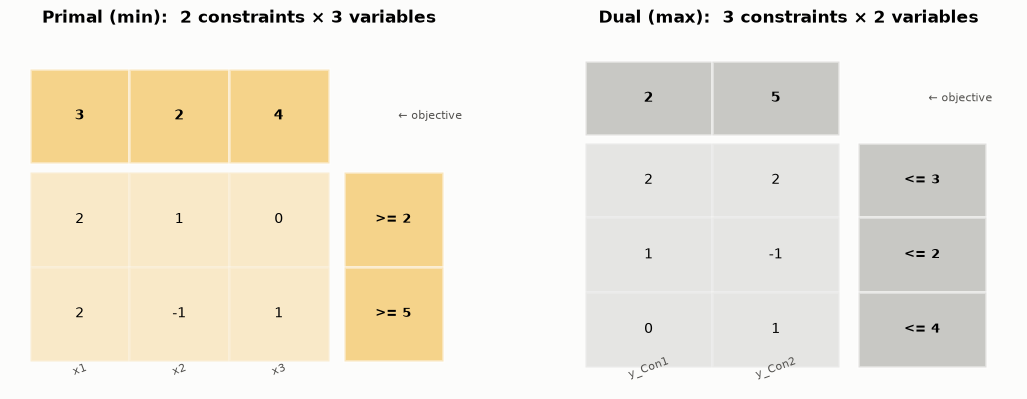

In [24]:
def plot_transpose(lp, dual=None, axes=None):
    dual = dual or dualize(lp)
    if axes is None: fig, axes = plt.subplots(1, 2, figsize=(13, 3.6 + 0.35 * max(lp.m, lp.n)))
    for ax, L, ttl, col in [(axes[0], lp, f"Primal ({lp.sense})", PAL["yellow"]), (axes[1], dual, f"Dual ({dual.sense})", PAL["muted"])]:
        m, n = L.m, L.n
        ax.set_xlim(-0.2, n + 1.4); ax.set_ylim(m + 1.4, -0.4); ax.axis("off")
        for j in range(n):
            ax.add_patch(Rectangle((j, 0), 1, 1, fc=col, alpha=0.45, ec="white", lw=2)); ax.text(j + .5, .5, f"{L.c[j]:g}", ha="center", va="center", fontweight="bold")
            ax.text(j + .5, m + 1.25, L.var_names[j], ha="center", fontsize=8, color=PAL["ink2"], rotation=20)
        ax.text(n + 0.7, 0.5, "← objective", va="center", fontsize=8, color=PAL["ink2"])
        for i in range(m):
            for j in range(n):
                ax.add_patch(Rectangle((j, i + 1.1), 1, 1, fc=col, alpha=0.2, ec="white", lw=2))
                ax.text(j + .5, i + 1.6, f"{L.A[i, j]:g}", ha="center", va="center")
            ax.add_patch(Rectangle((n + 0.15, i + 1.1), 1, 1, fc=col, alpha=0.45, ec="white", lw=2))
            ax.text(n + 0.65, i + 1.6, f"{L.con_sense[i]} {L.b[i]:g}", ha="center", va="center", fontweight="bold", fontsize=9)
        ax.set_title(ttl + f":  {m} constraints × {n} variables")
    return axes

plot_transpose(ex); plt.show()

### Solving the dual graphically
The dual of this example has only **two** variables, so we can draw it even though the primal has three. Its optimal corner gives $w^* = 7.5$, equal to the primal optimum $z^* = 7.5$.

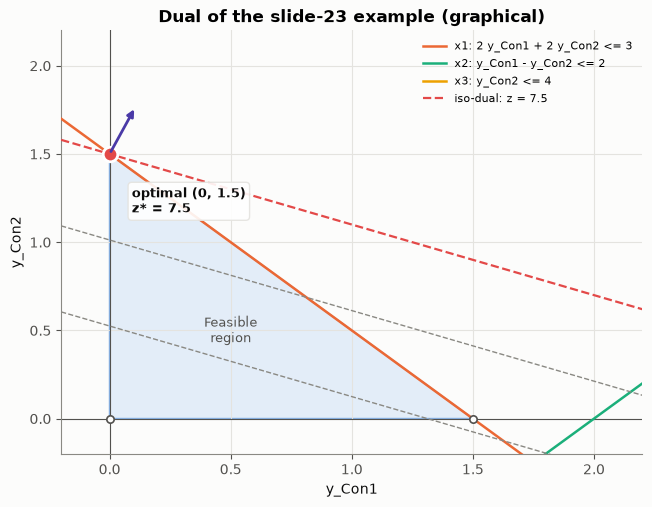

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_lp_2d(ex_dual, ax=ax, xlim=(-0.2, 2.2), ylim=(-0.2, 2.2), title="Dual of the slide-23 example (graphical)")
plt.show()

### General rules for building a dual
`dualize()` implements the table printed in section 0.1, so it also handles `=` constraints, `≥` constraints in a max problem, and free or non-positive variables.

### 🎛️ Interactive demo 3 — primal ↔ dual formulation explorer
Choose any data file: the notebook writes the dual, solves both, and checks the key properties.

In [26]:
def primal_dual_panel(fname):
    lp = load_lp(fname); d = dualize(lp); p, q = solve(lp), solve(d)
    lp.show(f"Primal – {lp.name}"); d.show("Dual")
    rows = [("Status", p["status"], q["status"])]
    if p["status"] == "optimal":
        rows += [("Optimal value", f"{p['z']:,.6g}", f"{q['z']:,.6g}"),
                 ("Solution", ", ".join(f"{n}={v:.4g}" for n, v in zip(lp.var_names, p["x"])),
                  ", ".join(f"{n}={v:.4g}" for n, v in zip(d.var_names, q["x"]))),
                 ("Primal shadow prices = dual solution?", ", ".join(f"{v:.4g}" for v in p["y"]), "✔" if np.allclose(p["y"], q["x"], atol=1e-6) else "✘")]
    rows.append(("Dual of the dual = primal?", "✔" if same_lp(dualize(d), lp) else "✘", ""))
    display(pd.DataFrame(rows, columns=["", "Primal", "Dual"]).style.hide(axis="index"))
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2 + 0.35 * max(lp.m, lp.n)))
    plot_transpose(lp, d, axes=axes); plt.show()

if HAS_WIDGETS:
    widgets.interact(primal_dual_panel, fname=widgets.Dropdown(options=list_data_files(), value="03_duality_example.json", description="Problem",
                                                               layout=widgets.Layout(width="480px")));
else:
    primal_dual_panel("03_duality_example.json")

interactive(children=(Dropdown(description='Problem', index=2, layout=Layout(width='480px'), options=('01_tabl…

---
## 5. Economic interpretation: the dual of a **max** problem *(slides 24 – 38)*

**Dakota Furniture** makes desks, tables and chairs from lumber, finishing hours and carpentry hours. 48 board-ft of lumber, 20 finishing hours and 8 carpentry hours are available. A desk sells for \$60, a table for \$30 and a chair for \$20. The resources are already purchased, so Dakota maximises revenue.

In [27]:
dk = load_lp("04_dakota_furniture.json")
display(pd.DataFrame(np.column_stack([dk.A, dk.b]), index=dk.con_names, columns=dk.var_names + ["Available"])
        .pipe(lambda d: pd.concat([d, pd.DataFrame([list(dk.c) + [np.nan]], index=["Selling price ($)"], columns=d.columns)]))
        .style.format(precision=2, na_rep=""))
dk.show("Dakota primal (slide 28)")
dk_dual = dualize(dk); dk_dual.show("Dakota dual (slide 29)")

,Desks,Tables,Chairs,Available
Lumber,8.00,6.00,1.00,48.00
Finishing,4.00,2.00,1.50,20.00
Carpentry,2.00,1.50,0.50,8.00
Selling price ($),60.00,30.00,20.00,


**Dakota primal (slide 28)**

<IPython.core.display.Math object>

**Dakota dual (slide 29)**

<IPython.core.display.Math object>

### The entrepreneur's story (slides 31 – 37)
An entrepreneur wants to **buy all of Dakota's resources**. Let $y_1, y_2, y_3$ be the prices she offers per board-ft of lumber, per finishing hour and per carpentry hour.

* She wants to pay as little as possible: $\min\; w = 48y_1 + 20y_2 + 8y_3$.
* But the prices must be **high enough to make Dakota sell**. Dakota could turn 8 board-ft, 4 finishing hours and 2 carpentry hours into a desk worth \$60, so $8y_1 + 4y_2 + 2y_3 \ge 60$ (desk constraint). Similarly for tables ($\ge 30$) and chairs ($\ge 20$).

The **$i$-th dual variable** is the value of the **$i$-th resource**. This is why dual variables are called **resource shadow prices**.

In [28]:
dk_p, dk_d = solve(dk), solve(dk_dual)
dk_sens = sensitivity(dk)
display(Markdown(f"**Primal:** desks = {dk_p['x'][0]:g}, tables = {dk_p['x'][1]:g}, chairs = {dk_p['x'][2]:g}; revenue **${dk_p['z']:,.0f}**  \n"
                 f"**Dual:** y(lumber) = {dk_d['x'][0]:g}, y(finishing) = {dk_d['x'][1]:g}, y(carpentry) = {dk_d['x'][2]:g}; cost of buying everything **${dk_d['z']:,.0f}**"))
res_tab = pd.DataFrame({"Available": dk.b, "Used": dk_p["lhs"], "Price y_i ($/unit)": dk_d["x"], "Value b_i·y_i ($)": dk.b * dk_d["x"]}, index=dk.con_names)
display(res_tab.style.format(precision=2))

**Primal:** desks = 2, tables = 0, chairs = 8; revenue **$280**  
**Dual:** y(lumber) = 0, y(finishing) = 10, y(carpentry) = 10; cost of buying everything **$280**

,Available,Used,Price y_i ($/unit),Value b_i·y_i ($)
Lumber,48.00,24.00,0.00,0.00
Finishing,20.00,20.00,10.00,200.00
Carpentry,8.00,8.00,10.00,80.00


The figure checks every **dual constraint**: the stacked bar is what the entrepreneur pays for the resources inside one unit of each product; the dashed mark is the product's selling price.
* Desks and chairs: payment **equals** the price, and these are exactly the products Dakota makes.
* Tables: the resources in a table are worth \$35 > \$30, so making tables would lose \$5 of resource value per table (the **reduced cost**). Dakota makes none.

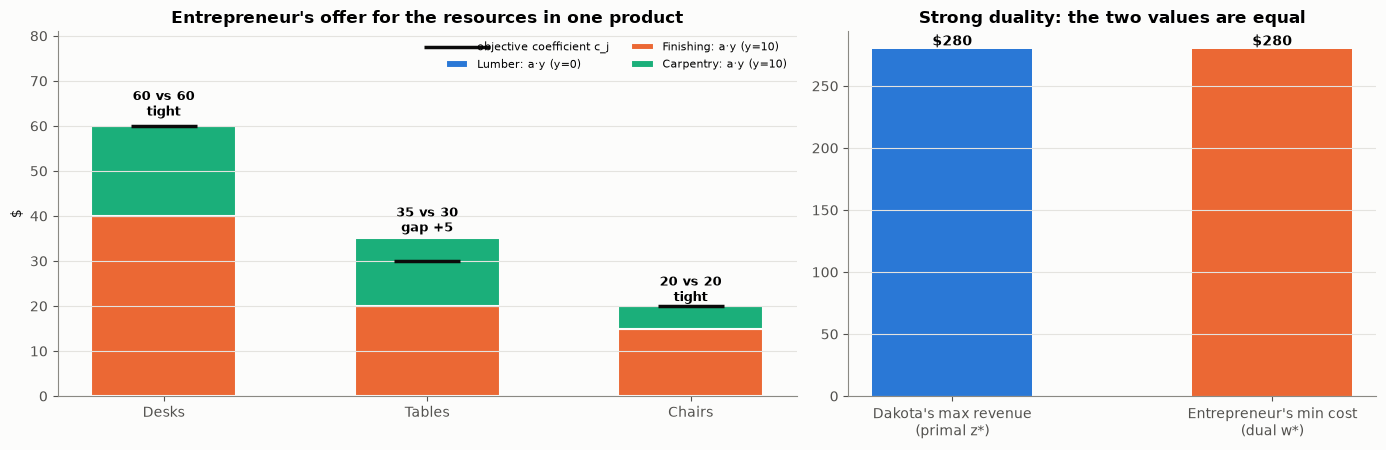

In [29]:
def plot_dual_constraints(lp, y, ax=None, title=None, unit="$"):
    """For each primal variable j: stacked contributions a_ij*y_i vs objective coefficient c_j."""
    if ax is None: fig, ax = plt.subplots(figsize=(8, 4.2))
    x = np.arange(lp.n); bottom = np.zeros(lp.n)
    for i in range(lp.m):
        v = lp.A[i] * y[i]
        ax.bar(x, v, bottom=bottom, width=0.55, color=SERIES[i % 8], label=f"{lp.con_names[i]}: a·y (y={y[i]:.3g})", edgecolor=PAL["surface"], lw=1.5)
        bottom += v
    ax.scatter(x, lp.c, marker="_", s=2200, color=PAL["ink"], lw=2.5, zorder=5, label="objective coefficient c_j")
    for k in range(lp.n):
        diff = bottom[k] - lp.c[k]
        ax.text(k, max(bottom[k], lp.c[k]) * 1.03 + 0.5, f"{bottom[k]:.4g} vs {lp.c[k]:g}\n" + ("tight" if abs(diff) < 1e-7 else f"gap {diff:+.4g}"),
                ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(lp.var_names); ax.grid(axis="x", visible=False)
    ax.set_ylim(0, max(bottom.max(), lp.c.max()) * 1.35)
    ax.set_title(title or "Dual constraints: value of resources in each product vs its objective coefficient")
    ax.set_ylabel(unit); ax.legend(fontsize=8, loc="upper right", ncol=2)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw=dict(width_ratios=[1.4, 1]))
plot_dual_constraints(dk, dk_d["x"], ax=axes[0], title="Entrepreneur's offer for the resources in one product")
axes[1].bar(["Dakota's max revenue\n(primal z*)", "Entrepreneur's min cost\n(dual w*)"], [dk_p["z"], dk_d["z"]], color=[PAL["blue"], PAL["orange"]], width=0.5)
for k, v in enumerate([dk_p["z"], dk_d["z"]]): axes[1].text(k, v, f"${v:,.0f}", ha="center", va="bottom", fontweight="bold")
axes[1].set_title("Strong duality: the two values are equal"); axes[1].grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

### 🎛️ Interactive demo 4 — *You are the entrepreneur*
Set the price you offer for each resource. Dakota sells only if **every** product's resource bundle is paid at least its selling price (all bars reach their mark). Try to buy all resources for **less than \$280**… you can't: that is **weak duality**. The cheapest acceptable offer costs exactly \$280, the optimal dual solution.

In [30]:
def _pricing_game(lp, y, who, buyer_goal, unit="$"):
    y = np.asarray(y, float); d = dualize(lp); opt = solve(d)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw=dict(width_ratios=[1.5, 1]))
    plot_dual_constraints(lp, y, ax=ax, title=f"{who}: value of each bundle at your prices", unit=unit)
    lhs = y @ lp.A; ok = lhs >= lp.c - 1e-9 if lp.sense == "max" else lhs <= lp.c + 1e-9
    total = y @ lp.b
    ax2.barh(["your offer", "optimal dual w*"], [total, opt["z"]], color=[PAL["green"] if ok.all() else PAL["red"], PAL["muted"]], height=0.5)
    for k, v in enumerate([total, opt["z"]]): ax2.text(v, k, f"  {v:,.4g}", va="center", fontweight="bold")
    ax2.set_title("Objective of the dual (b · y)"); ax2.grid(axis="y", visible=False); ax2.set_xlim(0, max(total, opt["z"]) * 1.35)
    fig.tight_layout(); plt.show()
    bad = [lp.var_names[j] for j in range(lp.n) if not ok[j]]
    if bad:
        display(Markdown(f"❌ **Not acceptable**: {buyer_goal[0]} for {', '.join(bad)}. (Dual constraints violated.)"))
    else:
        gap = total - opt["z"]
        display(Markdown(f"✅ **Acceptable offer**, objective {total:,.4g}. " + ("🎯 **Optimal!** You found the dual solution." if abs(gap) < 1e-6
                         else f"You could do {abs(gap):,.4g} better ({buyer_goal[1]}).")))


def demo_entrepreneur():
    lp = dk
    if not HAS_WIDGETS: _pricing_game(lp, [2, 8, 10], "Entrepreneur", ("prices too LOW", "lower some prices")); return
    sl = [widgets.FloatSlider(value=v, min=0, max=30, step=0.5, description=f"y {nm}", continuous_update=False,
                              style={"description_width": "110px"}, layout=widgets.Layout(width="420px"))
          for v, nm in zip([2, 8, 10], lp.con_names)]
    out = widgets.interactive_output(lambda **kw: _pricing_game(lp, [kw[f"y{i}"] for i in range(lp.m)], "Entrepreneur",
                                                                ("prices too LOW – Dakota would rather build the product", "lower some prices")),
                                     {f"y{i}": s for i, s in enumerate(sl)})
    display(widgets.VBox(sl + [out]))

demo_entrepreneur()

---
## 6. Economic interpretation: the dual of a **min** problem *(slides 39 – 48)*

**Diet problem.** All food must come from four "basic food groups": brownies (50¢), chocolate ice cream (20¢/scoop), cola (30¢/bottle) and pineapple cheesecake (80¢/piece). Each day we need at least 500 calories, 6 oz chocolate, 10 oz sugar and 8 oz fat, at **minimum cost**.

In [31]:
dt = load_lp("05_diet_problem.json")
display(pd.DataFrame(np.column_stack([dt.A.T, dt.c]), index=dt.var_names, columns=dt.con_names + ["Price (¢)"])
        .pipe(lambda d: pd.concat([d, pd.DataFrame([list(dt.b) + [np.nan]], index=["Requirement"], columns=d.columns)]))
        .style.format(precision=0, na_rep=""))
dt.show("Diet primal (slide 41)")
dt_dual = dualize(dt); dt_dual.show("Diet dual (slide 42)")

,Calories,Chocolate,Sugar,Fat,Price (¢)
Brownie,400,3,2,2,50
IceCream,200,2,2,4,20
Cola,150,0,4,1,30
Cheesecake,500,0,4,5,80
Requirement,500,6,10,8,


**Diet primal (slide 41)**

<IPython.core.display.Math object>

**Diet dual (slide 42)**

<IPython.core.display.Math object>

### Candice, the nutrient salesperson (slides 43 – 47)
Candice sells **pure nutrients**: she charges $y_1$ per calorie, $y_2$ per oz of chocolate, $y_3$ per oz of sugar and $y_4$ per oz of fat.
* She wants to **maximise revenue** from selling the daily ration: $\max\; 500y_1 + 6y_2 + 10y_3 + 8y_4$.
* Her prices must be **low enough** that the dieter prefers buying nutrients from her. A brownie (50¢) gives 400 cal, 3 oz chocolate, 2 oz sugar and 2 oz fat, so $400y_1 + 3y_2 + 2y_3 + 2y_4 \le 50$ (brownie constraint), and the same for the other foods.

The optimal $y_i$ is the **price of one unit of the nutrient** in the $i$-th primal constraint.

**Cheapest diet:** Brownie = 0, IceCream = 3, Cola = 1, Cheesecake = 0  → cost **90¢**  
**Candice's prices:** Calories = 0¢, Chocolate = 2.5¢, Sugar = 7.5¢, Fat = 0¢ → revenue **90¢**

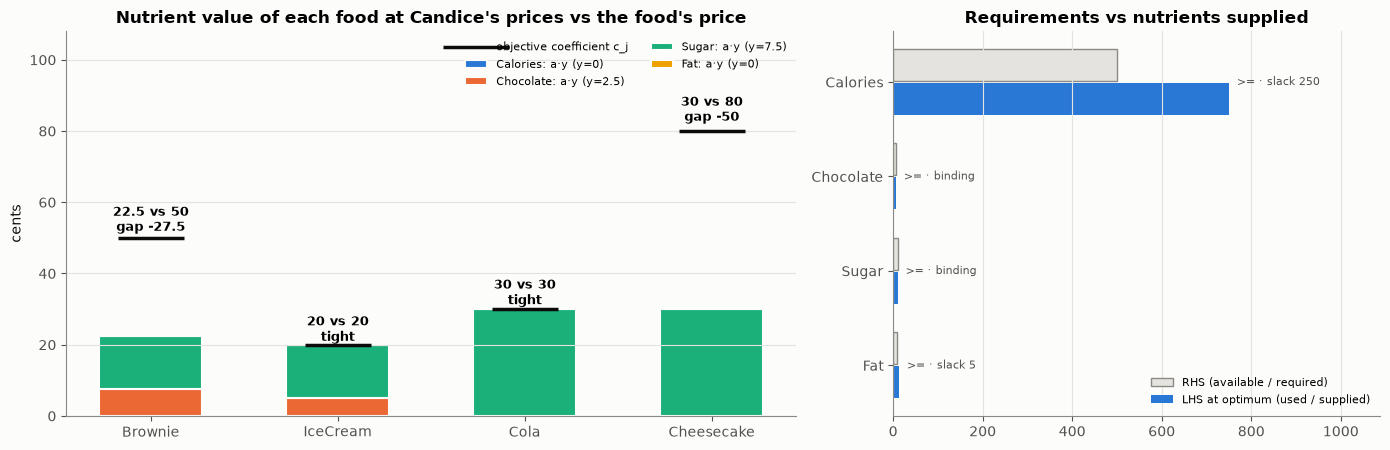

Only chocolate and sugar have positive prices: they are the binding requirements. Calories and fat are over-supplied, so their price is 0.
Brownies and cheesecake are over-priced relative to their nutrient value (gap > 0), so the optimal diet uses none.


In [32]:
dt_p, dt_d = solve(dt), solve(dt_dual); dt_sens = sensitivity(dt)
display(Markdown(f"**Cheapest diet:** " + ", ".join(f"{n} = {v:g}" for n, v in zip(dt.var_names, dt_p["x"])) + f"  → cost **{dt_p['z']:g}¢**  \n"
                 f"**Candice's prices:** " + ", ".join(f"{n} = {v:g}¢" for n, v in zip(dt.con_names, dt_d["x"])) + f" → revenue **{dt_d['z']:g}¢**"))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw=dict(width_ratios=[1.5, 1]))
plot_dual_constraints(dt, dt_d["x"], ax=axes[0], unit="cents", title="Nutrient value of each food at Candice's prices vs the food's price")
plot_resource_usage(dt, dt_p, ax=axes[1]); axes[1].set_title("Requirements vs nutrients supplied")
fig.tight_layout(); plt.show()
print("Only chocolate and sugar have positive prices: they are the binding requirements. Calories and fat are over-supplied, so their price is 0.")
print("Brownies and cheesecake are over-priced relative to their nutrient value (gap > 0), so the optimal diet uses none.")

### 🎛️ Interactive demo 5 — *You are Candice*
Set nutrient prices (in ¢). Every food's nutrient value must stay **at or below** its price, or the dieter just buys the food. Maximise your revenue: can you beat 90¢?

In [33]:
def demo_candice():
    lp = dt
    if not HAS_WIDGETS: _pricing_game(lp, [0, 2, 5, 1], "Candice", ("prices too HIGH", "raise some prices"), unit="cents"); return
    maxes = [0.2, 20, 20, 20]; steps = [0.005, 0.25, 0.25, 0.25]
    sl = [widgets.FloatSlider(value=v, min=0, max=mx, step=st, description=f"y {nm}", continuous_update=False, readout_format=".3f",
                              style={"description_width": "110px"}, layout=widgets.Layout(width="420px"))
          for v, nm, mx, st in zip([0, 2, 5, 1], lp.con_names, maxes, steps)]
    out = widgets.interactive_output(lambda **kw: _pricing_game(lp, [kw[f"y{i}"] for i in range(lp.m)], "Candice",
                                                                ("prices too HIGH – the dieter would buy the food instead", "raise some prices"), unit="cents"),
                                     {f"y{i}": s for i, s in enumerate(sl)})
    display(widgets.VBox(sl + [out]))

demo_candice()

**Summary (slide 48).** When the primal is a normal max problem (≤ constraints) or a normal min problem (≥ constraints), the dual has an intuitive economic meaning: **the dual variables are the values (prices) of the resources or requirements** in the primal constraints.

---
## 7. Properties of duality *(slides 49 – 56)*

### 7.1 The dual of the dual is the primal
Applying `dualize()` twice returns the original data for **every** file in the `data/` folder:

In [34]:
rows = []
for f in list_data_files():
    lp = load_lp(f); d = dualize(lp); dd = dualize(d)
    rows.append(dict(File=f, Primal=f"{lp.sense} · {lp.m}×{lp.n}", Dual=f"{d.sense} · {d.m}×{d.n}", **{"dual(dual(P)) == P": "✔" if same_lp(dd, lp) else "✘"}))
display(pd.DataFrame(rows).style.hide(axis="index"))

File,Primal,Dual,dual(dual(P)) == P
01_tables_chairs.json,max · 4×2,min · 2×4,✔
02_cover_example.json,max · 2×2,min · 2×2,✔
03_duality_example.json,min · 2×3,max · 3×2,✔
04_dakota_furniture.json,max · 3×3,min · 3×3,✔
05_diet_problem.json,min · 4×4,max · 4×4,✔
06_infeasible_primal_infeasible_dual.json,min · 2×2,max · 2×2,✔
07_infeasible_primal_unbounded_dual.json,min · 2×2,max · 2×2,✔
08_unbounded_primal.json,max · 1×2,min · 2×1,✔
09_practice_wyndor.json,max · 3×2,min · 2×3,✔
10_practice_feed_mix.json,min · 3×2,max · 2×3,✔


### 7.2 Weak duality (slides 51 & 53)
For a min primal ($\min cx,\ Ax \ge b,\ x\ge 0$) and its dual, take **any** feasible $x$ and **any** feasible $\Pi$ (dual prices):
$$ c\,x \;\ge\; \Pi A x \;\ge\; \Pi\, b .$$
Every primal objective value is an upper bound for every dual value (for a max primal the inequality flips). The picture on slide 51 shows the two sequences closing in on the common optimum $*$ from opposite sides.

Below we **sample thousands of random feasible solutions** of the Dakota primal and of its dual. Every primal revenue lies below \$280, every dual cost lies above it, and they meet only at the optimum.

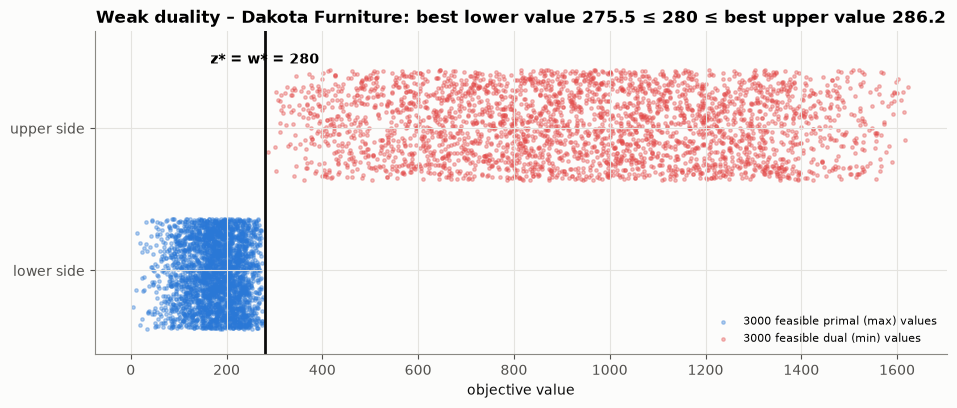

In [35]:
def sample_feasible(lp, n_samples=3000, seed=1, box_scale=3.0, thin=5):
    """Random feasible points of an LP by hit-and-run sampling (the region is clipped to a box if unbounded)."""
    rng = np.random.default_rng(seed)
    G, h = [], []
    for i, s in enumerate(lp.con_sense):
        if s == "=": raise ValueError("sampler supports only <= / >= constraints")
        G.append(lp.A[i] if s == "<=" else -lp.A[i]); h.append(lp.b[i] if s == "<=" else -lp.b[i])
    for j, sg in enumerate(lp.var_signs):
        e = np.eye(lp.n)[j]
        if sg == ">=0": G.append(-e); h.append(0.0)
        if sg == "<=0": G.append(e); h.append(0.0)
    G, h = np.array(G, float), np.array(h, float)
    # box from a few random-objective vertices
    V = []
    for _ in range(12):
        r = linprog(rng.normal(size=lp.n), A_ub=G, b_ub=h, bounds=[(None, None)] * lp.n, method="highs")
        if r.status == 0: V.append(r.x)
    sol = solve(lp)
    if sol["status"] == "optimal": V.append(sol["x"])
    U = box_scale * (np.max(np.abs(V), axis=0) if V else np.ones(lp.n)) + 1
    G = np.vstack([G, np.eye(lp.n), -np.eye(lp.n)]); h = np.concatenate([h, U, U])
    V = [v for v in V if np.all(G @ v <= h + 1e-7)]
    x = np.mean(V, axis=0) if V else np.zeros(lp.n)
    # nudge towards a strictly interior point (Chebyshev centre)
    norms = np.linalg.norm(G, axis=1)
    r = linprog(np.r_[np.zeros(lp.n), -1], A_ub=np.column_stack([G, norms]), b_ub=h, bounds=[(None, None)] * lp.n + [(0, None)], method="highs")
    if r.status == 0: x = r.x[:-1]
    pts = []
    for k in range(n_samples * thin):
        d = rng.normal(size=lp.n); d /= np.linalg.norm(d)
        Gd, slack = G @ d, h - G @ x
        lo = np.max(slack[Gd < -1e-12] / Gd[Gd < -1e-12]) if np.any(Gd < -1e-12) else -1.0
        hi = np.min(slack[Gd > 1e-12] / Gd[Gd > 1e-12]) if np.any(Gd > 1e-12) else 1.0
        x = x + rng.uniform(lo, hi) * d
        if k % thin == 0: pts.append(x.copy())
    P = np.array(pts)
    return P, P @ lp.c


def plot_weak_duality(lp, n_samples=3000, ax=None):
    d = dualize(lp); p, q = solve(lp), solve(d)
    # sampling box for the primal: bounded by resource limits; for the dual: a few times the optimal prices
    Xp, zp = sample_feasible(lp, n_samples)
    Yd, zd = sample_feasible(d, n_samples, box_scale=1.2)
    if ax is None: fig, ax = plt.subplots(figsize=(11, 4.2))
    rng = np.random.default_rng(0)
    lo_vals, hi_vals = (zp, zd) if lp.sense == "max" else (zd, zp)
    lo_lab, hi_lab = ("primal (max) values", "dual (min) values") if lp.sense == "max" else ("dual (max) values", "primal (min) values")
    ax.scatter(lo_vals, rng.uniform(-1, -0.15, len(lo_vals)), s=6, alpha=0.35, color=PAL["blue"], label=f"{len(lo_vals)} feasible {lo_lab}")
    ax.scatter(hi_vals, rng.uniform(0.15, 1, len(hi_vals)), s=6, alpha=0.35, color=PAL["red"], label=f"{len(hi_vals)} feasible {hi_lab}")
    ax.axvline(p["z"], color=PAL["ink"], lw=2)
    ax.annotate(f"z* = w* = {p['z']:,.4g}", (p["z"], 1.05), ha="center", fontweight="bold")
    ax.set_yticks([-0.55, 0.55]); ax.set_yticklabels(["lower side", "upper side"]); ax.set_ylim(-1.2, 1.3)
    ax.set_xlabel("objective value"); ax.legend(loc="lower right", fontsize=8)
    ax.set_title(f"Weak duality – {lp.name}: best lower value {lo_vals.max():,.4g} ≤ {p['z']:,.4g} ≤ best upper value {hi_vals.min():,.4g}")
    return ax

plot_weak_duality(dk); plt.show()

### 7.3 Strong duality and complementary slackness
**Strong duality:** if the primal has a finite optimum, so does the dual, and $z^* = w^*$ (the "Yes" cell of the table on slide 50).

**Complementary slackness:** at optimality, *slack in a constraint × its dual price = 0* and *a variable × the surplus of its dual constraint = 0*. A resource with leftover capacity is worth nothing; a product whose resources are worth more than its price is not produced.

In [36]:
rows = []
for f in list_data_files():
    lp = load_lp(f); p, q = solve(lp), solve(dualize(lp))
    rows.append(dict(File=f, Primal=p["status"], Dual=q["status"], z=p["z"], w=q["z"],
                     **{"z* = w*": ("✔" if p["status"] == "optimal" and abs(p["z"] - q["z"]) < 1e-6 else "–")}))
display(pd.DataFrame(rows).style.hide(axis="index").format(precision=4, na_rep="–"))
display(Markdown("**Complementary slackness for Dakota** (every product is 0):"))
display(complementary_slackness(dk).style.hide(axis="index").format(precision=4))

File,Primal,Dual,z,w,z* = w*
01_tables_chairs.json,optimal,optimal,4040.0000,4040.0000,✔
02_cover_example.json,optimal,optimal,110.0000,110.0000,✔
03_duality_example.json,optimal,optimal,7.5000,7.5000,✔
04_dakota_furniture.json,optimal,optimal,280.0000,280.0000,✔
05_diet_problem.json,optimal,optimal,90.0000,90.0000,✔
06_infeasible_primal_infeasible_dual.json,infeasible,infeasible,–,–,–
07_infeasible_primal_unbounded_dual.json,infeasible,unbounded,–,–,–
08_unbounded_primal.json,unbounded,infeasible,–,–,–
09_practice_wyndor.json,optimal,optimal,36.0000,36.0000,✔
10_practice_feed_mix.json,optimal,optimal,437.6471,437.6471,✔


**Complementary slackness for Dakota** (every product is 0):

Pair,Slack,DualValue,Product
Lumber slack × y_Lumber,24.0000,0.0000,0.0000
Finishing slack × y_Finishing,0.0000,10.0000,0.0000
Carpentry slack × y_Carpentry,0.0000,10.0000,0.0000
Desks × surplus of dual constraint Desks,0.0000,2.0000,0.0000
Tables × surplus of dual constraint Tables,5.0000,0.0000,0.0000
Chairs × surplus of dual constraint Chairs,0.0000,8.0000,0.0000


### 7.4 The primal–dual status table (slides 50 – 56)
Which combinations of *finite / unbounded / infeasible* can occur?
* **Unbounded primal** (slide 52): by weak duality every dual value would have to lie above $+\infty$, so the **dual is infeasible**.
* **Infeasible primal** (slides 54 – 56): the dual can be **unbounded** or also **infeasible**; the lecture gives one example of each.

The notebook fills in the table by *actually solving* an example for each possible cell.

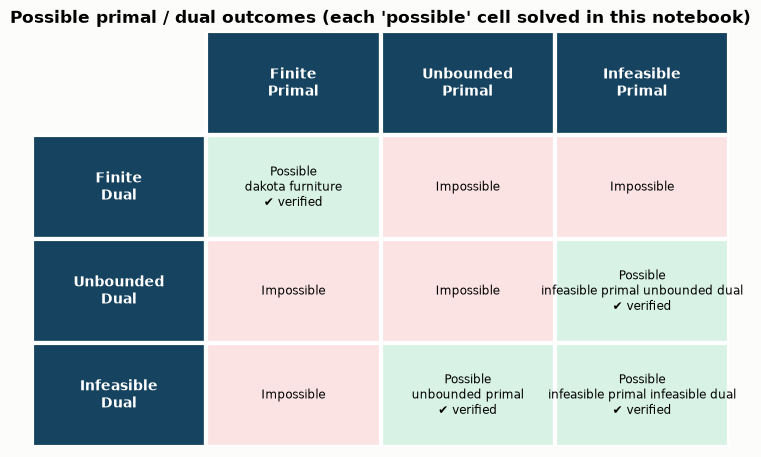

In [37]:
status_examples = {("optimal", "optimal"): "04_dakota_furniture.json", ("unbounded", "infeasible"): "08_unbounded_primal.json",
                   ("infeasible", "unbounded"): "07_infeasible_primal_unbounded_dual.json",
                   ("infeasible", "infeasible"): "06_infeasible_primal_infeasible_dual.json"}
verified = {}
for key, f in status_examples.items():
    lp = load_lp(f); verified[key] = (solve(lp)["status"], solve(dualize(lp))["status"]) == key

def plot_status_table(ax=None):
    states = ["optimal", "unbounded", "infeasible"]; nice = {"optimal": "Finite", "unbounded": "Unbounded", "infeasible": "Infeasible"}
    if ax is None: fig, ax = plt.subplots(figsize=(9, 5.4))
    ax.set_xlim(-1, 3); ax.set_ylim(3, -1); ax.axis("off")
    for k, s in enumerate(states):
        ax.add_patch(Rectangle((k, -1), 1, 1, fc="#16435f", ec="white", lw=3)); ax.text(k + .5, -.5, f"{nice[s]}\nPrimal", ha="center", va="center", color="white", fontweight="bold")
        ax.add_patch(Rectangle((-1, k), 1, 1, fc="#16435f", ec="white", lw=3)); ax.text(-.5, k + .5, f"{nice[s]}\nDual", ha="center", va="center", color="white", fontweight="bold")
    for c_, ps in enumerate(states):
        for r_, ds in enumerate(states):
            key = (ps, ds)
            if key in status_examples:
                fc, txt = "#d9f2e6", "Possible\n" + status_examples[key].split("_", 1)[1].replace(".json", "").replace("_", " ") + ("\n✔ verified" if verified[key] else "")
            else:
                fc, txt = "#fbe3e3", "Impossible"
            ax.add_patch(Rectangle((c_, r_), 1, 1, fc=fc, ec="white", lw=3)); ax.text(c_ + .5, r_ + .5, txt, ha="center", va="center", fontsize=8.5)
    ax.set_title("Possible primal / dual outcomes (each 'possible' cell solved in this notebook)")
    return ax

plot_status_table(); plt.show()

#### Pictures of the pathological cases (slides 55 – 56)
Left: the primal constraints $x_1 + x_2 \ge 1$ and $-x_1 - x_2 \ge 1$ describe two half-planes that **never overlap** → infeasible.
Right: with $x \ge 0$ the dual is $\max\, y_1 + y_2$ s.t. $y_1 - y_2 \le 1$, $y_1 - y_2 \le 0$, $y \ge 0$. Its feasible region is unbounded **in the direction that improves the objective** (along $y_1 = y_2$) → unbounded.

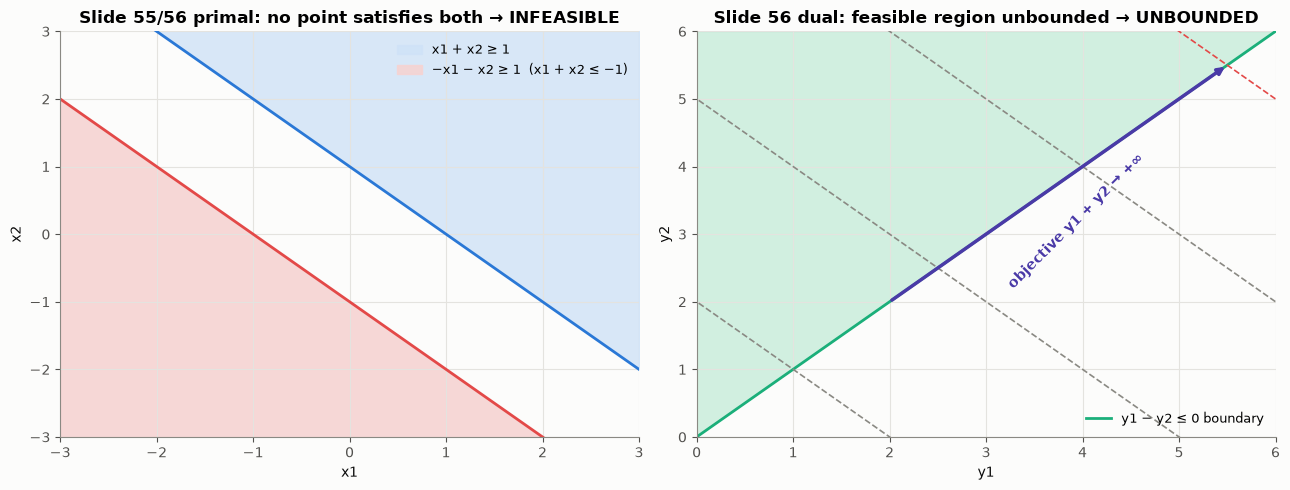

Infeasible Primal / Infeasible Dual      primal: infeasible dual: infeasible
Infeasible Primal / Unbounded Dual       primal: infeasible dual: unbounded
Unbounded Primal / Infeasible Dual       primal: unbounded  dual: infeasible


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]; xs = np.linspace(-3, 3, 200)
ax.fill_between(xs, 1 - xs, 4, color=PAL["region"], alpha=0.8, label="x1 + x2 ≥ 1")
ax.fill_between(xs, -4, -1 - xs, color=PAL["bad"], alpha=0.9, label="−x1 − x2 ≥ 1  (x1 + x2 ≤ −1)")
ax.plot(xs, 1 - xs, color=PAL["blue"]); ax.plot(xs, -1 - xs, color=PAL["red"])
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_title("Slide 55/56 primal: no point satisfies both → INFEASIBLE"); ax.legend(loc="upper right"); ax.set_xlabel("x1"); ax.set_ylabel("x2")
d7 = dualize(load_lp("07_infeasible_primal_unbounded_dual.json"))
ax = axes[1]; box = ((0, 6), (0, 6)); P = _vertices(_halfplanes(d7, box))
ax.add_patch(Polygon(P, closed=True, fc=PAL["region2"], ec=PAL["aqua"], alpha=0.9))
ax.plot([0, 6], [0, 6], color=PAL["aqua"], lw=2, label="y1 − y2 ≤ 0 boundary")
for k, zv in enumerate([2, 5, 8, 11]):
    ax.plot(xs * 3 + 3, zv - (xs * 3 + 3), ls="--", color=PAL["red"] if k == 3 else PAL["muted"], lw=1.2)
ax.annotate("", xy=(5.5, 5.5), xytext=(2, 2), arrowprops=dict(arrowstyle="-|>", color=PAL["violet"], lw=2.5))
ax.text(3.2, 2.2, "objective y1 + y2 → +∞", color=PAL["violet"], fontweight="bold", rotation=45)
ax.set_xlim(0, 6); ax.set_ylim(0, 6); ax.set_xlabel("y1"); ax.set_ylabel("y2"); ax.set_title("Slide 56 dual: feasible region unbounded → UNBOUNDED"); ax.legend(loc="lower right")
fig.tight_layout(); plt.show()
for f in ["06_infeasible_primal_infeasible_dual.json", "07_infeasible_primal_unbounded_dual.json", "08_unbounded_primal.json"]:
    lp = load_lp(f); print(f"{lp.name:40s} primal: {solve(lp)['status']:10s} dual: {solve(dualize(lp))['status']}")

### 🎛️ Interactive demo 6 — weak duality sampler
Choose a problem and the number of random feasible points. The gap between the best sampled primal and dual values shrinks as you sample more, but it never crosses the optimum.

In [39]:
if HAS_WIDGETS:
    widgets.interact(lambda problem, samples: (plot_weak_duality(load_lp(problem), samples), plt.show()),
                     problem=widgets.Dropdown(options=["04_dakota_furniture.json", "05_diet_problem.json", "01_tables_chairs.json", "09_practice_wyndor.json"]),
                     samples=widgets.IntSlider(value=1000, min=50, max=8000, step=50, continuous_update=False));

interactive(children=(Dropdown(description='problem', options=('04_dakota_furniture.json', '05_diet_problem.js…

---
## 8. Economic interpretation of the dual solution: perturbing $b$ *(slides 57 – 59)*

*Where does the dual come from, what does it mean, and what is it useful for?* Perturb the resources: $\sum_j a_{ij}x_j \le b_i + t_i$. For small $t_i$ the new LP has optimal value
$$ z^*(t) \;=\; z^* + \sum_{i=1}^m y_i^*\, t_i, $$
where $y^*$ is the **optimal dual solution**. So $y_i^*$ is exactly the **marginal value** of resource $i$, the shadow price from section 3. "Small" means: as long as the optimal basis does not change.

The figure perturbs carpentry and painting at the same time for Tables & Chairs. Left: the true $z^*(t)$ surface. Right: the error of the linear prediction. It is **exactly zero in the region where the basis stays optimal** and grows outside it.

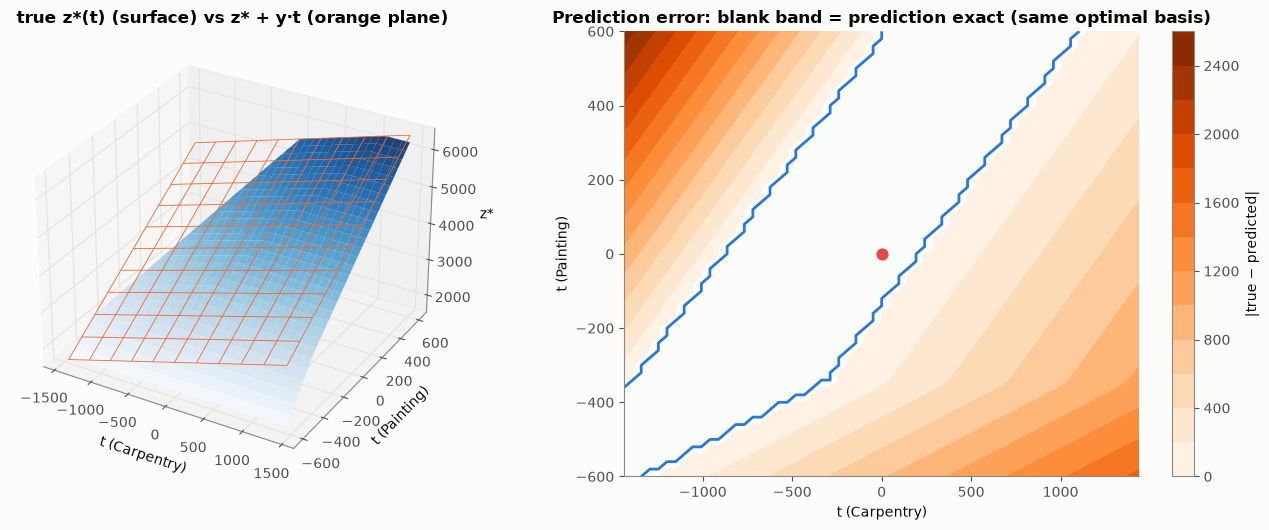

In [40]:
def perturbation_maps(lp, i1, i2, span=(0.6, 0.6), n=61):
    i1, i2 = lp.con_index(i1), lp.con_index(i2); base = solve(lp); y = base["y"]
    t1 = np.linspace(-span[0] * abs(lp.b[i1]), span[0] * abs(lp.b[i1]), n); t2 = np.linspace(-span[1] * abs(lp.b[i2]), span[1] * abs(lp.b[i2]), n)
    Z = np.full((n, n), np.nan)
    for a, u in enumerate(t1):
        for c_, v in enumerate(t2):
            b = lp.b.copy(); b[i1] += u; b[i2] += v
            Z[c_, a] = z_star(lp.copy(b=b))
    T1, T2 = np.meshgrid(t1, t2); P = base["z"] + y[i1] * T1 + y[i2] * T2
    fig = plt.figure(figsize=(14, 5.4))
    ax = fig.add_subplot(1, 2, 1, projection="3d")
    ax.plot_surface(T1, T2, Z, cmap="Blues", alpha=0.9, lw=0); ax.plot_wireframe(T1, T2, P, color=PAL["orange"], lw=0.6, rstride=6, cstride=6)
    ax.set_xlabel(f"t ({lp.con_names[i1]})"); ax.set_ylabel(f"t ({lp.con_names[i2]})"); ax.set_zlabel("z*")
    ax.set_title("true z*(t) (surface) vs z* + y·t (orange plane)")
    ax2 = fig.add_subplot(1, 2, 2)
    err = np.abs(Z - P)
    cs = ax2.contourf(T1, T2, np.where(err < 1e-6, np.nan, err), levels=12, cmap="Oranges")
    ax2.contour(T1, T2, err, levels=[1e-6], colors=[PAL["blue"]], linewidths=2)
    fig.colorbar(cs, ax=ax2, label="|true − predicted|")
    ax2.scatter([0], [0], color=PAL["red"], s=60, zorder=5); ax2.set_xlabel(f"t ({lp.con_names[i1]})"); ax2.set_ylabel(f"t ({lp.con_names[i2]})")
    ax2.set_title("Prediction error: blank band = prediction exact (same optimal basis)")
    ax2.grid(False); fig.tight_layout(); return fig

perturbation_maps(tc, "Carpentry", "Painting"); plt.show()

### 🎛️ Interactive demo 7 — perturb every resource at once
Move $t_i$ for each constraint. The bars compare the **dual-price prediction** $z^* + \sum y_i t_i$ with the **re-solved** optimum. A handy rule of thumb (the *100 % rule*): if $\sum_i |t_i| / (\text{allowed change in that direction})_i \le 1$, the prediction is guaranteed to hold.

In [41]:
def _perturb_figure(lp, t):
    t = np.asarray(t, float); sens = sensitivity(lp); base = solve(lp); y = base["y"]
    new = lp.copy(b=lp.b + t); r = solve(new)
    pred = base["z"] + y @ t
    use = sum(abs(ti) / (sens["con"].AllowIncrease[i] if ti > 0 else sens["con"].AllowDecrease[i]) for i, ti in enumerate(t) if abs(ti) > 0)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw=dict(width_ratios=[1, 1.3]))
    vals = [base["z"], pred, r["z"] if r["status"] == "optimal" else np.nan]
    ax.bar(["original z*", "prediction\nz* + Σ y·t", "true z*(b+t)"], vals, color=[PAL["muted"], PAL["orange"], PAL["blue"]], width=0.55)
    for k, v in enumerate(vals): ax.text(k, v if np.isfinite(v) else 0, f"{v:,.5g}" if np.isfinite(v) else r["status"], ha="center", va="bottom", fontweight="bold")
    ax.set_title("Prediction vs re-solve"); ax.grid(axis="x", visible=False)
    ax2.barh(lp.con_names, y * t, color=[PAL["green"] if v >= 0 else PAL["red"] for v in y * t], height=0.5)
    for k, (yi, ti) in enumerate(zip(y, t)): ax2.text(yi * ti, k, f"  y={yi:.3g} × t={ti:.3g}", va="center", fontsize=8)
    ax2.axvline(0, color=PAL["ink2"], lw=0.8); ax2.invert_yaxis(); ax2.set_title("Contribution y_i·t_i of each resource")
    fig.tight_layout(); plt.show()
    ok = r["status"] == "optimal" and abs(pred - r["z"]) < 1e-6
    display(Markdown(f"100 % rule usage: **{use*100:.0f}%** ({'≤ 100% → prediction guaranteed' if use <= 1 + 1e-9 else '> 100% → not guaranteed'}).  "
                     f"Prediction {'✔ exact' if ok else '✘ differs from the true optimum'}."))


def demo_perturbation(fname="01_tables_chairs.json", start=None):
    lp = load_lp(fname); start = np.zeros(lp.m) if start is None else np.asarray(start, float)
    if not HAS_WIDGETS: _perturb_figure(lp, start); return
    sl = [widgets.FloatSlider(value=t0, min=-0.6 * max(abs(b), 1), max=0.6 * max(abs(b), 1), step=max(abs(b), 1) / 100, description=f"t {nm}",
                              continuous_update=False, style={"description_width": "110px"}, layout=widgets.Layout(width="440px"))
          for b, nm, t0 in zip(lp.b, lp.con_names, start)]
    out = widgets.interactive_output(lambda **kw: _perturb_figure(lp, [kw[f"t{i}"] for i in range(lp.m)]), {f"t{i}": s for i, s in enumerate(sl)})
    display(widgets.VBox(sl + [out]))

demo_perturbation("01_tables_chairs.json", start=[-120, 150, 0, 0])

In [42]:
demo_perturbation("04_dakota_furniture.json", start=[0, 2, 0])   # the same demo for Dakota (3 variables)

---
## 9. Primal simplex vs. dual simplex *(slides 60 – 62)*

| | Primal simplex | Dual simplex |
|---|---|---|
| keeps | **primal feasibility** (RHS ≥ 0) | **dual feasibility** (row-0 reduced costs ≥ 0) |
| works toward | dual feasibility (optimality) | primal feasibility |
| pivot choice | entering **column** first (most negative $z_j - c_j$), then leaving row by the min-ratio test | leaving **row** first (most negative RHS), then entering column by the min-$|$ratio$|$ test on row 0 |

**Why use the dual simplex?** We have an optimal solution and **add a new constraint**. The old solution may violate it (the primal becomes infeasible), but the tableau is still **dual feasible** (for the dual, adding a constraint means adding a variable). We optimise the dual, and at optimality the primal is feasible again, *using the same tableau*.

### 9.1 Primal simplex on the cover-slide example
Path: $(0,0) \to (20,0) \to (10,20)$. Every tableau is primal feasible; only the last one is dual feasible (optimal).

Tableau,Method,Phase,Entering,Leaving,Objective,PrimalFeasible,DualFeasible,Point
0,primal,2,x1,s1,0.0000,True,False,"(0, 0)"
1,primal,2,x2,s2,100.0000,True,False,"(20, 0)"
2,primal,2,,,110.0000,True,True,"(10, 20)"


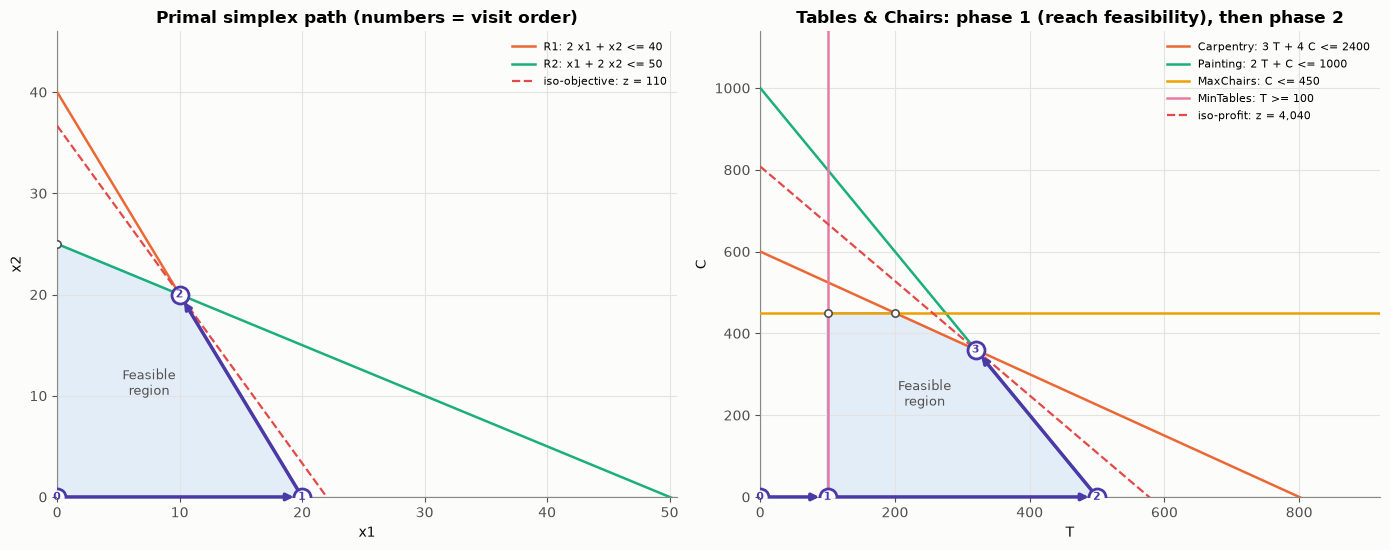

In [43]:
cv = load_lp("02_cover_example.json")
cv_s = simplex(cv)
display(iteration_table(cv_s["history"]).style.hide(axis="index").format(precision=4))

def plot_simplex_path(lp, history, ax=None, title=None, color=PAL["violet"], xlim=None, ylim=None, base_lp=None):
    if ax is None: fig, ax = plt.subplots(figsize=(7.5, 5.8))
    plot_lp_2d(lp, ax=ax, n_iso=1, xlim=xlim, ylim=ylim, opt_label=False, gradient=False, title=title)
    pts = [h["x"] for h in history]
    uniq = [pts[0]] + [p for k, p in enumerate(pts[1:], 1) if not np.allclose(p, pts[k - 1])]
    P = np.array(uniq)
    for k in range(len(P) - 1):
        ax.annotate("", xy=P[k + 1], xytext=P[k], arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5, shrinkA=6, shrinkB=6), zorder=9)
    for k, p in enumerate(P):
        ax.scatter(*p, s=150, color="white", edgecolor=color, lw=2, zorder=10)
        ax.text(*p, str(k), ha="center", va="center", fontsize=8, fontweight="bold", color=color, zorder=11)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
plot_simplex_path(cv, cv_s["history"], ax=axes[0], title="Primal simplex path (numbers = visit order)")
tc_s = simplex(tc)
plot_simplex_path(tc, tc_s["history"], ax=axes[1], title="Tables & Chairs: phase 1 (reach feasibility), then phase 2")
fig.tight_layout(); plt.show()

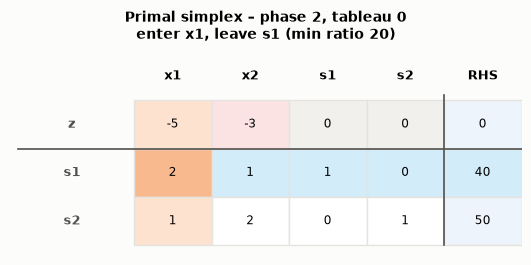

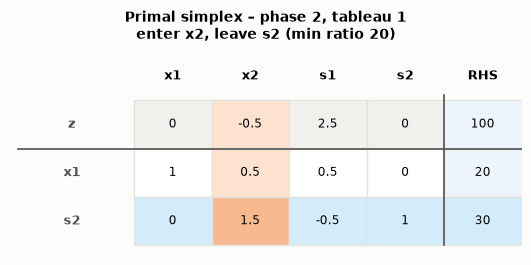

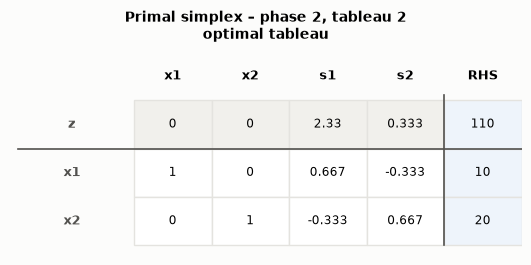

In [44]:
for snap in cv_s["history"]:
    draw_tableau(snap); plt.show()

### 9.2 Adding a new constraint and re-optimising with the dual simplex
Tables & Chairs is optimal at $(320, 360)$. Suppose a new rule limits total production: $T + C \le 600$. The old optimum ($680$ items) violates it. We append the new row to the **optimal tableau**, express it in terms of the current basis, and run the dual simplex.

Tableau,Method,Phase,Entering,Leaving,Objective,PrimalFeasible,DualFeasible,Point
0,dual,2,s1,s_Cut_TplusC,4040.0000,False,True,"(320, 360)"
1,dual,2,,,3800.0000,True,True,"(400, 200)"


Before the cut: [320. 360.], z = 4040   →   after the dual simplex: [400. 200.], z = 3800
Check with SciPy: [400. 200.] 3800.0


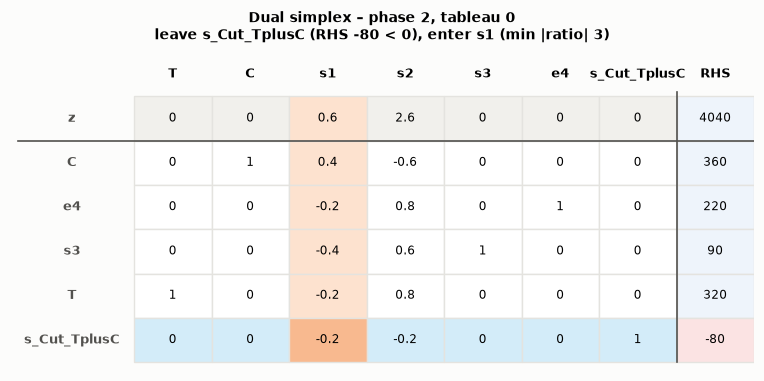

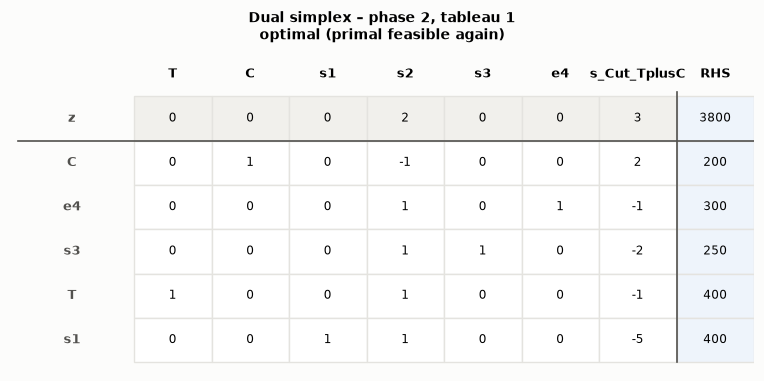

In [45]:
cut = tc.scenarios["new_constraints"][0]
ds = add_cut_and_reoptimize(tc, cut["name"], cut["coefficients"], cut["sense"], cut["rhs"])
display(iteration_table(ds["history"]).style.hide(axis="index").format(precision=4))
print(f"Before the cut: {ds['start_x']}, z = {ds['start_z']:g}   →   after the dual simplex: {ds['x']}, z = {ds['z']:g}")
print("Check with SciPy:", solve(ds["lp_new"])["x"], solve(ds["lp_new"])["z"])
for snap in ds["history"]:
    draw_tableau(snap); plt.show()

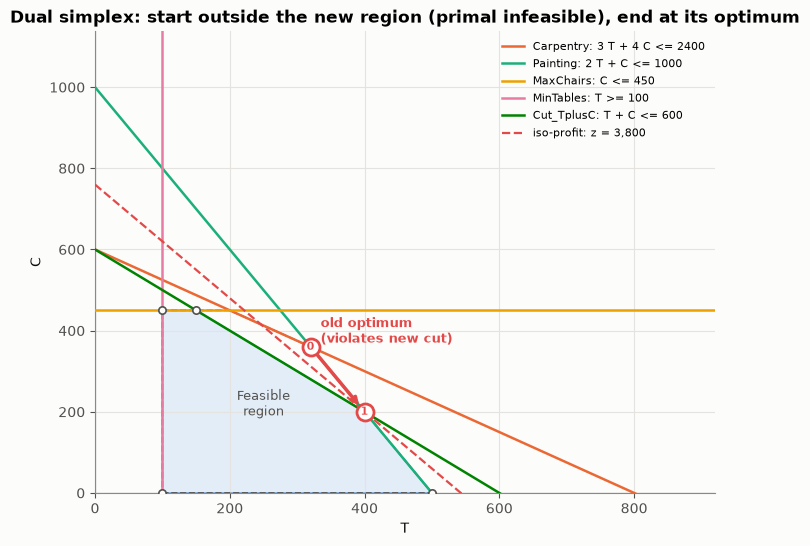

In [46]:
def plot_dual_simplex_story(lp, ds, ax=None):
    new = ds["lp_new"]
    if ax is None: fig, ax = plt.subplots(figsize=(8, 6))
    xl, yl = auto_limits(lp)
    P0 = _vertices(_halfplanes(lp, (xl, yl)))
    ax.add_patch(Polygon(P0, closed=True, fill=False, ec=PAL["ink2"], ls="--", lw=1.2, zorder=2))
    plot_simplex_path(new, ds["history"], ax=ax, xlim=xl, ylim=yl, color=PAL["red"],
                      title="Dual simplex: start outside the new region (primal infeasible), end at its optimum")
    ax.text(*ds["start_x"], "  old optimum\n  (violates new cut)", fontsize=9, va="bottom", color=PAL["red"], fontweight="bold")
    return ax

plot_dual_simplex_story(tc, ds); plt.show()

### 9.3 Watching feasibility during the iterations
Primal simplex: *primal feasible* stays ✔ throughout, *dual feasible* turns ✔ only at the end. Dual simplex: the reverse. The objective moves **up** in the primal simplex (max problem) and **down** in the dual simplex (it starts above the new optimum, because the old solution was "too good").

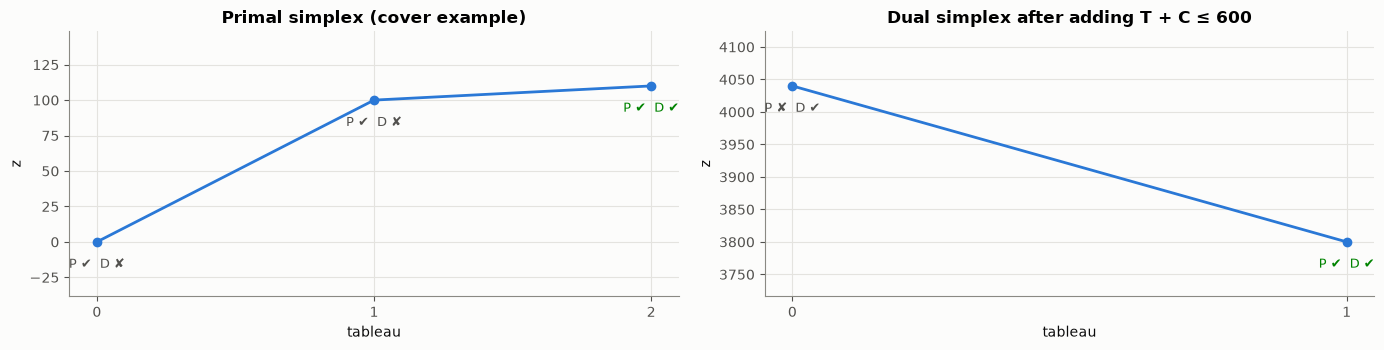

In [47]:
def plot_feasibility_timeline(histories, labels):
    fig, axes = plt.subplots(1, len(histories), figsize=(7 * len(histories), 3.6))
    for ax, h, lab in zip(np.atleast_1d(axes), histories, labels):
        h2 = [s for s in h if s["phase"] == 2]
        it = np.arange(len(h2)); z = [s["z"] for s in h2]
        ax.plot(it, z, marker="o", color=PAL["blue"], label="objective")
        for k, s in enumerate(h2):
            ax.text(k, z[k], f"\nP {'✔' if s['primal_feasible'] else '✘'}  D {'✔' if s['dual_feasible'] else '✘'}", ha="center", va="top", fontsize=9,
                    color=PAL["green"] if s["primal_feasible"] and s["dual_feasible"] else PAL["ink2"])
        ax.set_xticks(it); ax.set_xlabel("tableau"); ax.set_ylabel("z"); ax.set_title(lab)
        ax.margins(y=0.35)
    plt.tight_layout()

plot_feasibility_timeline([cv_s["history"], ds["history"]], ["Primal simplex (cover example)", "Dual simplex after adding T + C ≤ 600"]); plt.show()

### 🎛️ Interactive demo 8 — simplex stepper and "add a cut"
**Stepper:** pick a problem and step through the tableaus of the primal simplex (entering column in orange, leaving row in blue, pivot element dark orange).
**Add a cut:** choose coefficients of a new constraint $a_1 x_1 + a_2 x_2 \le r$ for a 2-variable problem and watch the dual simplex repair the solution.

In [48]:
def demo_simplex_stepper():
    if not HAS_WIDGETS: return
    dd = widgets.Dropdown(options=[f for f in list_data_files() if solve(load_lp(f))["status"] == "optimal"], value="02_cover_example.json", description="Problem",
                          layout=widgets.Layout(width="420px"))
    st = widgets.IntSlider(min=0, max=1, description="Tableau", continuous_update=False)
    out = widgets.Output(); state = {}
    def draw(*_):
        with out:
            out.clear_output(wait=True)
            h = state["s"]["history"]; lp = state["lp"]; snap = h[st.value]
            if lp.n == 2:
                fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw=dict(width_ratios=[1, 1.5]))
                plot_simplex_path(lp, h[: st.value + 1], ax=axes[0], title=f"Path so far (tableau {st.value})")
                draw_tableau(snap, ax=axes[1])
            else:
                draw_tableau(snap)
            plt.tight_layout(); plt.show()
            display(Markdown(f"Point {tuple(np.round(snap['x'], 4))}, objective {snap['z']:.4g}; primal feasible {snap['primal_feasible']}, dual feasible {snap['dual_feasible']}"))
    def load(*_):
        state["lp"] = load_lp(dd.value); state["s"] = simplex(state["lp"])
        _unobserve(st, draw); st.max = len(state["s"]["history"]) - 1; st.value = 0; st.observe(draw, "value"); draw()
    dd.observe(load, "value"); display(widgets.VBox([widgets.HBox([dd, st]), out])); load()

demo_simplex_stepper()

In [49]:
def demo_add_cut():
    if not HAS_WIDGETS: return
    dd = widgets.Dropdown(options=TWO_VAR_FILES, value="01_tables_chairs.json", description="Problem", layout=widgets.Layout(width="420px"))
    a1 = widgets.FloatText(value=1, description="a1"); a2 = widgets.FloatText(value=1, description="a2")
    sense = widgets.ToggleButtons(options=["<=", ">="], value="<="); rhs = widgets.FloatText(value=600, description="rhs")
    go = widgets.Button(description="Add cut & run dual simplex", button_style="primary", layout=widgets.Layout(width="260px"))
    out = widgets.Output()
    def run(*_):
        with out:
            out.clear_output(wait=True)
            lp = load_lp(dd.value); base = solve(lp)
            viol = (np.dot([a1.value, a2.value], base["x"]) - rhs.value) * (1 if sense.value == "<=" else -1)
            if viol <= 1e-9:
                display(Markdown(f"The current optimum {tuple(base['x'])} already satisfies the cut: nothing to do (try a tighter RHS).")); return
            res = add_cut_and_reoptimize(lp, "cut", [a1.value, a2.value], sense.value, rhs.value)
            display(iteration_table(res["history"]).style.hide(axis="index").format(precision=4))
            if res["status"] == "optimal":
                plot_dual_simplex_story(lp, res); plt.show()
            else:
                display(Markdown(f"**Dual simplex result: {res['status']}** – the new constraint makes the problem infeasible."))
            for snap in res["history"]: draw_tableau(snap); plt.show()
    go.on_click(run)
    display(widgets.VBox([dd, widgets.HBox([a1, a2, sense, rhs]), go, out])); run()

demo_add_cut()

---
## 10. Exporting PDF reports

`export_report()` writes a complete, multi-page PDF report for any problem file (or any `LP` object you built or modified in the notebook). It contains:

1. **Cover & summary** – problem description, status, optimal value, key figures
2. **Model formulation** – the LP and its data table
3. **Optimal solution** – decision values, constraint usage, graphical solution (2-variable models)
4. **Sensitivity analysis** – ranging tables (like Excel's Sensitivity Report), automatic plain-language interpretation, dashboard charts
5. **Parametric analysis** – $z^*$ and $x^*$ versus every objective coefficient and every RHS
6. **What-if scenarios** from the data file – predicted vs re-solved values
7. **Duality** – dual formulation, dual solution, strong duality and complementary slackness checks, dual-constraint chart
8. **Simplex iterations** – iteration table, algorithm path and tableaus (and the dual simplex for any `new_constraints` scenario)

Infeasible and unbounded problems get a shorter report that explains the status and the status of the dual.

In [50]:
from reportlab.lib import colors as rl_colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage,
                                PageBreak, Preformatted, KeepTogether)

_ss = getSampleStyleSheet()
RS = {
    "title": ParagraphStyle("t", parent=_ss["Title"], fontSize=24, leading=30, textColor=rl_colors.HexColor("#16435f")),
    "sub": ParagraphStyle("s", parent=_ss["Normal"], fontSize=12, leading=16, textColor=rl_colors.HexColor("#52514e")),
    "h1": ParagraphStyle("h1", parent=_ss["Heading1"], fontSize=16, textColor=rl_colors.HexColor("#16435f"), spaceBefore=6, spaceAfter=8),
    "h2": ParagraphStyle("h2", parent=_ss["Heading2"], fontSize=12, textColor=rl_colors.HexColor("#2a78d6"), spaceBefore=8, spaceAfter=4),
    "body": ParagraphStyle("b", parent=_ss["BodyText"], fontSize=9.5, leading=13),
    "small": ParagraphStyle("sm", parent=_ss["BodyText"], fontSize=8, leading=10, textColor=rl_colors.HexColor("#52514e")),
    "bullet": ParagraphStyle("bu", parent=_ss["BodyText"], fontSize=9.5, leading=13, leftIndent=12, bulletIndent=2),
    "mono": ParagraphStyle("m", parent=_ss["Code"], fontSize=8.5, leading=11, backColor=rl_colors.HexColor("#f4f3ef"),
                           borderPadding=6, leftIndent=4),
}
PAGE_W = A4[0] - 3.6 * cm


def _fig_img(fig, width=PAGE_W, dpi=170):
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", facecolor="white"); plt.close(fig)
    buf.seek(0)
    from reportlab.lib.utils import ImageReader
    iw, ih = ImageReader(buf).getSize(); buf.seek(0)
    h = width * ih / iw
    if h > 23 * cm: width, h = width * 23 * cm / h, 23 * cm
    return RLImage(buf, width=width, height=h)


def _num(v, nd=4):
    if isinstance(v, (bool, np.bool_)): return "yes" if v else "no"
    if isinstance(v, (int, float, np.floating, np.integer)):
        if np.isnan(v): return "–"
        if np.isinf(v): return "∞" if v > 0 else "-∞"
        return f"{v:,.{nd}g}"
    return str(v)


def _table(df, col_widths=None, font=8, highlight_rows=()):
    data = [list(map(str, df.columns))] + [[_num(v) for v in row] for row in df.itertuples(index=False)]
    t = Table(data, colWidths=col_widths, repeatRows=1, hAlign="LEFT")
    st = [("BACKGROUND", (0, 0), (-1, 0), rl_colors.HexColor("#16435f")), ("TEXTCOLOR", (0, 0), (-1, 0), rl_colors.white),
          ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"), ("FONTSIZE", (0, 0), (-1, -1), font),
          ("ALIGN", (1, 1), (-1, -1), "RIGHT"), ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
          ("GRID", (0, 0), (-1, -1), 0.25, rl_colors.HexColor("#d9d8d3")),
          ("ROWBACKGROUNDS", (0, 1), (-1, -1), [rl_colors.white, rl_colors.HexColor("#f6f5f1")]),
          ("TOPPADDING", (0, 0), (-1, -1), 3), ("BOTTOMPADDING", (0, 0), (-1, -1), 3)]
    for r in highlight_rows: st.append(("BACKGROUND", (0, r + 1), (-1, r + 1), rl_colors.HexColor("#fdeee0")))
    t.setStyle(TableStyle(st)); return t


def _interpretation(lp, sens):
    """Plain-language bullet points generated from the sensitivity report."""
    out = []
    unit = lp.objective_name
    for _, r in sens["var"].iterrows():
        if abs(r.Value) > 1e-9:
            out.append(f"<b>{r.Variable}</b> = {_num(r.Value)}. Its objective coefficient ({_num(r.ObjCoef)}) may vary in "
                       f"[{_num(r.RangeLow)}, {_num(r.RangeHigh)}] without changing the optimal solution (one change at a time).")
        else:
            need = "increase" if lp.sense == "max" else "decrease"
            out.append(f"<b>{r.Variable}</b> is not used (value 0). Reduced cost {_num(r.ReducedCost)}: its coefficient must {need} "
                       f"by about {_num(abs(r.ReducedCost))} before it becomes attractive.")
    for _, r in sens["con"].iterrows():
        if r.Binding and abs(r.ShadowPrice) > 1e-12:
            out.append(f"<b>{r.Constraint}</b> is binding. Shadow price {_num(r.ShadowPrice)}: each extra unit of RHS changes {unit} by "
                       f"{_num(r.ShadowPrice)}, valid while the RHS stays in [{_num(r.RangeLow)}, {_num(r.RangeHigh)}].")
        elif r.Binding:
            out.append(f"<b>{r.Constraint}</b> is binding but has a zero shadow price (degenerate or redundant at the optimum).")
        else:
            out.append(f"<b>{r.Constraint}</b> is not binding (slack {_num(r.Slack)}), so its shadow price is 0; the RHS can move within "
                       f"[{_num(r.RangeLow)}, {_num(r.RangeHigh)}] without effect on {unit}.")
    if sens["degenerate"]:
        out.append("<i>Note: the optimal solution is degenerate (a basic variable equals 0). The ranges above are valid, but other optimal bases exist and some ranges may be one-sided.</i>")
    return out


def _scenario_rows(lp, sens):
    base = solve(lp); rows = []
    for sc in lp.scenarios.get("ofc", []):
        j = lp.var_index(sc["variable"]); r = solve(lp.with_c(j, sc["value"])); row = sens["var"].iloc[j]
        inside = row.RangeLow - 1e-9 <= sc["value"] <= row.RangeHigh + 1e-9
        pred = base["z"] + (sc["value"] - lp.c[j]) * base["x"][j] if inside else np.nan
        rows.append(dict(Scenario=f"c({sc['variable']}): {lp.c[j]:g} → {sc['value']:g}", InRange="yes" if inside else "no",
                         Predicted=pred, Actual=r["z"], NewSolution=", ".join(f"{v:.4g}" for v in r["x"]) if r["x"] is not None else r["status"],
                         Note=sc.get("note", "")))
    for sc in lp.scenarios.get("rhs", []):
        i = lp.con_index(sc["constraint"]); r = solve(lp.with_b(i, sc["value"])); row = sens["con"].iloc[i]
        inside = row.RangeLow - 1e-9 <= sc["value"] <= row.RangeHigh + 1e-9
        pred = base["z"] + row.ShadowPrice * (sc["value"] - lp.b[i]) if inside else np.nan
        rows.append(dict(Scenario=f"b({sc['constraint']}): {lp.b[i]:g} → {sc['value']:g}", InRange="yes" if inside else "no",
                         Predicted=pred, Actual=r["z"] if r["status"] == "optimal" else np.nan,
                         NewSolution=", ".join(f"{v:.4g}" for v in r["x"]) if r["x"] is not None else r["status"], Note=sc.get("note", "")))
    return pd.DataFrame(rows)


def export_report(source, path=None, parametric=True, simplex_pages=True, scenarios=True, author=None):
    """Write a PDF report for an LP (file name, path or LP object). Returns the PDF path."""
    lp = source if isinstance(source, LP) else load_lp(source)
    import re
    path = Path(path) if path else REPORT_DIR / (re.sub(r"[^A-Za-z0-9]+", "_", lp.name).strip("_") + "_report.pdf")
    author = author if author is not None else (STUDENT_NAME or INSTRUCTOR)
    sol = solve(lp); d = dualize(lp); dsol = solve(d)
    S = []
    # ---------------- cover ----------------
    S += [Spacer(1, 1.0 * cm), Paragraph("Linear Programming Report", RS["title"]), Paragraph("Sensitivity Analysis &amp; Duality", RS["sub"]),
          Spacer(1, 0.8 * cm), Paragraph(f"<b>{lp.name}</b>", RS["h1"]), Paragraph(lp.description or "", RS["body"]), Spacer(1, 0.3 * cm),
          Paragraph(f"Source: {lp.source}" if lp.source else "", RS["small"]), Spacer(1, 0.6 * cm)]
    kpi = [("Problem type", f"{lp.sense.upper()}, {lp.n} variables, {lp.m} constraints"), ("Status", sol["status"].upper()),
           (f"Optimal {lp.objective_name}", _num(sol["z"], 8) if sol["status"] == "optimal" else "–"),
           ("Dual status", dsol["status"].upper()), ("Prepared by", author or "–"), ("Course", f"{COURSE_TITLE} ({INSTRUCTOR})"),
           ("Date", datetime.datetime.now().strftime("%d %B %Y, %H:%M"))]
    t = Table([[Paragraph(f"<b>{k}</b>", RS["body"]), Paragraph(str(v), RS["body"])] for k, v in kpi], colWidths=[5 * cm, PAGE_W - 5 * cm], hAlign="LEFT")
    t.setStyle(TableStyle([("LINEBELOW", (0, 0), (-1, -1), 0.3, rl_colors.HexColor("#d9d8d3")), ("TOPPADDING", (0, 0), (-1, -1), 5)]))
    S += [t]
    if sol["status"] == "optimal":
        fig, ax = plt.subplots(figsize=(8, 3.3)) if lp.n > 2 else plt.subplots(figsize=(7, 5.2))
        (plot_lp_2d(lp, ax=ax) if lp.n == 2 else plot_solution_bars(lp, sol, ax=ax))
        S += [Spacer(1, 0.4 * cm), _fig_img(fig, width=PAGE_W * (0.62 if lp.n == 2 else 0.85))]
    S.append(PageBreak())
    # ---------------- formulation ----------------
    S += [Paragraph("1. Model formulation", RS["h1"]), Preformatted(lp.text(), RS["mono"]), Spacer(1, 0.3 * cm), Paragraph("Data table", RS["h2"])]
    dtab = pd.DataFrame(lp.A, columns=lp.var_names); dtab.insert(0, "Constraint", lp.con_names); dtab["Sense"] = lp.con_sense; dtab["RHS"] = lp.b
    dtab.loc[len(dtab)] = ["Objective c"] + list(lp.c) + [lp.sense, np.nan]
    S.append(_table(dtab))
    if any(lp.var_desc) or any(lp.con_desc):
        S += [Paragraph("Definitions", RS["h2"])]
        S += [Paragraph(f"<b>{n}</b>: {dsc}", RS["bullet"], bulletText="•") for n, dsc in zip(lp.var_names + lp.con_names, lp.var_desc + lp.con_desc) if dsc]
    if sol["status"] != "optimal":
        S += [Paragraph("2. Result", RS["h1"]),
              Paragraph(f"The problem is <b>{sol['status']}</b>. Its dual is <b>{dsol['status']}</b>. "
                        + ("An infeasible primal has an infeasible or unbounded dual." if sol["status"] == "infeasible"
                           else "An unbounded primal always has an infeasible dual (weak duality)."), RS["body"]),
              Paragraph("Dual formulation", RS["h2"]), Preformatted(d.text(), RS["mono"])]
        if lp.n == 2:
            fig, ax = plt.subplots(figsize=(7, 5)); xl, yl = auto_limits(lp) if sol["status"] != "infeasible" else ((-3, 3), (-3, 3))
            plot_lp_2d(lp, ax=ax, xlim=xl, ylim=yl, iso=False, show_opt=False, title=f"{lp.name}: {sol['status']}")
            S.append(_fig_img(fig, width=PAGE_W * 0.8))
        _build_pdf(S, path, lp); return path
    # ---------------- optimal solution ----------------
    sens = sensitivity(lp)
    S += [PageBreak(), Paragraph("2. Optimal solution", RS["h1"]),
          Paragraph(f"Optimal {lp.objective_name}: <b>{_num(sol['z'], 8)}</b>", RS["body"]), Spacer(1, 0.2 * cm)]
    S.append(_table(pd.DataFrame({"Variable": lp.var_names, "Description": lp.var_desc, "Optimal value": sol["x"],
                                  "Obj. coefficient": lp.c, "Contribution": lp.c * sol["x"]})))
    S += [Spacer(1, 0.3 * cm)]
    S.append(_table(pd.DataFrame({"Constraint": lp.con_names, "LHS": sol["lhs"], "Sense": lp.con_sense, "RHS": lp.b,
                                  "Slack/Surplus": sol["slack"], "Binding": np.abs(sol["slack"]) < 1e-7}),
                    highlight_rows=[k for k in range(lp.m) if abs(sol["slack"][k]) < 1e-7]))
    fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * max(lp.m, lp.n) + 2.6))
    plot_solution_bars(lp, sol, ax=axes[0]); plot_resource_usage(lp, sol, ax=axes[1]); fig.tight_layout()
    S += [Spacer(1, 0.3 * cm), _fig_img(fig)]
    if lp.n == 2:
        S.append(Paragraph("Corner points", RS["h2"])); S.append(_table(corner_points(lp)))
    # ---------------- sensitivity ----------------
    S += [PageBreak(), Paragraph("3. Sensitivity analysis", RS["h1"]), Paragraph("Objective-coefficient ranging (variable cells)", RS["h2"])]
    v = sens["var"][["Variable", "Value", "ReducedCost", "ObjCoef", "AllowIncrease", "AllowDecrease", "RangeLow", "RangeHigh"]]
    S.append(_table(v.rename(columns={"ReducedCost": "Reduced cost", "ObjCoef": "Obj. coef", "AllowIncrease": "Allow. +", "AllowDecrease": "Allow. −",
                                      "RangeLow": "Low", "RangeHigh": "High"})))
    S.append(Paragraph("Right-hand-side ranging (constraints)", RS["h2"]))
    c = sens["con"][["Constraint", "LHS", "Sense", "RHS", "Slack", "ShadowPrice", "AllowIncrease", "AllowDecrease", "RangeLow", "RangeHigh"]]
    S.append(_table(c.rename(columns={"ShadowPrice": "Shadow price", "AllowIncrease": "Allow. +", "AllowDecrease": "Allow. −", "RangeLow": "Low", "RangeHigh": "High"}),
                    highlight_rows=[k for k, b in enumerate(sens["con"].Binding) if b]))
    S += [Paragraph("Interpretation", RS["h2"])] + [Paragraph(t_, RS["bullet"], bulletText="•") for t_ in _interpretation(lp, sens)]
    S += [PageBreak(), Paragraph("Sensitivity dashboard", RS["h2"]), _fig_img(sensitivity_dashboard(lp, sens))]
    if lp.n == 2:
        fig, ax = plt.subplots(figsize=(7.5, 5.6)); lo1, hi1 = sorted([0, 2.2 * lp.c[0]]); lo2, hi2 = sorted([0, 2.2 * lp.c[1]])
        optimal_corner_map(lp, (lo1 - 0.01, hi1 + 0.01), (lo2 - 0.01, hi2 + 0.01), ax=ax)
        S += [Paragraph("Optimal corner for every objective vector", RS["h2"]), _fig_img(fig, width=PAGE_W * 0.75)]
    # ---------------- parametric ----------------
    if parametric:
        S += [PageBreak(), Paragraph("4. Parametric analysis", RS["h1"]),
              Paragraph("Each chart re-solves the LP for a range of values of one coefficient. The shaded band is the range reported in section 3.", RS["body"])]
        for j in range(lp.n):
            axes, _ = plot_parametric_ofc(lp, j, sens=sens); fig = axes[0].figure; fig.tight_layout(); S.append(KeepTogether([_fig_img(fig)]))
        for i in range(lp.m):
            axes, _ = plot_parametric_rhs(lp, i, sens=sens); fig = axes[0].figure; fig.tight_layout(); S.append(KeepTogether([_fig_img(fig)]))
    # ---------------- scenarios ----------------
    if scenarios and (lp.scenarios.get("ofc") or lp.scenarios.get("rhs")):
        S += [PageBreak(), Paragraph("5. What-if scenarios", RS["h1"]),
              Paragraph("'Predicted' uses only the sensitivity report (shown when the change is inside its range); 'Actual' re-solves the LP.", RS["body"]),
              _table(_scenario_rows(lp, sens))]
        if lp.n == 2:
            ofc = lp.scenarios.get("ofc", [])
            for var in sorted(set(s_["variable"] for s_ in ofc)):
                fig = compare_ofc(lp, var, [s_["value"] for s_ in ofc if s_["variable"] == var], figsize=(5.2 * max(2, sum(s_["variable"] == var for s_ in ofc)), 4.6))
                S.append(_fig_img(fig))
            for s_ in lp.scenarios.get("rhs", []):
                fig, ax = plt.subplots(figsize=(8, 6)); compare_rhs(lp, s_["constraint"], s_["value"], ax=ax); S.append(_fig_img(fig, width=PAGE_W * 0.8))
    # ---------------- duality ----------------
    S += [PageBreak(), Paragraph("6. Duality", RS["h1"]), Paragraph("Dual formulation", RS["h2"]), Preformatted(d.text(), RS["mono"])]
    if dsol["status"] == "optimal":
        S += [Paragraph("Dual solution (resource / requirement prices)", RS["h2"]),
              _table(pd.DataFrame({"Dual variable": d.var_names, "Primal constraint": lp.con_names, "Value y*": dsol["x"],
                                   "Primal shadow price": sol["y"], "b_i · y_i": lp.b * dsol["x"]})),
              Spacer(1, 0.2 * cm),
              Paragraph(f"Strong duality check: primal z* = <b>{_num(sol['z'], 8)}</b>, dual w* = <b>{_num(dsol['z'], 8)}</b> "
                        f"({'equal ✔' if abs(sol['z'] - dsol['z']) < 1e-6 else 'NOT equal'}). Dual of the dual equals the primal: "
                        f"{'yes' if same_lp(dualize(d), lp) else 'no'}.", RS["body"]),
              Paragraph("Complementary slackness (all products must be 0)", RS["h2"]), _table(complementary_slackness(lp, sol, dsol))]
        fig, ax = plt.subplots(figsize=(10, 4.4)); plot_dual_constraints(lp, dsol["x"], ax=ax); S.append(_fig_img(fig))
        fig, axes = plt.subplots(1, 2, figsize=(13, 3.2 + 0.35 * max(lp.m, lp.n))); plot_transpose(lp, d, axes=axes); S.append(_fig_img(fig))
        if lp.n == 2 or lp.m == 2:
            L2 = lp if lp.n == 2 else d
            fig, ax = plt.subplots(figsize=(7, 5)); plot_lp_2d(L2, ax=ax, title=f"Graphical view of the {'primal' if L2 is lp else 'dual'}")
            S.append(_fig_img(fig, width=PAGE_W * 0.7))
    # ---------------- simplex ----------------
    if simplex_pages:
        sx = sens["simplex"]
        S += [PageBreak(), Paragraph("7. Simplex iterations", RS["h1"]),
              Paragraph("Two-phase tableau simplex (entering column = most negative z<sub>j</sub> − c<sub>j</sub>; leaving row = minimum ratio).", RS["body"]),
              _table(iteration_table(sx["history"]))]
        if lp.n == 2:
            fig, ax = plt.subplots(figsize=(7, 5.3)); plot_simplex_path(lp, sx["history"], ax=ax, title="Path of the primal simplex"); S.append(_fig_img(fig, width=PAGE_W * 0.7))
        snaps = sx["history"] if len(sx["history"]) <= 8 else [sx["history"][0], sx["history"][-1]]
        for snap in snaps:
            ax = draw_tableau(snap); S.append(KeepTogether([_fig_img(ax.figure, width=min(PAGE_W, (snap["T"].shape[1] + 2) * 1.15 * cm))]))
        for cut_ in lp.scenarios.get("new_constraints", []):
            res = add_cut_and_reoptimize(lp, cut_["name"], cut_["coefficients"], cut_["sense"], cut_["rhs"])
            S += [PageBreak(), Paragraph(f"Dual simplex after adding '{cut_['name']}'", RS["h2"]),
                  Paragraph(f"New constraint: {' + '.join(f'{a:g} {n}' for a, n in zip(cut_['coefficients'], lp.var_names))} {cut_['sense']} {cut_['rhs']:g}. "
                            f"{cut_.get('note', '')} Result: <b>{res['status']}</b>" + (f", new optimum ({', '.join(f'{v:.4g}' for v in res['x'])}), "
                            f"{lp.objective_name} = {_num(res['z'])}." if res["status"] == "optimal" else "."), RS["body"]),
                  _table(iteration_table(res["history"]))]
            if lp.n == 2 and res["status"] == "optimal":
                fig, ax = plt.subplots(figsize=(7.5, 5.6)); plot_dual_simplex_story(lp, res, ax=ax); S.append(_fig_img(fig, width=PAGE_W * 0.75))
            for snap in res["history"]:
                ax = draw_tableau(snap); S.append(KeepTogether([_fig_img(ax.figure, width=min(PAGE_W, (snap["T"].shape[1] + 2) * 1.15 * cm))]))
    _build_pdf(S, path, lp)
    return path


def _build_pdf(story, path, lp):
    def deco(canvas, doc):
        canvas.saveState()
        canvas.setStrokeColor(rl_colors.HexColor("#2a78d6")); canvas.setLineWidth(2)
        canvas.line(1.8 * cm, A4[1] - 1.3 * cm, A4[0] - 1.8 * cm, A4[1] - 1.3 * cm)
        canvas.setFont("Helvetica", 8); canvas.setFillColor(rl_colors.HexColor("#52514e"))
        canvas.drawString(1.8 * cm, A4[1] - 1.15 * cm, f"{COURSE_TITLE} — {lp.name}")
        canvas.drawRightString(A4[0] - 1.8 * cm, 1.2 * cm, f"Page {doc.page}")
        canvas.drawString(1.8 * cm, 1.2 * cm, "Generated with the Sensitivity Analysis & Duality notebook")
        canvas.restoreState()
    doc = SimpleDocTemplate(str(path), pagesize=A4, leftMargin=1.8 * cm, rightMargin=1.8 * cm, topMargin=1.8 * cm, bottomMargin=1.8 * cm,
                            title=f"{lp.name} – LP report", author=STUDENT_NAME or INSTRUCTOR)
    doc.build(story, onFirstPage=deco, onLaterPages=deco)
    plt.close("all")

### Export one report
The report for the lecture's main example is written to `reports/`. Change the file name to export any other problem.

In [51]:
pdf = export_report("01_tables_chairs.json")
print("Report written to:", pdf)
display(HTML(f'<a href="{os.path.relpath(pdf)}" target="_blank">📄 Open {pdf.name}</a>'))

Report written to: c:\Users\islam\Documents\GitHub\IME312_OR1_FALL2026\Lecture04\reports\Tables_and_Chairs_report.pdf


### Export reports for a modified model
Any `LP` object works, for example the Tables & Chairs model with 1300 painting hours, or with the extra constraint from section 9:

In [52]:
tc_1300 = tc.with_b("Painting", 1300).copy(name="Tables and Chairs (painting = 1300)")
print(export_report(tc_1300, simplex_pages=False))

c:\Users\islam\Documents\GitHub\IME312_OR1_FALL2026\Lecture04\reports\Tables_and_Chairs_painting_1300_report.pdf


### Export all problem files at once

In [53]:
for f in list_data_files():
    p_ = export_report(f)
    print(f"{f:45s} → {p_.name}")

01_tables_chairs.json                         → Tables_and_Chairs_report.pdf
02_cover_example.json                         → Cover_Slide_Example_report.pdf
03_duality_example.json                       → Duality_Example_min_form_report.pdf
04_dakota_furniture.json                      → Dakota_Furniture_report.pdf
05_diet_problem.json                          → Diet_Problem_report.pdf
06_infeasible_primal_infeasible_dual.json     → Infeasible_Primal_Infeasible_Dual_report.pdf
07_infeasible_primal_unbounded_dual.json      → Infeasible_Primal_Unbounded_Dual_report.pdf
08_unbounded_primal.json                      → Unbounded_Primal_Infeasible_Dual_report.pdf
09_practice_wyndor.json                       → Practice_Wyndor_Glass_report.pdf
10_practice_feed_mix.json                     → Practice_Feed_Mix_min_report.pdf
99_template.json                              → My_LP_template_report.pdf


### 🎛️ Interactive demo 9 — report builder
Choose a problem, tick the sections you want, and press **Export PDF**.

In [54]:
def demo_report_builder():
    if not HAS_WIDGETS: return
    dd = widgets.Dropdown(options=list_data_files(), description="Problem", layout=widgets.Layout(width="420px"))
    name = widgets.Text(value=STUDENT_NAME, description="Prepared by", placeholder="your name")
    par = widgets.Checkbox(value=True, description="Parametric charts"); sim = widgets.Checkbox(value=True, description="Simplex tableaus")
    scn = widgets.Checkbox(value=True, description="What-if scenarios")
    btn = widgets.Button(description="Export PDF", icon="file-pdf-o", button_style="success"); out = widgets.Output()
    def go(*_):
        with out:
            out.clear_output(); print("Building report ...")
            p_ = export_report(dd.value, parametric=par.value, simplex_pages=sim.value, scenarios=scn.value, author=name.value or None)
            out.clear_output(); display(HTML(f'✅ <a href="{os.path.relpath(p_)}" target="_blank">{p_.name}</a> ({p_.stat().st_size/1024:.0f} KB)'))
    btn.on_click(go)
    display(widgets.VBox([widgets.HBox([dd, name]), widgets.HBox([par, sim, scn]), btn, out]))

demo_report_builder()

---
## 11. Practice problems

`analyze()` runs the whole lecture on one model: formulation, solution, sensitivity report, dashboard, dual and complementary slackness. Use it on the practice files or on your own model.

In [55]:
def analyze(source, parametric=False):
    lp = source if isinstance(source, LP) else load_lp(source)
    lp.show(); sol = solve(lp)
    if sol["status"] != "optimal":
        display(Markdown(f"**Status: {sol['status']}**; dual status: {solve(dualize(lp))['status']}")); return
    if lp.n == 2:
        plot_lp_2d(lp); plt.show()
    sens = show_sensitivity(lp)
    sensitivity_dashboard(lp, sens); plt.show()
    if parametric:
        for j in range(lp.n): plot_parametric_ofc(lp, j, sens=sens); plt.tight_layout(); plt.show()
        for i in range(lp.m): plot_parametric_rhs(lp, i, sens=sens); plt.tight_layout(); plt.show()
    d = dualize(lp); d.show("Dual"); ds_ = solve(d)
    display(Markdown(f"Dual optimum w\\* = **{ds_['z']:,.6g}** (primal z\\* = {sol['z']:,.6g}); dual solution = shadow prices: {np.round(ds_['x'], 6)}"))
    display(complementary_slackness(lp, sol, ds_).style.hide(axis="index").format(precision=4))
    return sens

### Practice 1 — Wyndor Glass (`09_practice_wyndor.json`)
1. Solve graphically and list the corner points.
2. Find the range of optimality of the door profit. Is the solution still optimal if door profit becomes 8?
3. What is plant 2 capacity worth per hour? Over what range is this valid?
4. Write the dual and interpret each dual variable.

**Practice: Wyndor Glass**

<IPython.core.display.Math object>

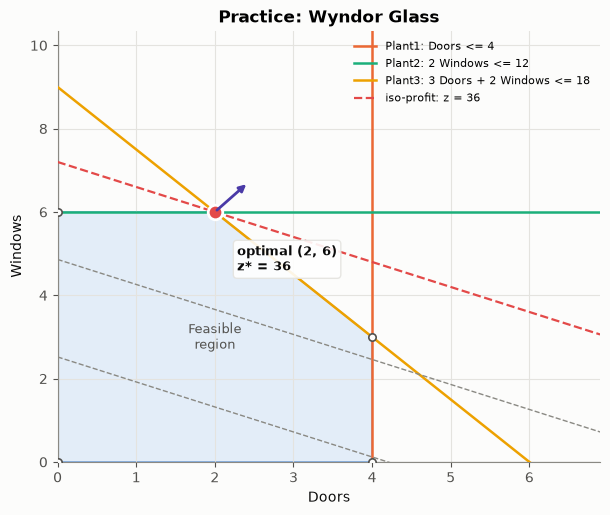

**Practice: Wyndor Glass** — optimal Profit ($1000): **36**

*Variable cells (objective-coefficient ranging)*

,Variable,Value,ReducedCost,ObjCoef,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,Doors,2.0000,0.0000,3.0000,4.5,3,0,7.5
1,Windows,6.0000,0.0000,5.0000,∞,3,2,∞


*Constraints (right-hand-side ranging)*

,Constraint,LHS,Sense,RHS,Slack,ShadowPrice,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,Plant1,2.0000,<=,4.0000,2.0000,0.0000,∞,2,2,∞
1,Plant2,12.0000,<=,12.0000,0.0000,1.5000,6,6,6,18
2,Plant3,18.0000,<=,18.0000,0.0000,1.0000,6,6,12,24


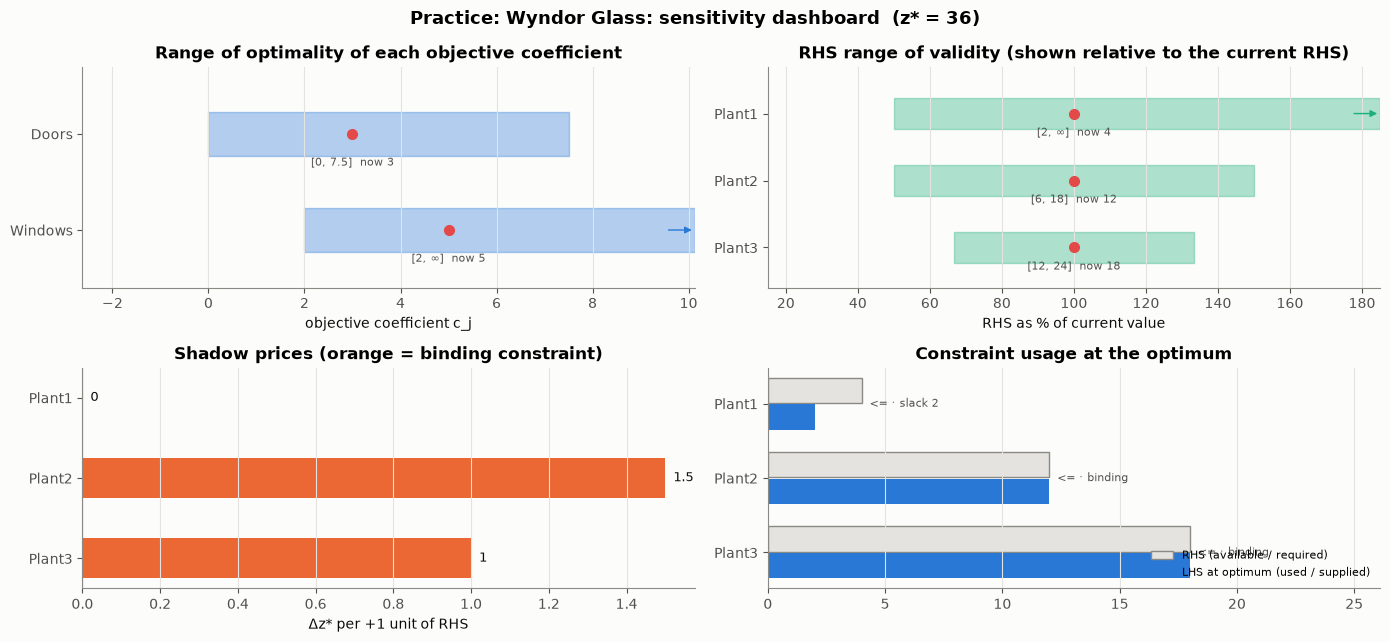

**Dual**

<IPython.core.display.Math object>

Dual optimum w\* = **36** (primal z\* = 36); dual solution = shadow prices: [0.  1.5 1. ]

Pair,Slack,DualValue,Product
Plant1 slack × y_Plant1,2.0000,0.0000,0.0000
Plant2 slack × y_Plant2,0.0000,1.5000,0.0000
Plant3 slack × y_Plant3,0.0000,1.0000,0.0000
Doors × surplus of dual constraint Doors,0.0000,2.0000,0.0000
Windows × surplus of dual constraint Windows,0.0000,6.0000,0.0000


In [56]:
wy_sens = analyze("09_practice_wyndor.json")

### Practice 2 — Feed mix (`10_practice_feed_mix.json`, a min problem)
1. Which constraints are binding? Interpret their shadow prices (careful with signs in a min problem).
2. What happens to the cost if the total feed requirement rises to 1000 kg? Use the shadow price, then verify.
3. Interpret the dual problem as a "nutrient pricing" problem, as in the diet example.

**Practice: Feed Mix (min)**

<IPython.core.display.Math object>

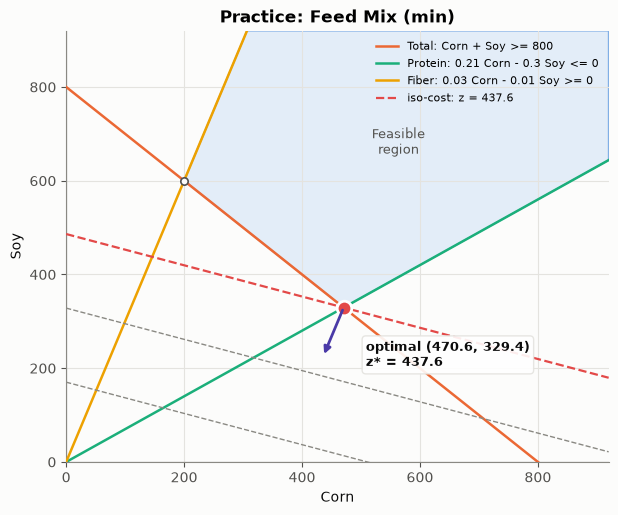

**Practice: Feed Mix (min)** — optimal Cost ($): **437.6**

*Variable cells (objective-coefficient ranging)*

,Variable,Value,ReducedCost,ObjCoef,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,Corn,470.5882,0.0000,0.3000,0.6,0.93,-0.63,0.9
1,Soy,329.4118,0.0000,0.9000,∞,0.6,0.3,∞


*Constraints (right-hand-side ranging)*

,Constraint,LHS,Sense,RHS,Slack,ShadowPrice,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,Total,800.0000,>=,800.0000,0.0000,0.5471,∞,800,0,∞
1,Protein,0.0000,<=,0.0000,0.0000,-1.1765,168,138,-138,168
2,Fiber,10.8235,>=,0.0000,10.8235,0.0000,10.82,∞,-∞,10.82


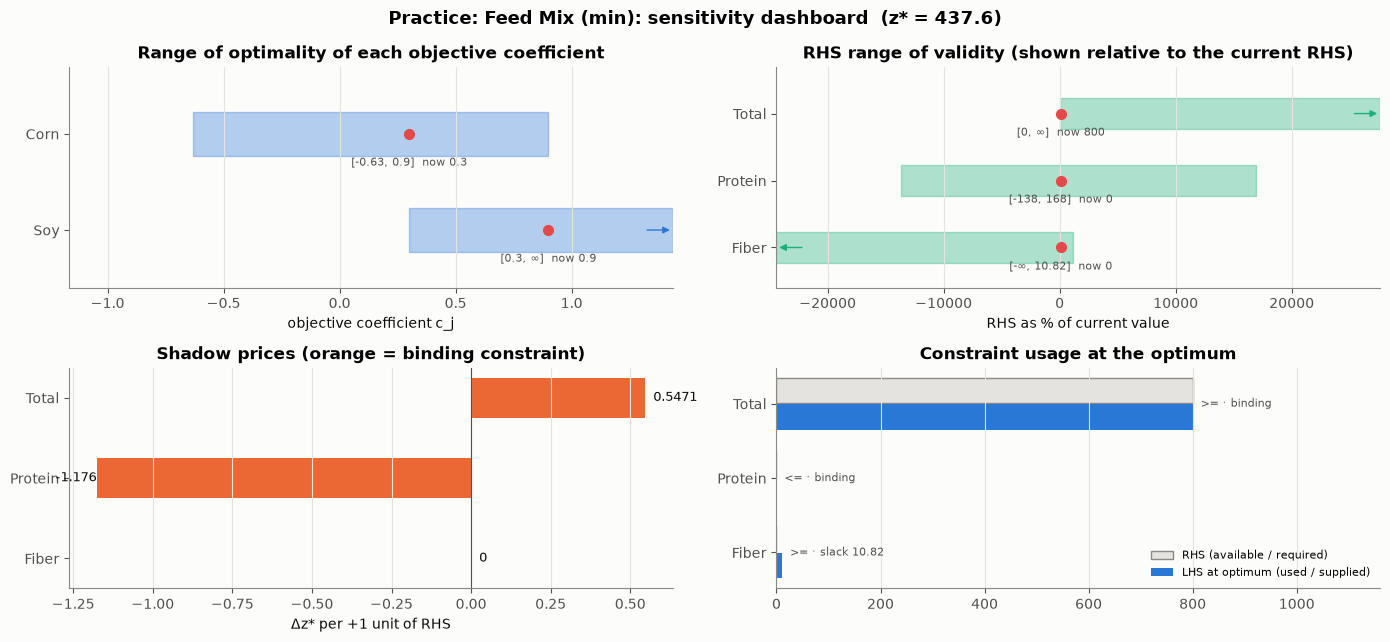

**Dual**

<IPython.core.display.Math object>

Dual optimum w\* = **437.647** (primal z\* = 437.647); dual solution = shadow prices: [ 0.5471 -1.1765  0.    ]

Pair,Slack,DualValue,Product
Total slack × y_Total,0.0000,0.5471,0.0000
Protein slack × y_Protein,-0.0000,-1.1765,0.0000
Fiber slack × y_Fiber,10.8235,0.0000,0.0000
Corn × surplus of dual constraint Corn,-0.0000,470.5882,0.0000
Soy × surplus of dual constraint Soy,-0.0000,329.4118,0.0000


In [57]:
fm_sens = analyze("10_practice_feed_mix.json")

### Practice 3 — build your own model
Either copy `data/99_template.json`, or create an `LP` directly in code:

**My model**

<IPython.core.display.Math object>

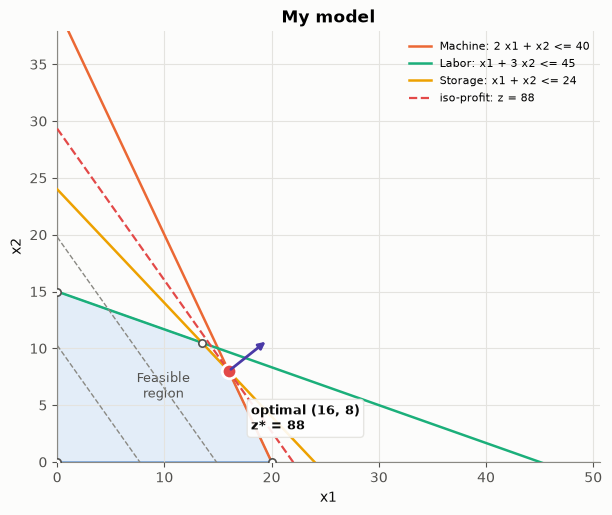

**My model** — optimal Profit: **88**

*Variable cells (objective-coefficient ranging)*

,Variable,Value,ReducedCost,ObjCoef,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,x1,16.0000,0.0000,4.0000,2,1,3,6
1,x2,8.0000,0.0000,3.0000,1,1,2,4


*Constraints (right-hand-side ranging)*

,Constraint,LHS,Sense,RHS,Slack,ShadowPrice,AllowIncrease,AllowDecrease,RangeLow,RangeHigh
0,Machine,40.0000,<=,40.0000,0.0000,1.0000,8,2.5,37.5,48
1,Labor,40.0000,<=,45.0000,5.0000,0.0000,∞,5,40,∞
2,Storage,24.0000,<=,24.0000,0.0000,2.0000,1,4,20,25


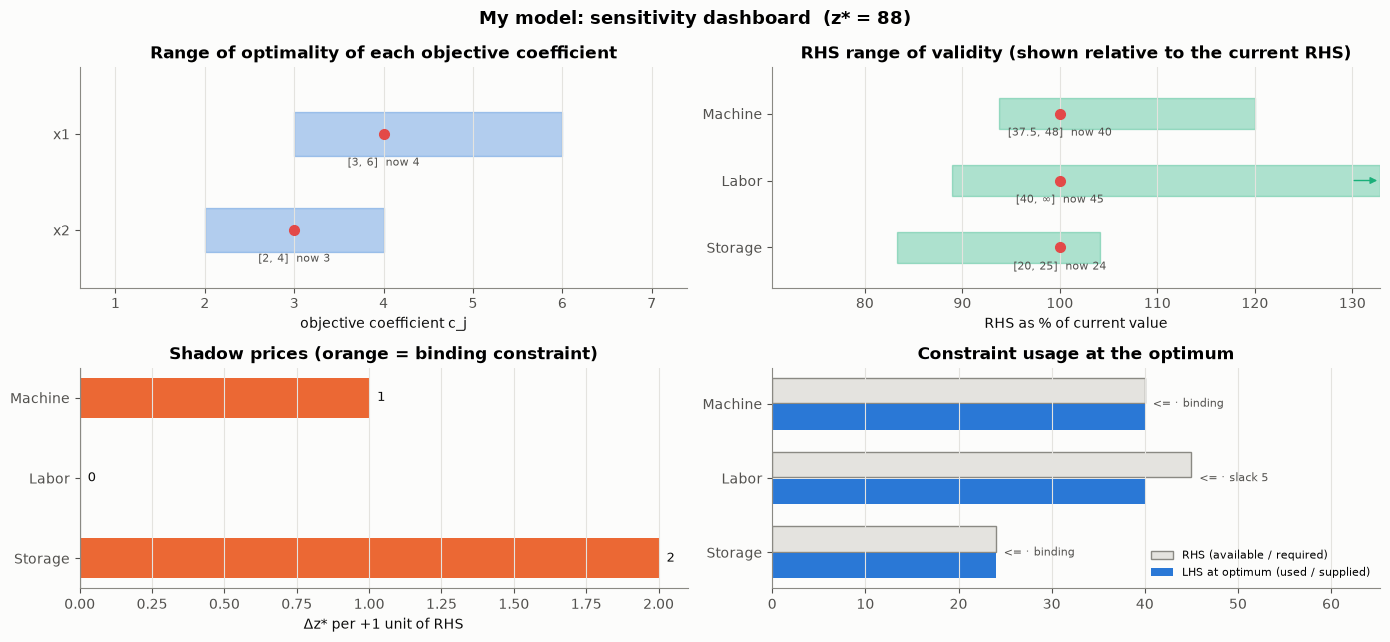

**Dual**

<IPython.core.display.Math object>

Dual optimum w\* = **88** (primal z\* = 88); dual solution = shadow prices: [1. 0. 2.]

Pair,Slack,DualValue,Product
Machine slack × y_Machine,0.0000,1.0000,0.0000
Labor slack × y_Labor,5.0000,0.0000,0.0000
Storage slack × y_Storage,-0.0000,2.0000,0.0000
x1 × surplus of dual constraint x1,0.0000,16.0000,0.0000
x2 × surplus of dual constraint x2,0.0000,8.0000,0.0000


In [58]:
my_lp = LP(name="My model", sense="max", c=[4, 3], A=[[2, 1], [1, 3], [1, 1]], b=[40, 45, 24],
           con_sense=["<=", "<=", "<="], var_names=["x1", "x2"], con_names=["Machine", "Labor", "Storage"],
           objective_name="Profit")
analyze(my_lp);

✏️ **Your turn**
* Change a coefficient in `my_lp` so that a *different* corner becomes optimal. Which range did you leave?
* Add a constraint with `my_lp.add_constraint(...)` and re-optimise with `add_cut_and_reoptimize(...)`.
* Export your analysis: `export_report(my_lp)` and hand in the PDF.

In [59]:
# export_report(my_lp)

---
### Summary of the lecture
| Concept | Key idea | Where in this notebook |
|---|---|---|
| OFC change | rotates the iso-objective line; same corner while $c_j$ stays in its range of optimality | §2, demo 1 |
| RHS change | shifts a constraint line; $\Delta z^* = y_i\,\Delta b_i$ while $b_i$ stays in its validity range | §3, demo 2 |
| Shadow price | $\partial z^*/\partial b_i$; zero for non-binding constraints | §3 |
| Dual problem | transpose the data; one dual variable per constraint | §4, demo 3 |
| Economic meaning | dual variables = prices of resources (max) or requirements (min) | §5 – 6, demos 4 – 5 |
| Weak / strong duality | primal bounds dual; equal at optimum | §7, demo 6 |
| Status table | unbounded ⇒ dual infeasible; infeasible ⇒ dual infeasible or unbounded | §7.4 |
| Perturbation | $z^*(b+t) = z^* + y^{*}\cdot t$ for small $t$ | §8, demo 7 |
| Dual simplex | keeps dual feasibility; ideal after adding a constraint | §9, demo 8 |